# 1) IMPORTACIÓN DE  LIBRERIAS

In [1]:
#Importando librerias para la limpieza y análisis de datos

import pandas as pd
import numpy as np
import datetime

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure
plt.rc("font", size=14)

import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

pd.options.mode.chained_assignment = None

# 2) EXPLORACIÓN DE DATOS

In [2]:
#ingesta de datos
df = pd.read_csv('application_data.csv', sep=",")
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
#visualización de datos originales --> analítica descriptiva de la data
df.describe().round(2)

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.00,307511.00,307511.00,3.075110e+05,307511.00,307499.00,307233.00,307511.00,307511.00,307511.00,...,307511.00,307511.00,307511.00,307511.00,265992.00,265992.00,265992.00,265992.00,265992.00,265992.00
mean,278180.52,0.08,0.42,1.687979e+05,599026.00,27108.57,538396.21,0.02,-16037.00,63815.05,...,0.01,0.00,0.00,0.00,0.01,0.01,0.03,0.27,0.27,1.90
std,102790.18,0.27,0.72,2.371231e+05,402490.78,14493.74,369446.46,0.01,4363.99,141275.77,...,0.09,0.02,0.02,0.02,0.08,0.11,0.20,0.92,0.79,1.87
min,100002.00,0.00,0.00,2.565000e+04,45000.00,1615.50,40500.00,0.00,-25229.00,-17912.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,189145.50,0.00,0.00,1.125000e+05,270000.00,16524.00,238500.00,0.01,-19682.00,-2760.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,278202.00,0.00,0.00,1.471500e+05,513531.00,24903.00,450000.00,0.02,-15750.00,-1213.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
75%,367142.50,0.00,1.00,2.025000e+05,808650.00,34596.00,679500.00,0.03,-12413.00,-289.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00
max,456255.00,1.00,19.00,1.170000e+08,4050000.00,258025.50,4050000.00,0.07,-7489.00,365243.00,...,1.00,1.00,1.00,1.00,4.00,9.00,8.00,27.00,261.00,25.00


In [4]:
print('Numero de filas   : ', df.shape[0])  #NUMERO DE FILAS
print('Numero de columnas: ', df.shape[1])  #NUMERO DE COLUMNAS
print('\n','Nombre:', '\n', list(df.columns)) #NOMBRE DE LAS COLUMNAS

Numero de filas   :  307511
Numero de columnas:  122

 Nombre: 
 ['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_

# 3) RELLENO DE LOS DATOS NULOS Y LIMPIEZA

In [5]:
#calculamos el porcentaje de valores nulos por columna
missing_porcentajes=[]
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

SK_ID_CURR - 0%
TARGET - 0%
NAME_CONTRACT_TYPE - 0%
CODE_GENDER - 0%
FLAG_OWN_CAR - 0%
FLAG_OWN_REALTY - 0%
CNT_CHILDREN - 0%
AMT_INCOME_TOTAL - 0%
AMT_CREDIT - 0%
AMT_ANNUITY - 0%
AMT_GOODS_PRICE - 0%
NAME_TYPE_SUITE - 0%
NAME_INCOME_TYPE - 0%
NAME_EDUCATION_TYPE - 0%
NAME_FAMILY_STATUS - 0%
NAME_HOUSING_TYPE - 0%
REGION_POPULATION_RELATIVE - 0%
DAYS_BIRTH - 0%
DAYS_EMPLOYED - 0%
DAYS_REGISTRATION - 0%
DAYS_ID_PUBLISH - 0%
OWN_CAR_AGE - 66%
FLAG_MOBIL - 0%
FLAG_EMP_PHONE - 0%
FLAG_WORK_PHONE - 0%
FLAG_CONT_MOBILE - 0%
FLAG_PHONE - 0%
FLAG_EMAIL - 0%
OCCUPATION_TYPE - 31%
CNT_FAM_MEMBERS - 0%
REGION_RATING_CLIENT - 0%
REGION_RATING_CLIENT_W_CITY - 0%
WEEKDAY_APPR_PROCESS_START - 0%
HOUR_APPR_PROCESS_START - 0%
REG_REGION_NOT_LIVE_REGION - 0%
REG_REGION_NOT_WORK_REGION - 0%
LIVE_REGION_NOT_WORK_REGION - 0%
REG_CITY_NOT_LIVE_CITY - 0%
REG_CITY_NOT_WORK_CITY - 0%
LIVE_CITY_NOT_WORK_CITY - 0%
ORGANIZATION_TYPE - 0%
EXT_SOURCE_1 - 56%
EXT_SOURCE_2 - 0%
EXT_SOURCE_3 - 20%
APARTMENTS_AVG - 51

In [6]:
numerics_columns =  df.select_dtypes(include=['int64', 'float64']).columns
string_columns  = df.select_dtypes(include=['string', 'object']).columns

In [7]:
numerics_columns = df.select_dtypes(include=['int64', 'float64']).columns
filtered_columns = [col for col in numerics_columns if 'flag' in col.lower()]
filtered_columns

['FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_3',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_5',
 'FLAG_DOCUMENT_6',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_8',
 'FLAG_DOCUMENT_9',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_11',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_13',
 'FLAG_DOCUMENT_14',
 'FLAG_DOCUMENT_15',
 'FLAG_DOCUMENT_16',
 'FLAG_DOCUMENT_17',
 'FLAG_DOCUMENT_18',
 'FLAG_DOCUMENT_19',
 'FLAG_DOCUMENT_20',
 'FLAG_DOCUMENT_21']

In [8]:
df[filtered_columns] = df[filtered_columns].astype(str)

In [10]:
numerics_columns = df.select_dtypes(include=['int64', 'float64']).columns
filtered_columns = [col for col in numerics_columns if 'flag' in col.lower()]
filtered_columns

[]

In [11]:
numerics_columns =  df.select_dtypes(include=['int64', 'float64']).columns

### Imputamos las variables cuantitativas con la mediana
### Imputamos las variables cualitativas con la moda

In [13]:
for var in numerics_columns:
        df[var] = df[var].fillna(df[var].median()) # La mediana es un valor mas robusto como valor de imputacion
        print(f"Valores perdidos en {var}: {df[var].isnull().sum()}")
        
# Imputamos las variables cualitativas con la moda
for var in string_columns:
        mode_value = df[var].mode().iloc[0]
        df[var] = df[var].fillna(mode_value)
        print(f"Valores perdidos en {var}: {df[var].isnull().sum()}")

Valores perdidos en SK_ID_CURR: 0
Valores perdidos en TARGET: 0
Valores perdidos en CNT_CHILDREN: 0
Valores perdidos en AMT_INCOME_TOTAL: 0
Valores perdidos en AMT_CREDIT: 0
Valores perdidos en AMT_ANNUITY: 0
Valores perdidos en AMT_GOODS_PRICE: 0
Valores perdidos en REGION_POPULATION_RELATIVE: 0
Valores perdidos en DAYS_BIRTH: 0
Valores perdidos en DAYS_EMPLOYED: 0
Valores perdidos en DAYS_REGISTRATION: 0
Valores perdidos en DAYS_ID_PUBLISH: 0
Valores perdidos en OWN_CAR_AGE: 0
Valores perdidos en CNT_FAM_MEMBERS: 0
Valores perdidos en REGION_RATING_CLIENT: 0
Valores perdidos en REGION_RATING_CLIENT_W_CITY: 0
Valores perdidos en HOUR_APPR_PROCESS_START: 0
Valores perdidos en REG_REGION_NOT_LIVE_REGION: 0
Valores perdidos en REG_REGION_NOT_WORK_REGION: 0
Valores perdidos en LIVE_REGION_NOT_WORK_REGION: 0
Valores perdidos en REG_CITY_NOT_LIVE_CITY: 0
Valores perdidos en REG_CITY_NOT_WORK_CITY: 0
Valores perdidos en LIVE_CITY_NOT_WORK_CITY: 0
Valores perdidos en EXT_SOURCE_1: 0
Valores p

In [14]:
##vamos a unificar los formatos para la variable code_gender
df['CODE_GENDER'].value_counts()

F      202448
M      105059
XNA         4
Name: CODE_GENDER, dtype: int64

<!-- df = df.loc[df['CODE_GENDER']!='XNA']  --> porque no hay apenas registros con ese código

In [15]:
df = df.loc[df['CODE_GENDER']!='XNA']

In [16]:
numerics_columns =  df.select_dtypes(include=['int64', 'float64']).columns

In [17]:
df['TARGET'].astype('int')
##vamos a unificar los formatos para la variable flag_own_car
df['FLAG_OWN_CAR'].value_counts()
#Unificamos formatos
df['FLAG_OWN_CAR'] = df['FLAG_OWN_CAR'].replace({'N':0, 'Y':1}).astype('int')
display(df.head())

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,0,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,0,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,1,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,0,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,100007,0,Cash loans,M,0,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Vemos que tenemos dos categorías, por lo cual estamos ante una variable dicotomica, volvemos a hacer lo mismo.
0:'Cash loans'
1:'Revolving loans'

In [18]:
#Analizamos el formato de los datos --> para ver todos y que no se trunque al salida usamos esto:
print(df.dtypes.to_string())

SK_ID_CURR                        int64
TARGET                            int64
NAME_CONTRACT_TYPE               object
CODE_GENDER                      object
FLAG_OWN_CAR                      int64
FLAG_OWN_REALTY                  object
CNT_CHILDREN                      int64
AMT_INCOME_TOTAL                float64
AMT_CREDIT                      float64
AMT_ANNUITY                     float64
AMT_GOODS_PRICE                 float64
NAME_TYPE_SUITE                  object
NAME_INCOME_TYPE                 object
NAME_EDUCATION_TYPE              object
NAME_FAMILY_STATUS               object
NAME_HOUSING_TYPE                object
REGION_POPULATION_RELATIVE      float64
DAYS_BIRTH                        int64
DAYS_EMPLOYED                     int64
DAYS_REGISTRATION               float64
DAYS_ID_PUBLISH                   int64
OWN_CAR_AGE                     float64
FLAG_MOBIL                       object
FLAG_EMP_PHONE                   object
FLAG_WORK_PHONE                  object


para poder solo sacar correlacion de valores que no son flag, solamente numericos transformamos las columnas a string

In [19]:
numerics_columns = df.select_dtypes(include=['int64', 'float64']).columns
filtered_columns = [col for col in numerics_columns if 'flag' in col.lower()]
filtered_columns

['FLAG_OWN_CAR']

In [20]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,0,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,0,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,1,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,0,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,100007,0,Cash loans,M,0,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,0,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,0,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,1,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,0,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,100007,0,Cash loans,M,0,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 4 )  ESTUDIO DE CORRELACION

Pruebas de normalidad; en principio el test de Shapiro no valdría debido al tamaño de nuestro dataset por ello se realizará tambien el test de kolmogorov

/Users/juanmartin/anaconda3/lib/python3.10/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Se usará la correlación de spearman porque:
 - SK_ID_CURR: No normal
 - TARGET: No normal
 - FLAG_OWN_CAR: No normal
 - CNT_CHILDREN: No normal
 - AMT_INCOME_TOTAL: No normal
 - AMT_CREDIT: No normal
 - AMT_ANNUITY: No normal
 - AMT_GOODS_PRICE: No normal
 - REGION_POPULATION_RELATIVE: No normal
 - DAYS_BIRTH: No normal
 - DAYS_EMPLOYED: No normal
 - DAYS_REGISTRATION: No normal
 - DAYS_ID_PUBLISH: No normal
 - OWN_CAR_AGE: No normal
 - CNT_FAM_MEMBERS: No normal
 - REGION_RATING_CLIENT: No normal
 - REGION_RATING_CLIENT_W_CITY: No normal
 - HOUR_APPR_PROCESS_START: No normal
 - REG_REGION_NOT_LIVE_REGION: No normal
 - REG_REGION_NOT_WORK_REGION: No normal
 - LIVE_REGION_NOT_WORK_REGION: No normal
 - REG_CITY_NOT_LIVE_CITY: No normal
 - REG_CITY_NOT_WORK_CITY: No normal
 - LIVE_CITY_NOT_WORK_CITY: No normal
 - EXT_SOURCE_1: No normal
 - EXT_SOURCE_2: No normal
 - EXT_SOURCE_3: No normal
 - APARTMENTS_AVG: No normal
 - BASEMENTAREA_AVG: No normal
 - YEARS_BEGINEXPLUATATION_AVG: No norma

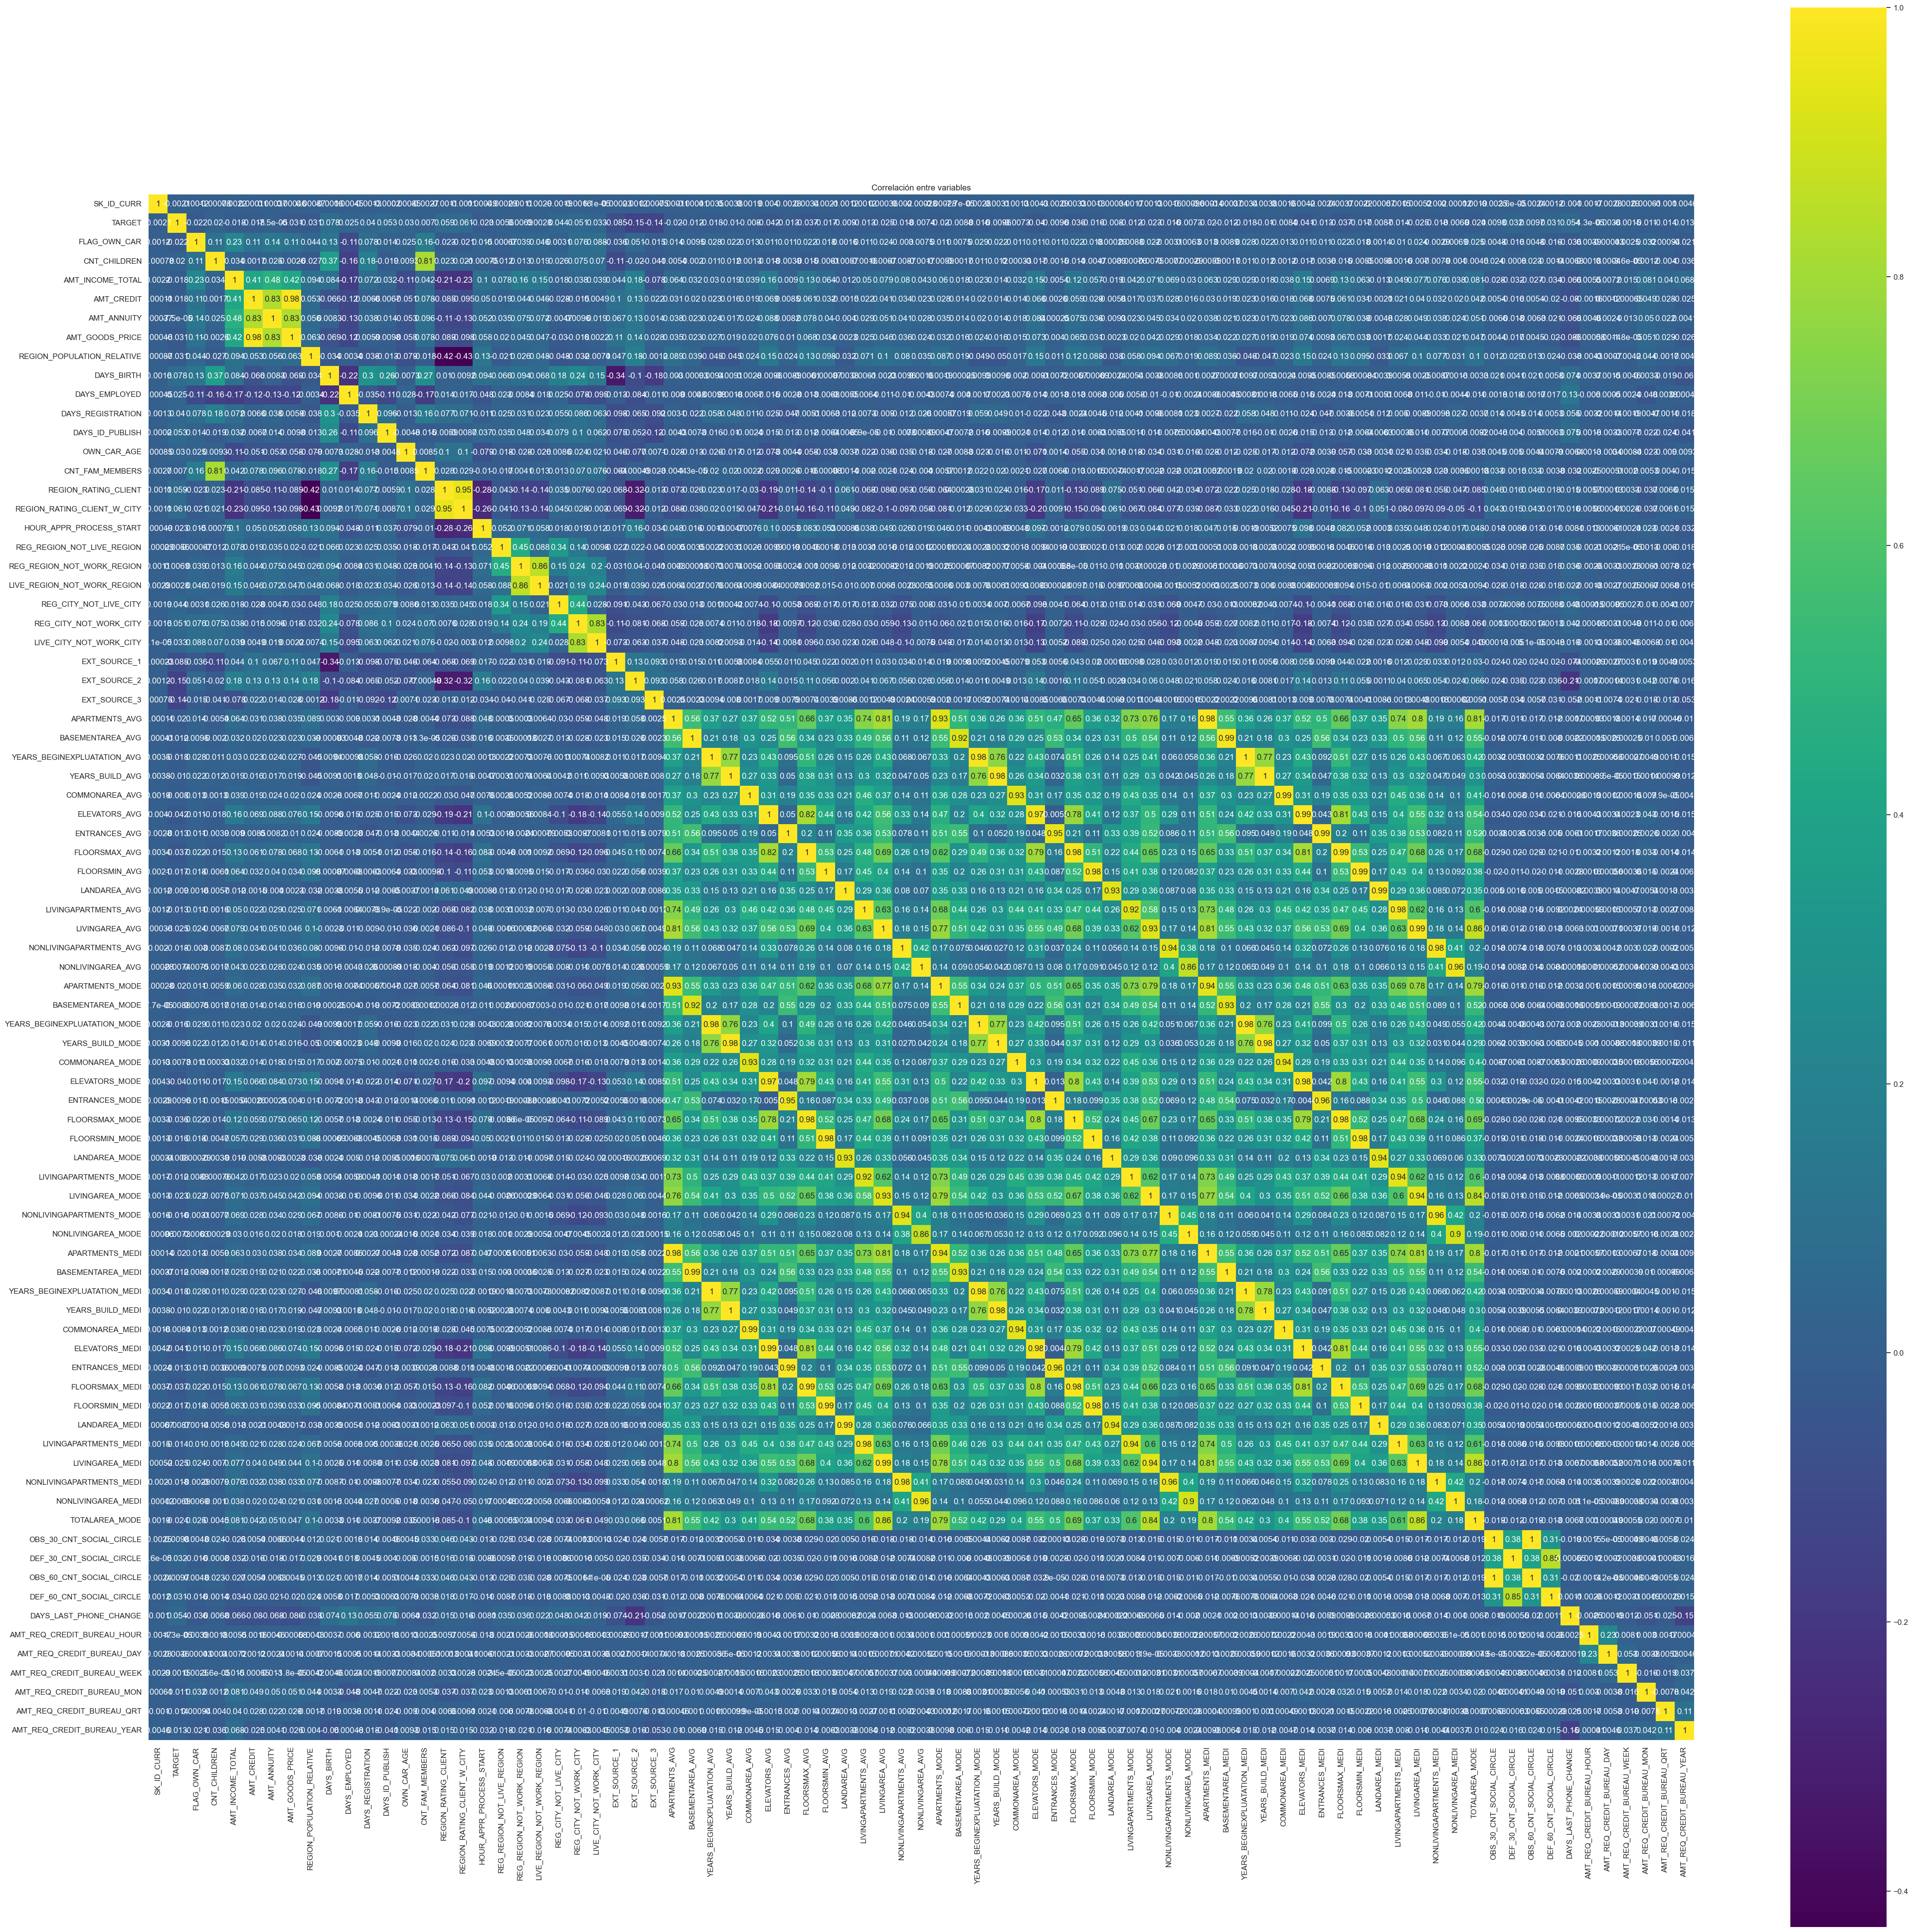

In [23]:
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt



# Seleccionar columnas numéricas para la correlación
columnas_numericas = df.select_dtypes(include=["float64", "int64"]).columns

# Verificar normalidad de cada variable con Shapiro-Wilk
normalidad = {}
for col in columnas_numericas:
    stat, p = stats.shapiro(df[col].dropna())  # Se eliminan valores nulos antes del test
    normalidad[col] = p > 0.05  # True = Normal, False = No normal

# Decidir tipo de correlación
if all(normalidad.values()):  
    metodo = "pearson"
else:
    metodo = "spearman"

print(f"Se usará la correlación de {metodo} porque:")
for col, es_normal in normalidad.items():
    print(f" - {col}: {'Normal' if es_normal else 'No normal'}")

# # Calcular la matriz de correlación
# corr_matrix = df[columnas_numericas].corr(method=metodo)

# # Graficar el mapa de calor
# plt.figure(figsize=(8,6))
# sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# plt.title(f"Matriz de correlación usando {metodo.capitalize()}")
# plt.show()




correlation = df[columnas_numericas].corr(method=metodo)
plt.figure(figsize=(50,50))
ax = sns.heatmap(correlation, vmax=1, square=True, annot = True, cmap = 'viridis')
# Esto se ponde debido al bug de Matplotlib 3.1.1 (quitarlo en versiones diferentes)
#bottom, top = ax.get_ylim()
#ax.set_ylim(bottom + 0.5, top - 0.5)
# ----------
plt.title('Correlación entre variables')
plt.show()


In [24]:

# Seleccionar columnas numéricas para la correlación
columnas_numericas = df.select_dtypes(include=["float64", "int64"]).columns

# Verificar normalidad de cada variable con Kolmogorov-Smirnov
normalidad = {}
for col in columnas_numericas:
    stat, p = stats.kstest(df[col].dropna(), 'norm')  # Se eliminan valores nulos antes del test
    normalidad[col] = p > 0.05  # True = Normal, False = No normal

# Decidir tipo de correlación
if all(normalidad.values()):  
    metodo = "pearson"
else:
    metodo = "spearman"

print(f"Se usará la correlación de {metodo} porque:")
for col, es_normal in normalidad.items():
    print(f" - {col}: {'Normal' if es_normal else 'No normal'}")

# Calcular la matriz de correlación
correlation = df[columnas_numericas].corr(method=metodo)




Se usará la correlación de spearman porque:
 - SK_ID_CURR: No normal
 - TARGET: No normal
 - FLAG_OWN_CAR: No normal
 - CNT_CHILDREN: No normal
 - AMT_INCOME_TOTAL: No normal
 - AMT_CREDIT: No normal
 - AMT_ANNUITY: No normal
 - AMT_GOODS_PRICE: No normal
 - REGION_POPULATION_RELATIVE: No normal
 - DAYS_BIRTH: No normal
 - DAYS_EMPLOYED: No normal
 - DAYS_REGISTRATION: No normal
 - DAYS_ID_PUBLISH: No normal
 - OWN_CAR_AGE: No normal
 - CNT_FAM_MEMBERS: No normal
 - REGION_RATING_CLIENT: No normal
 - REGION_RATING_CLIENT_W_CITY: No normal
 - HOUR_APPR_PROCESS_START: No normal
 - REG_REGION_NOT_LIVE_REGION: No normal
 - REG_REGION_NOT_WORK_REGION: No normal
 - LIVE_REGION_NOT_WORK_REGION: No normal
 - REG_CITY_NOT_LIVE_CITY: No normal
 - REG_CITY_NOT_WORK_CITY: No normal
 - LIVE_CITY_NOT_WORK_CITY: No normal
 - EXT_SOURCE_1: No normal
 - EXT_SOURCE_2: No normal
 - EXT_SOURCE_3: No normal
 - APARTMENTS_AVG: No normal
 - BASEMENTAREA_AVG: No normal
 - YEARS_BEGINEXPLUATATION_AVG: No norma

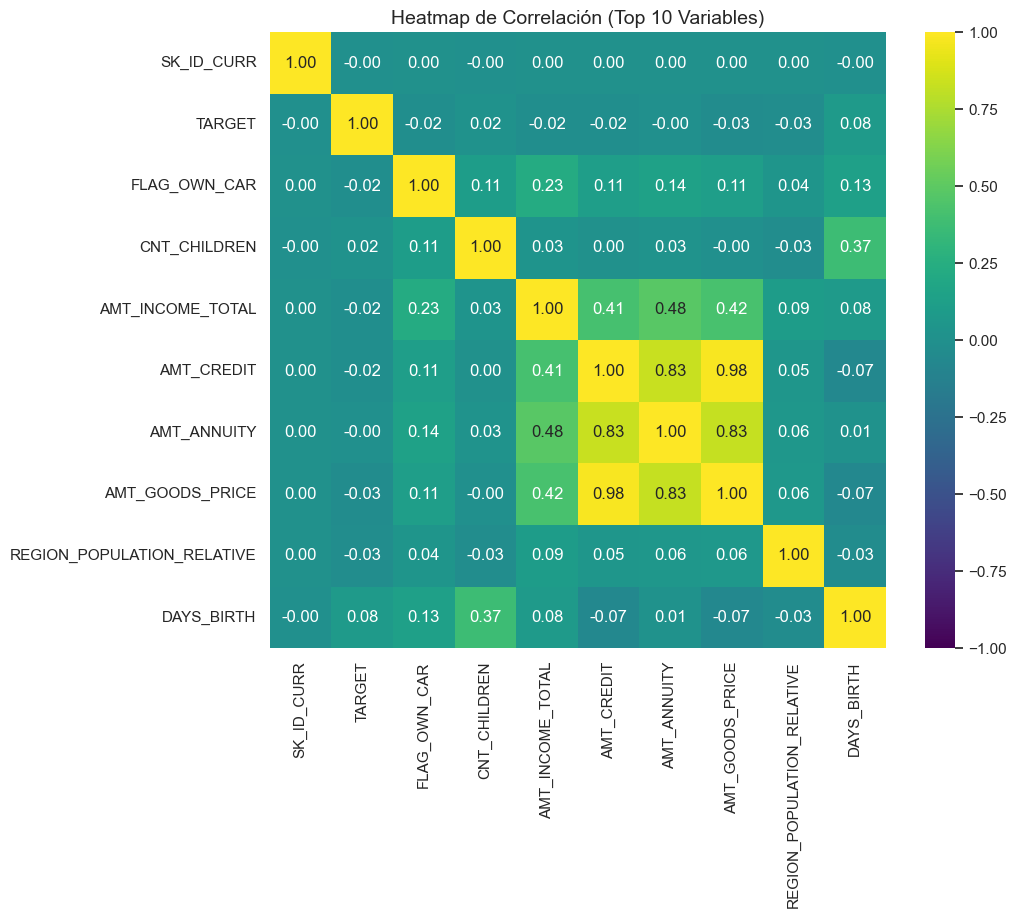

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de correlación
corr_matrix = df[columnas_numericas].corr(method="spearman")

# Seleccionar las primeras 10 variables (sin importar la correlación promedio)
top_10_features = corr_matrix.columns[:10]

# Filtrar la matriz de correlación para esas 10 variables
corr_top_10 = corr_matrix.loc[top_10_features, top_10_features]

# Crear el heatmap
plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr_top_10, annot=True, cmap='viridis', square=True, vmax=1, vmin=-1, fmt=".2f")

# Título del gráfico
plt.title("Heatmap de Correlación (Top 10 Variables)", fontsize=14)
plt.show()



# correlation = df[columnas_numericas].corr(method=metodo)
# plt.figure(figsize=(50,50))
# ax = sns.heatmap(correlation, vmax=1, square=True, annot = True, cmap = 'viridis')
# # Esto se ponde debido al bug de Matplotlib 3.1.1 (quitarlo en versiones diferentes)
# #bottom, top = ax.get_ylim()
# #ax.set_ylim(bottom + 0.5, top - 0.5)
# # ----------
# plt.title('Correlación entre variables')
# plt.show()

In [26]:
#IDENTIFICAR PARES DE VARIABLES CON ALTA CORRELACION ENTRE ELLAS
high_corr_pairs = [(i, j) for i in correlation.columns for j in correlation.columns if i != j and correlation.loc[i, j] > 0.8]

print('PARES DE VARIABLES CON ALTA CORRELACION ENTRE ELLAS:')
for PAR in high_corr_pairs:
    print(PAR)

PARES DE VARIABLES CON ALTA CORRELACION ENTRE ELLAS:
('CNT_CHILDREN', 'CNT_FAM_MEMBERS')
('AMT_CREDIT', 'AMT_ANNUITY')
('AMT_CREDIT', 'AMT_GOODS_PRICE')
('AMT_ANNUITY', 'AMT_CREDIT')
('AMT_ANNUITY', 'AMT_GOODS_PRICE')
('AMT_GOODS_PRICE', 'AMT_CREDIT')
('AMT_GOODS_PRICE', 'AMT_ANNUITY')
('CNT_FAM_MEMBERS', 'CNT_CHILDREN')
('REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY')
('REGION_RATING_CLIENT_W_CITY', 'REGION_RATING_CLIENT')
('REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION')
('LIVE_REGION_NOT_WORK_REGION', 'REG_REGION_NOT_WORK_REGION')
('REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY')
('LIVE_CITY_NOT_WORK_CITY', 'REG_CITY_NOT_WORK_CITY')
('APARTMENTS_AVG', 'LIVINGAREA_AVG')
('APARTMENTS_AVG', 'APARTMENTS_MODE')
('APARTMENTS_AVG', 'APARTMENTS_MEDI')
('APARTMENTS_AVG', 'LIVINGAREA_MEDI')
('APARTMENTS_AVG', 'TOTALAREA_MODE')
('BASEMENTAREA_AVG', 'BASEMENTAREA_MODE')
('BASEMENTAREA_AVG', 'BASEMENTAREA_MEDI')
('YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MODE

como vemos tenemos varios pares, lo interesante es que vemos casos donde tenemos el promedio, la media de una misma variable y la moda igual. Estas últimas se eliminan porque estan altamente correlacionadas con la media como es de esperar

In [27]:
numerics_columns = df.select_dtypes(include=['int64', 'float64']).columns
filtered_columns = [col for col in numerics_columns if 'mode' in col.lower()]
filtered_columns


['APARTMENTS_MODE',
 'BASEMENTAREA_MODE',
 'YEARS_BEGINEXPLUATATION_MODE',
 'YEARS_BUILD_MODE',
 'COMMONAREA_MODE',
 'ELEVATORS_MODE',
 'ENTRANCES_MODE',
 'FLOORSMAX_MODE',
 'FLOORSMIN_MODE',
 'LANDAREA_MODE',
 'LIVINGAPARTMENTS_MODE',
 'LIVINGAREA_MODE',
 'NONLIVINGAPARTMENTS_MODE',
 'NONLIVINGAREA_MODE',
 'TOTALAREA_MODE']

In [28]:
numerics_columns = df.select_dtypes(include=['int64', 'float64']).columns
filtered_columns = [col for col in numerics_columns if 'medi' in col.lower()]
filtered_columns


['APARTMENTS_MEDI',
 'BASEMENTAREA_MEDI',
 'YEARS_BEGINEXPLUATATION_MEDI',
 'YEARS_BUILD_MEDI',
 'COMMONAREA_MEDI',
 'ELEVATORS_MEDI',
 'ENTRANCES_MEDI',
 'FLOORSMAX_MEDI',
 'FLOORSMIN_MEDI',
 'LANDAREA_MEDI',
 'LIVINGAPARTMENTS_MEDI',
 'LIVINGAREA_MEDI',
 'NONLIVINGAPARTMENTS_MEDI',
 'NONLIVINGAREA_MEDI']

In [29]:
colums =['APARTMENTS_MEDI',
 'BASEMENTAREA_MEDI',
 'YEARS_BEGINEXPLUATATION_MEDI',
 'YEARS_BUILD_MEDI',
 'COMMONAREA_MEDI',
 'ELEVATORS_MEDI',
 'ENTRANCES_MEDI',
 'FLOORSMAX_MEDI',
 'FLOORSMIN_MEDI',
 'LANDAREA_MEDI',
 'LIVINGAPARTMENTS_MEDI',
 'LIVINGAREA_MEDI',
 'NONLIVINGAPARTMENTS_MEDI',
 'NONLIVINGAREA_MEDI','APARTMENTS_MODE',
 'BASEMENTAREA_MODE',
 'YEARS_BEGINEXPLUATATION_MODE',
 'YEARS_BUILD_MODE',
 'COMMONAREA_MODE',
 'ELEVATORS_MODE',
 'ENTRANCES_MODE',
 'FLOORSMAX_MODE',
 'FLOORSMIN_MODE',
 'LANDAREA_MODE',
 'LIVINGAPARTMENTS_MODE',
 'LIVINGAREA_MODE',
 'NONLIVINGAPARTMENTS_MODE',
 'NONLIVINGAREA_MODE',
 'TOTALAREA_MODE']
df.drop(columns=colums,axis=1 ,inplace=True)


In [31]:
colums =['LIVINGAPARTMENTS_AVG',
 'LIVINGAREA_AVG',
 'YEARS_BEGINEXPLUATATION_AVG']
df.drop(columns=colums,axis=1 ,inplace=True)

'SK_ID_CURR' es un identificador y no tiene sentido en nuestro análisis así que lo quitamos

In [32]:
df.drop(columns= ['SK_ID_CURR'],axis=1,inplace=True)

# 5) GRAFICOS DE VARIABLES CATEGORICAS

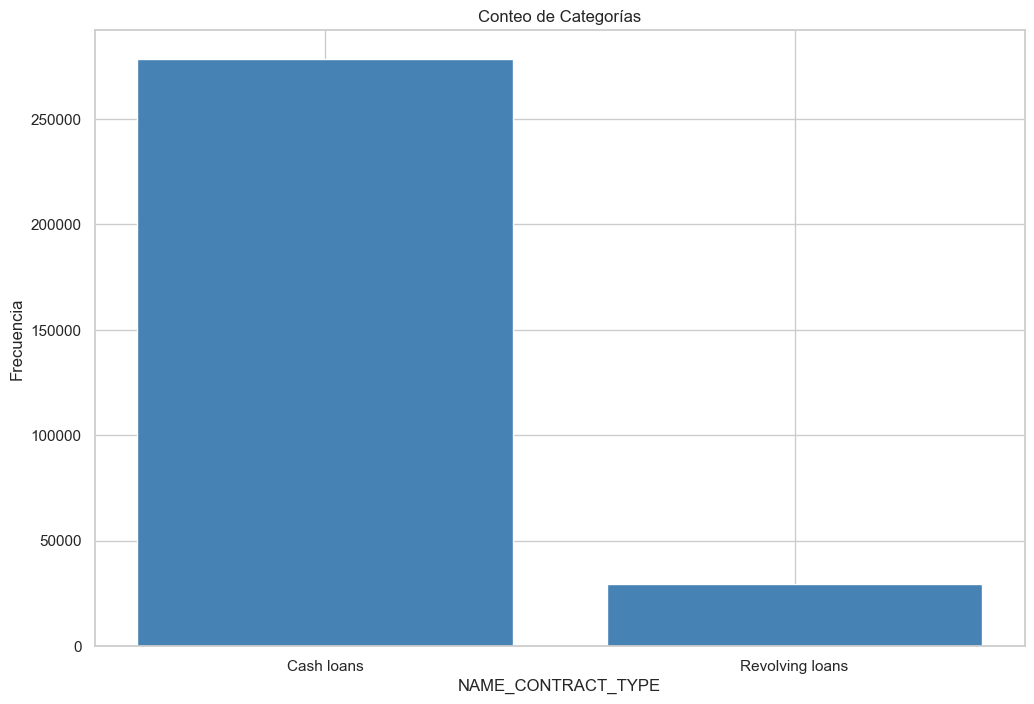

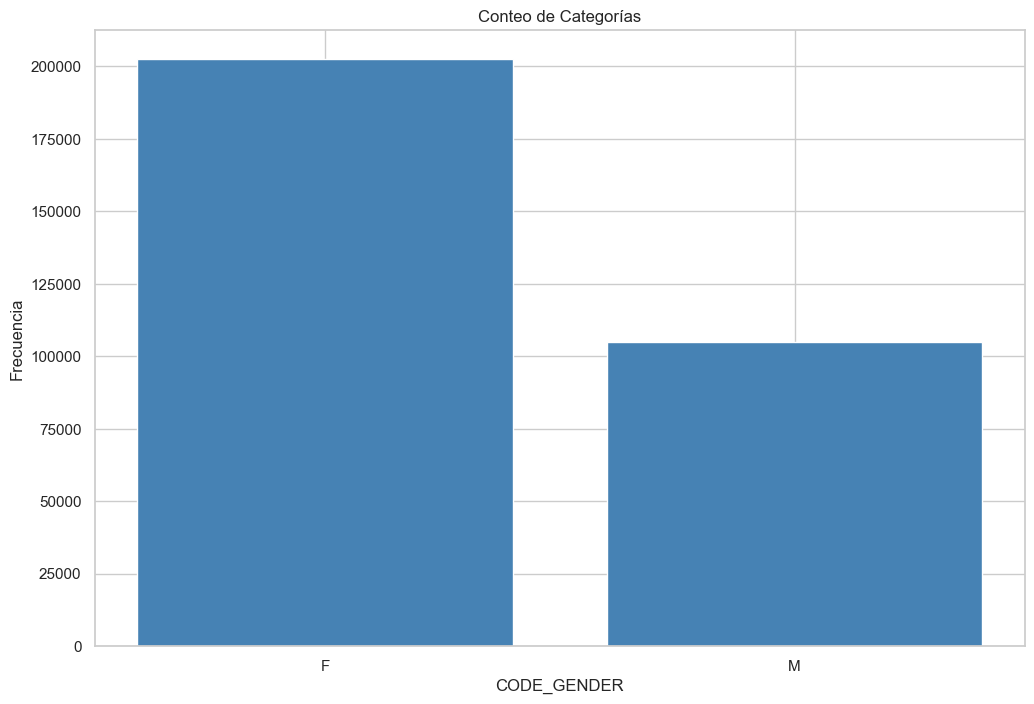

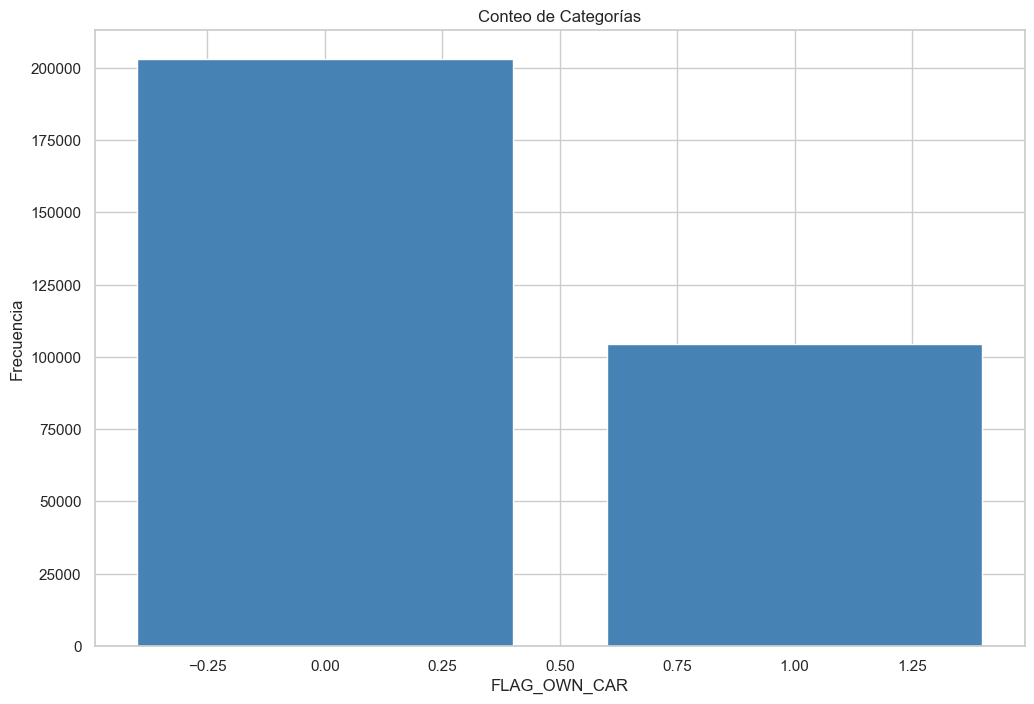

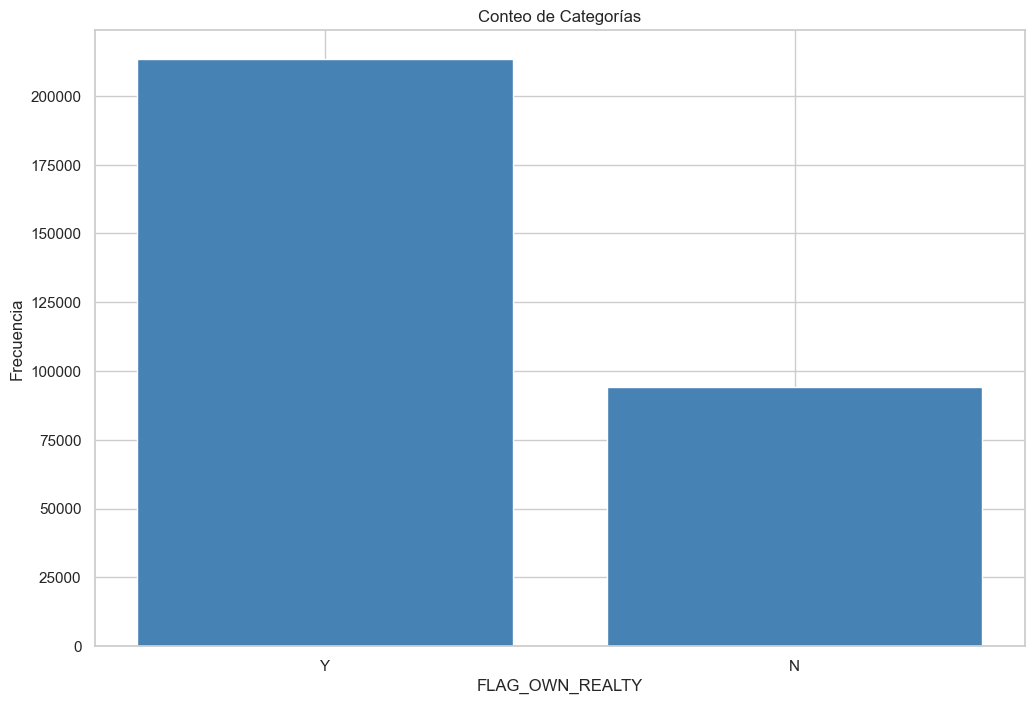

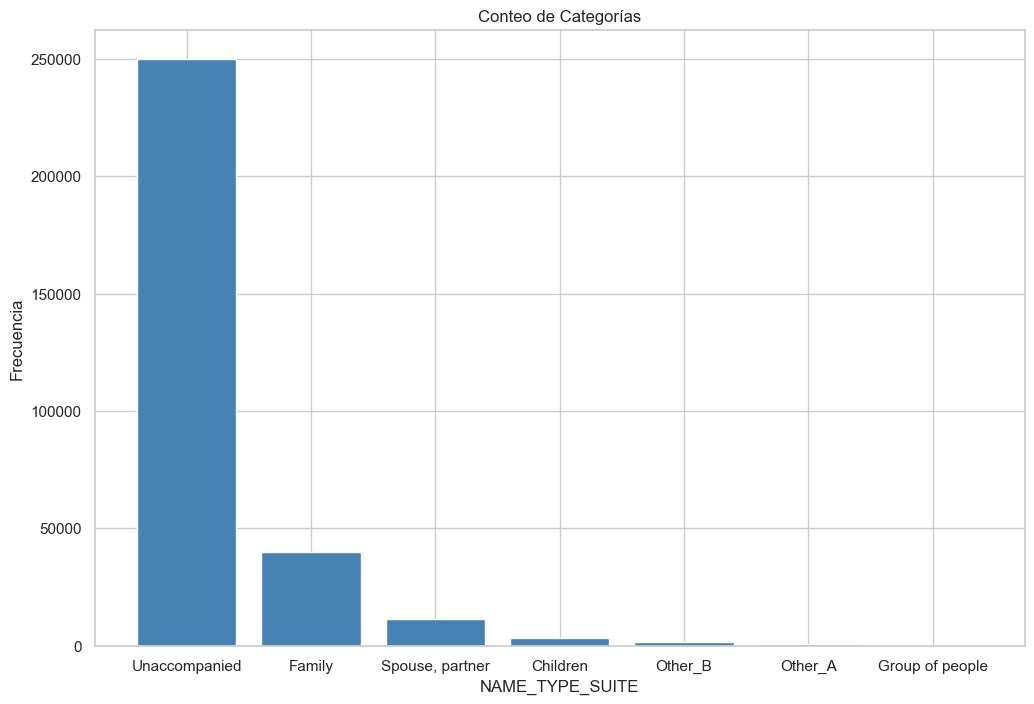

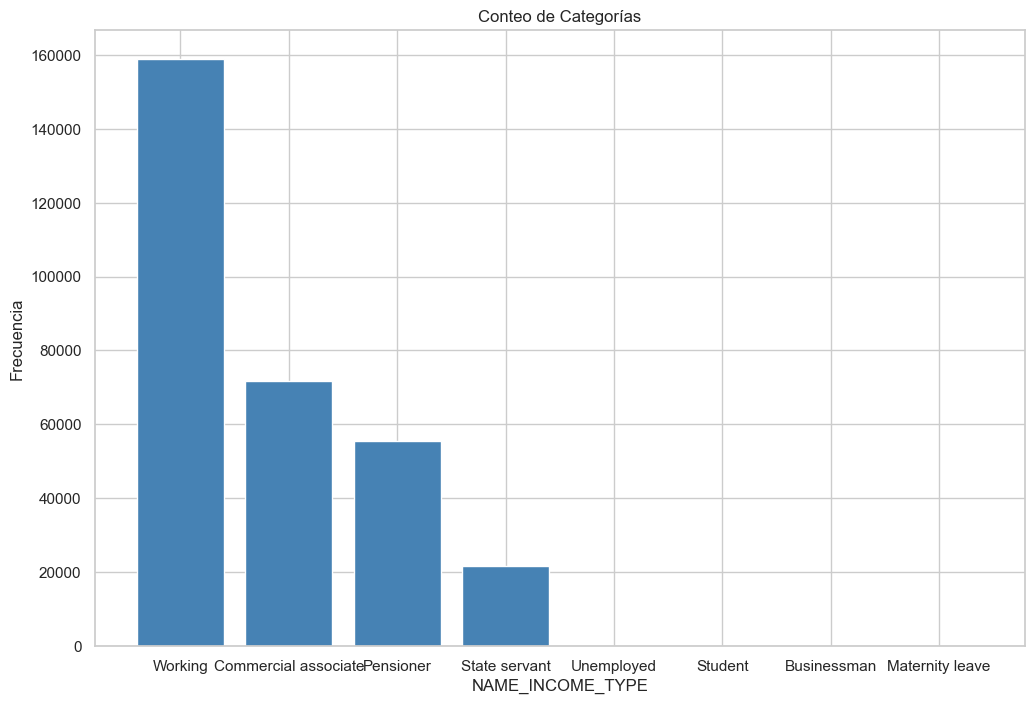

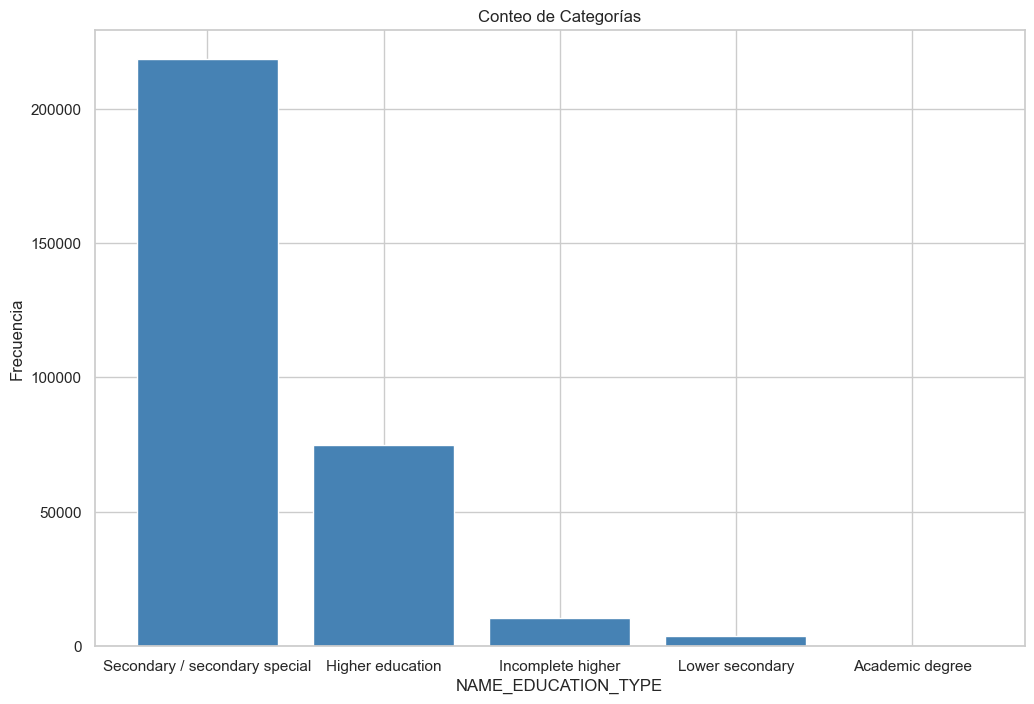

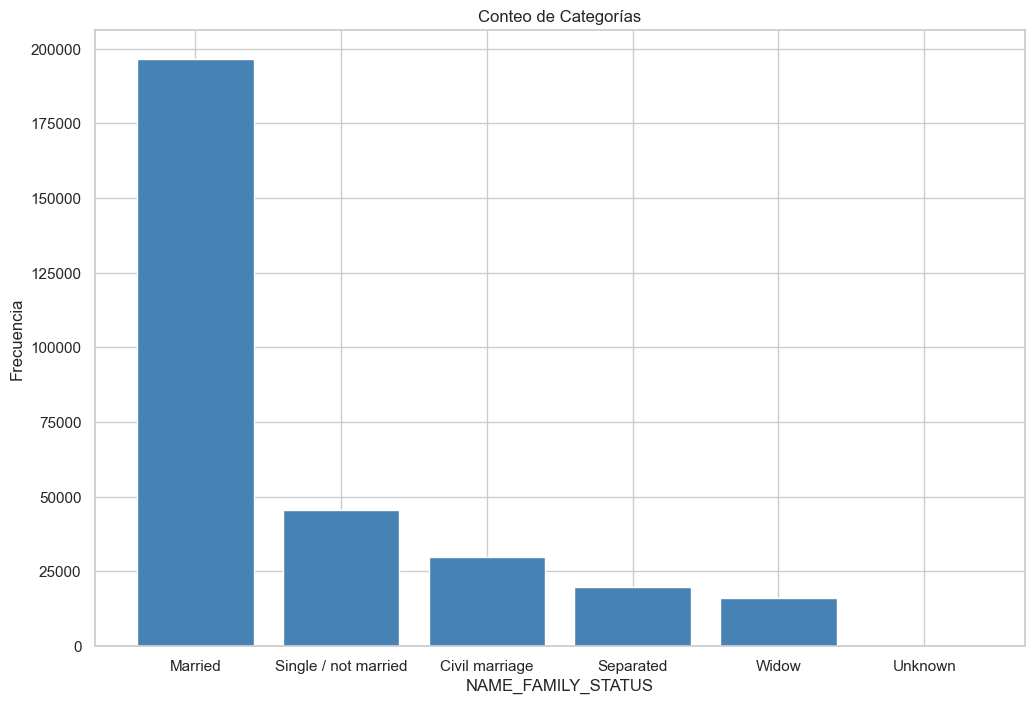

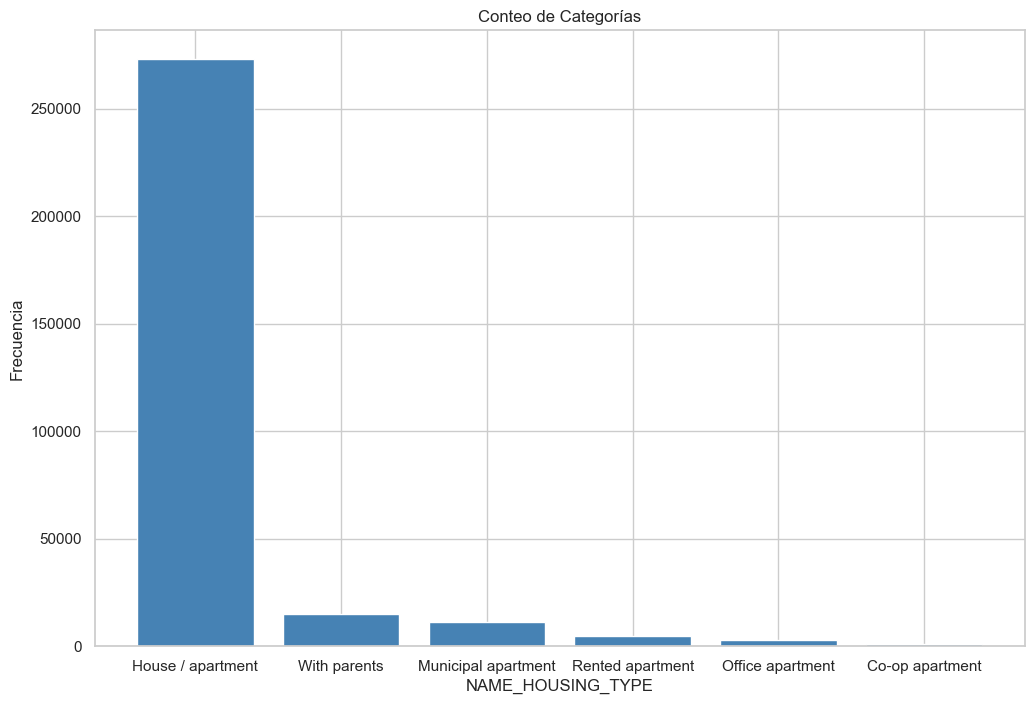

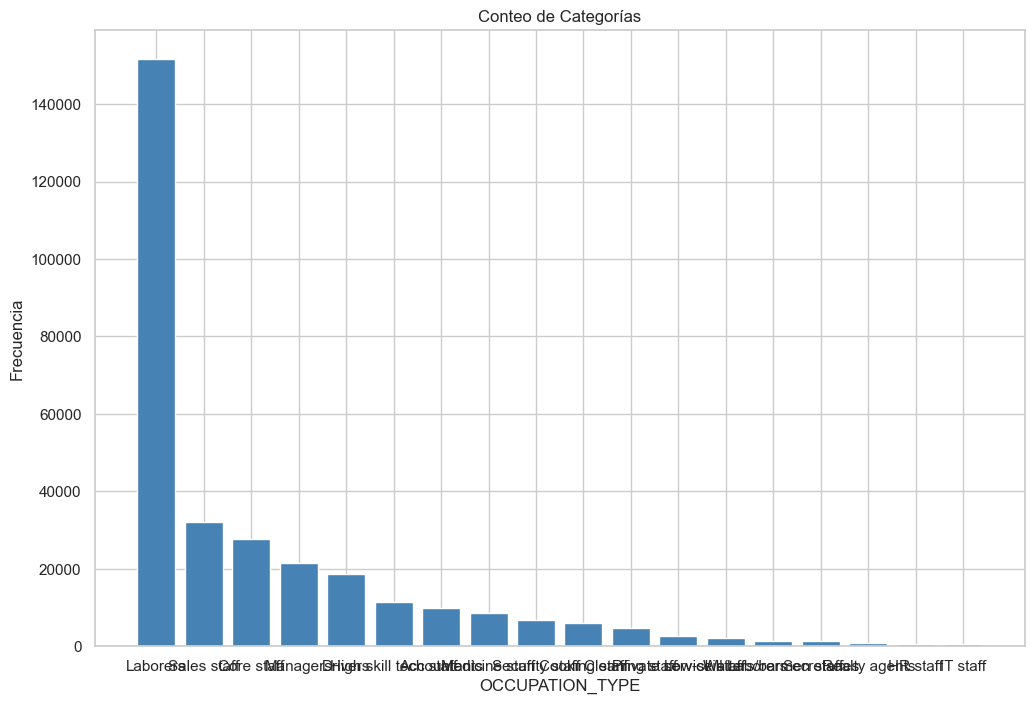

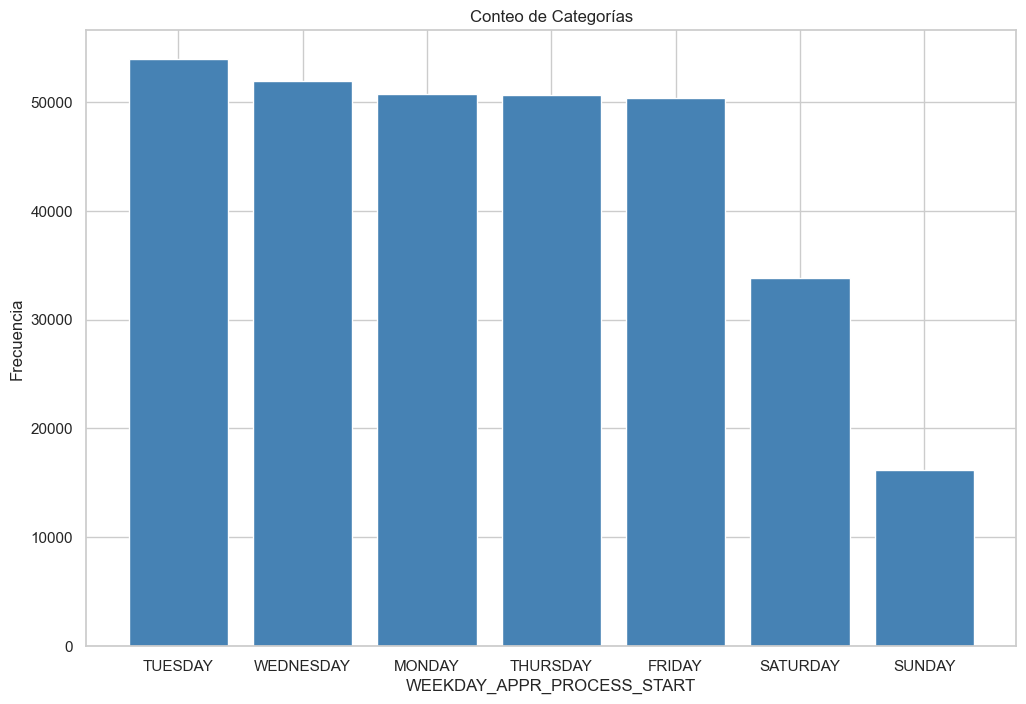

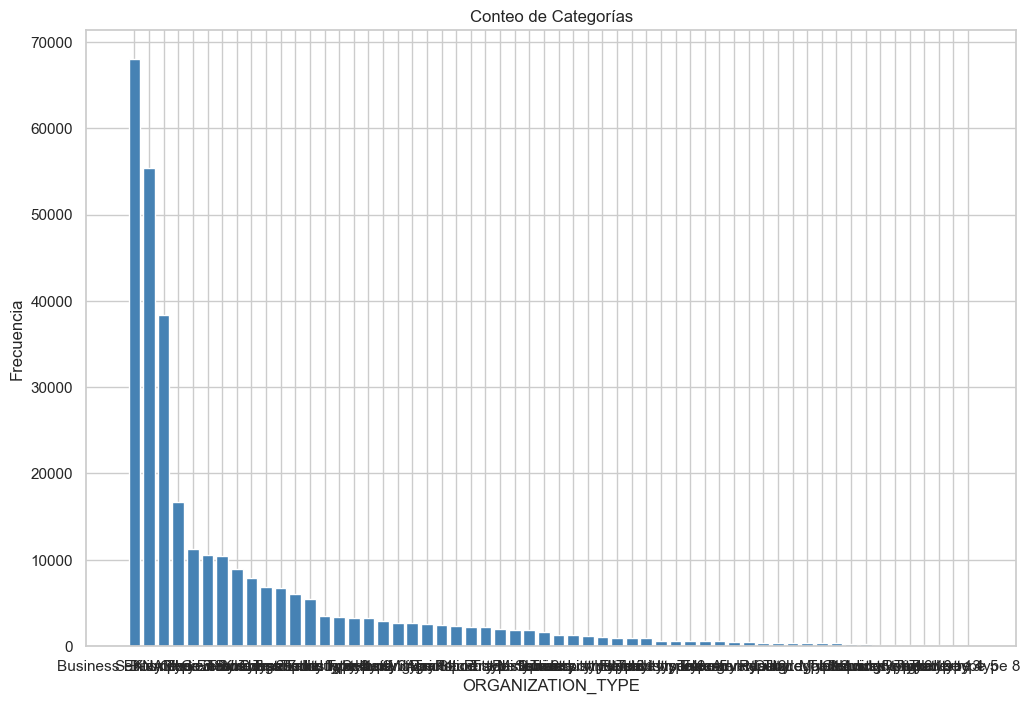

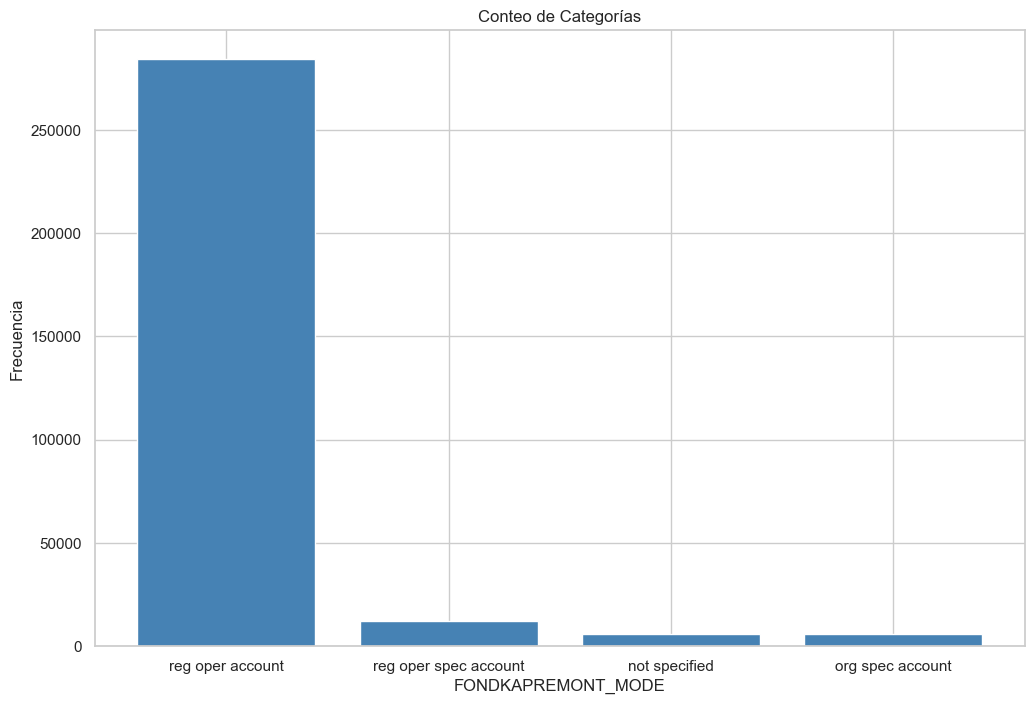

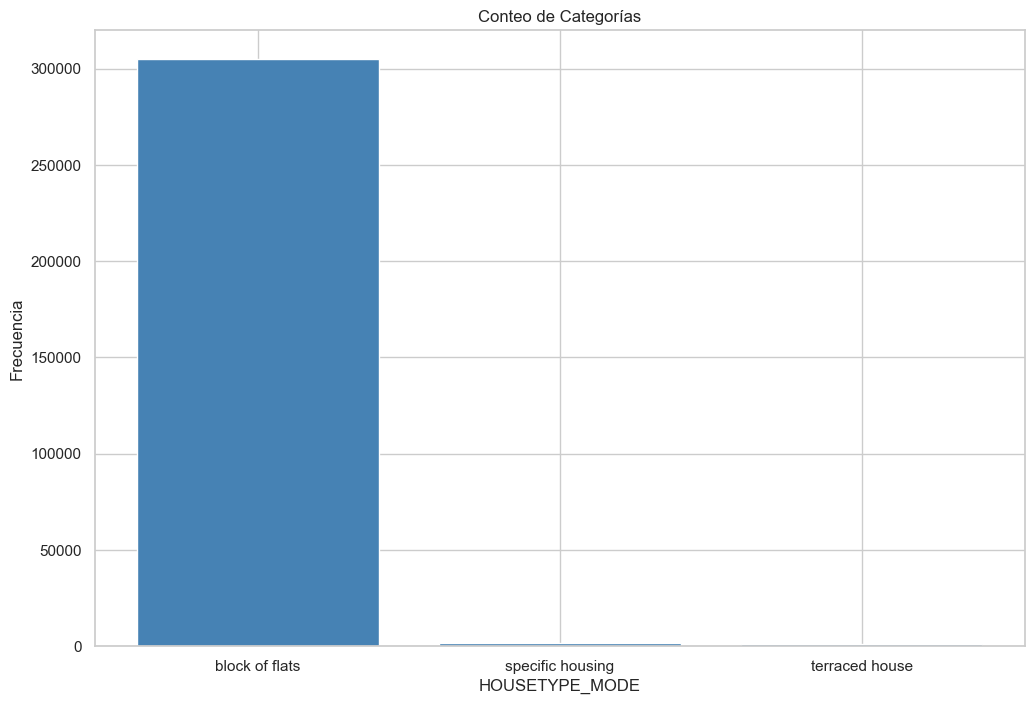

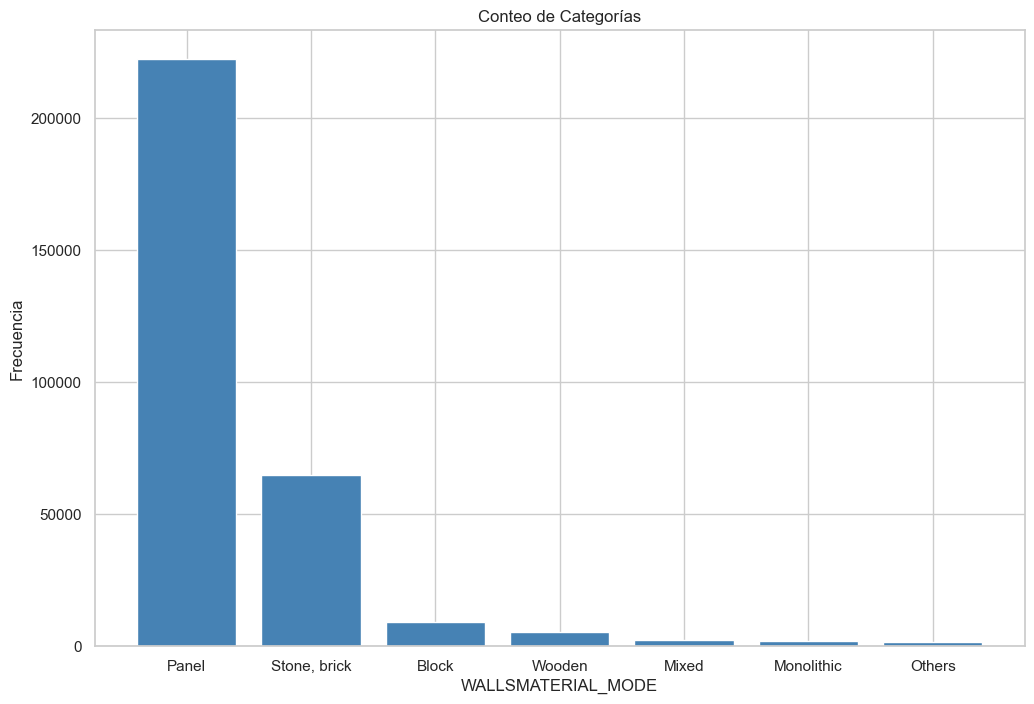

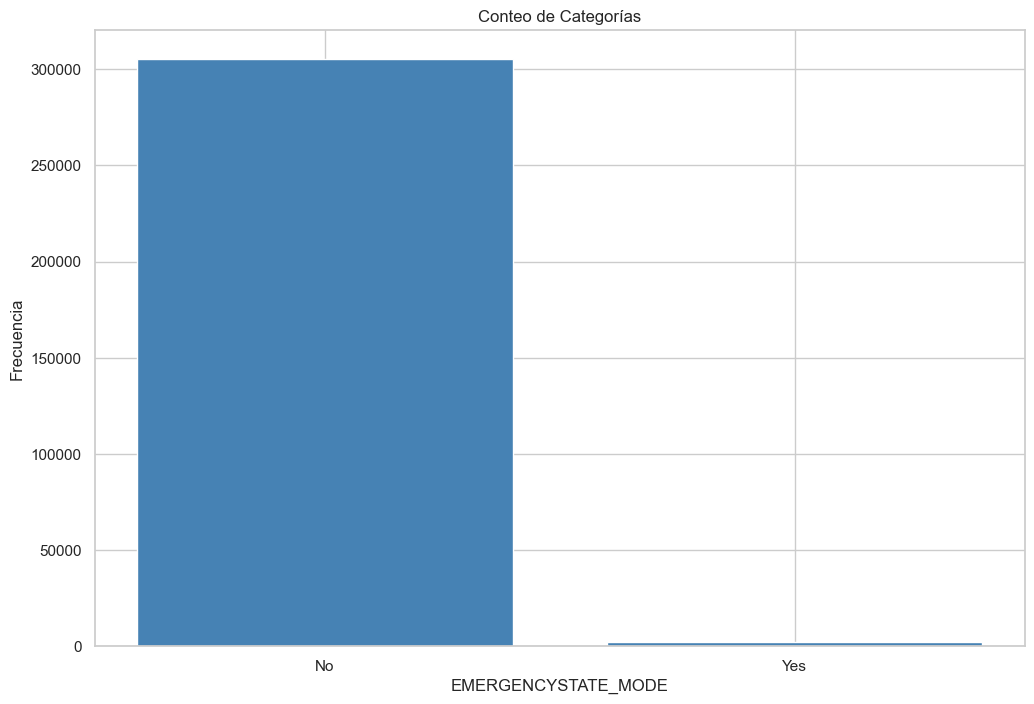

In [33]:
for string  in string_columns:
   # Contar frecuencias
    counts = df[string].value_counts()

    # Graficar
    plt.bar(counts.index, counts.values, color='steelblue')
    plt.title("Conteo de Categorías")
    plt.xlabel(f"{string}")
    plt.ylabel("Frecuencia")
    plt.show()

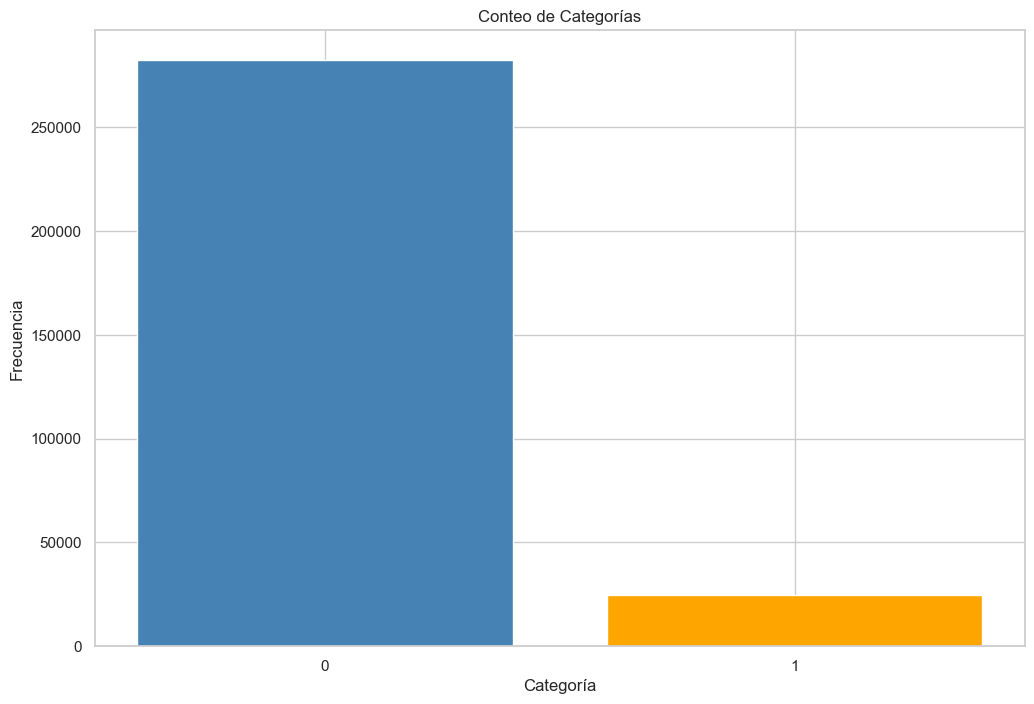

In [34]:
import matplotlib.pyplot as plt

# Contar las categorías
counts = df['TARGET'].astype("string").value_counts()

# Definir colores alternativos
colors = ['steelblue', 'orange']

# Graficar
plt.bar(counts.index, counts.values, color=colors)
plt.title("Conteo de Categorías")
plt.xlabel("Categoría")
plt.ylabel("Frecuencia")
plt.show()


¡ Como podemos ver el TARGET no está balanceado !

# Distribucion de variables categoricas versus el target

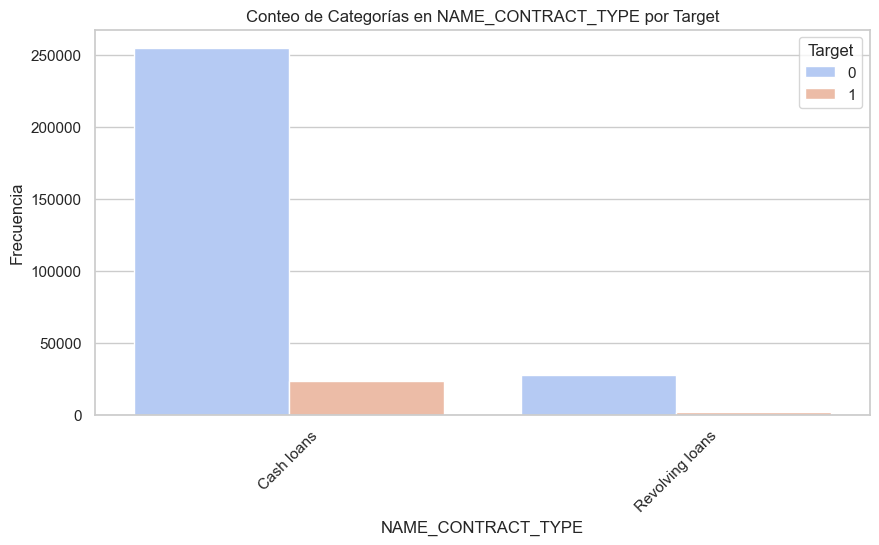

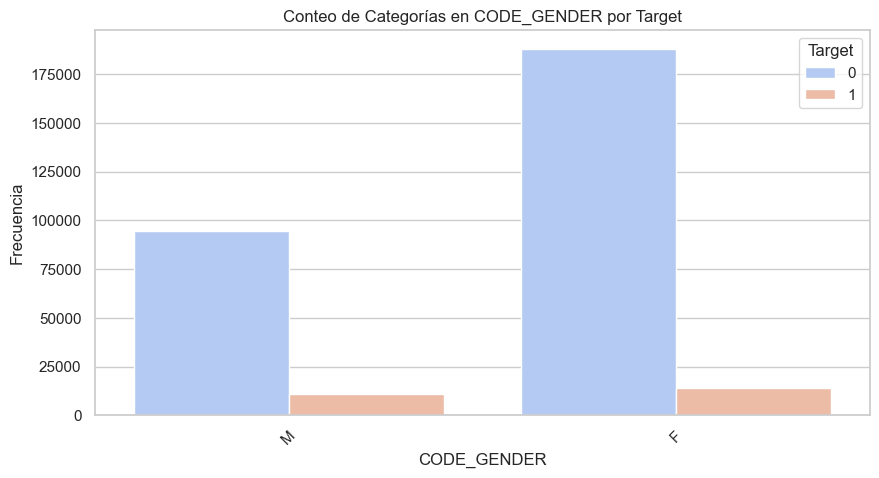

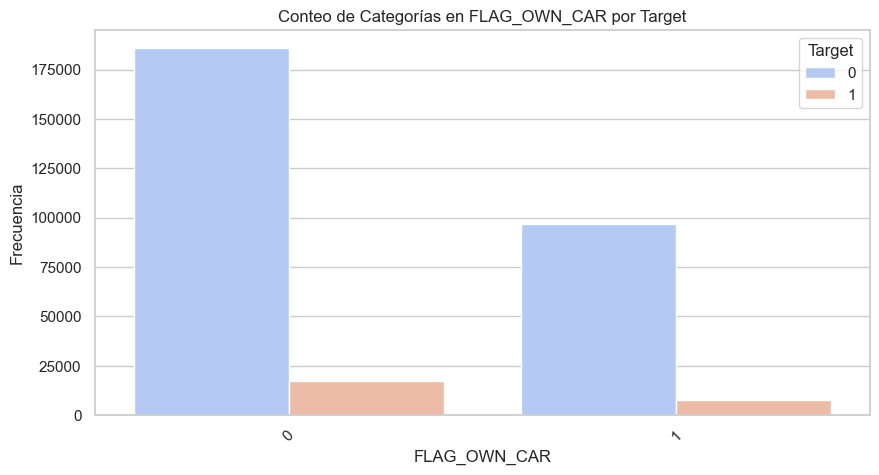

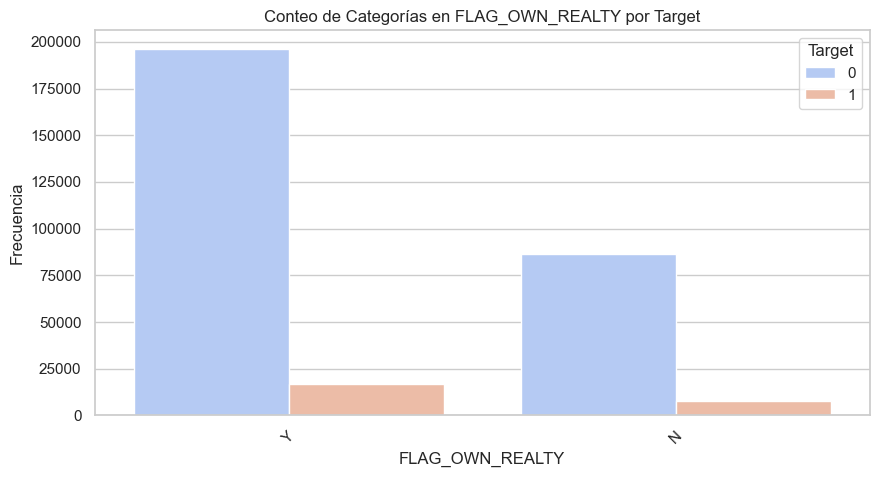

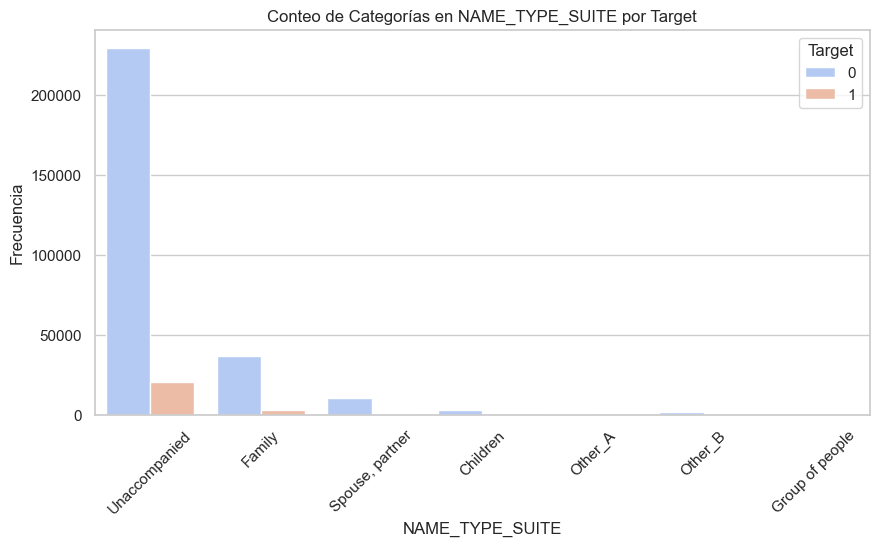

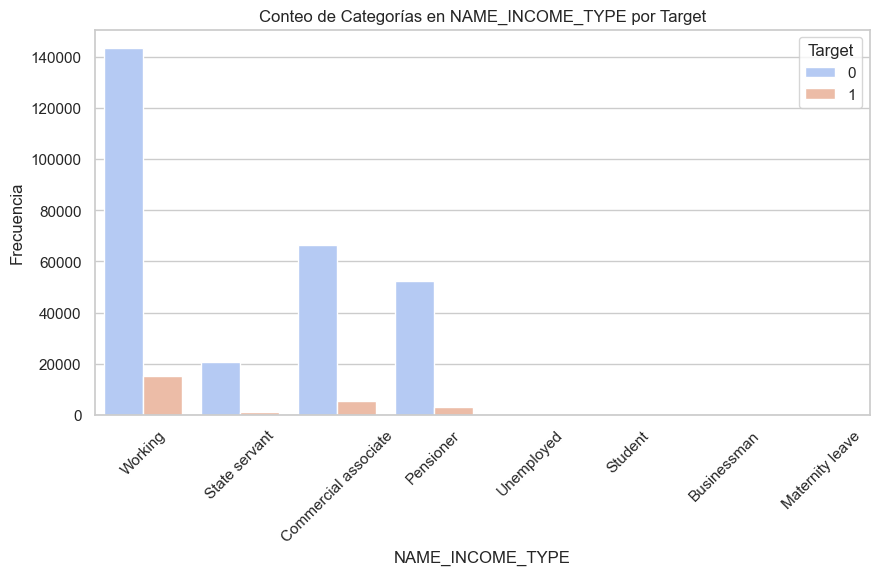

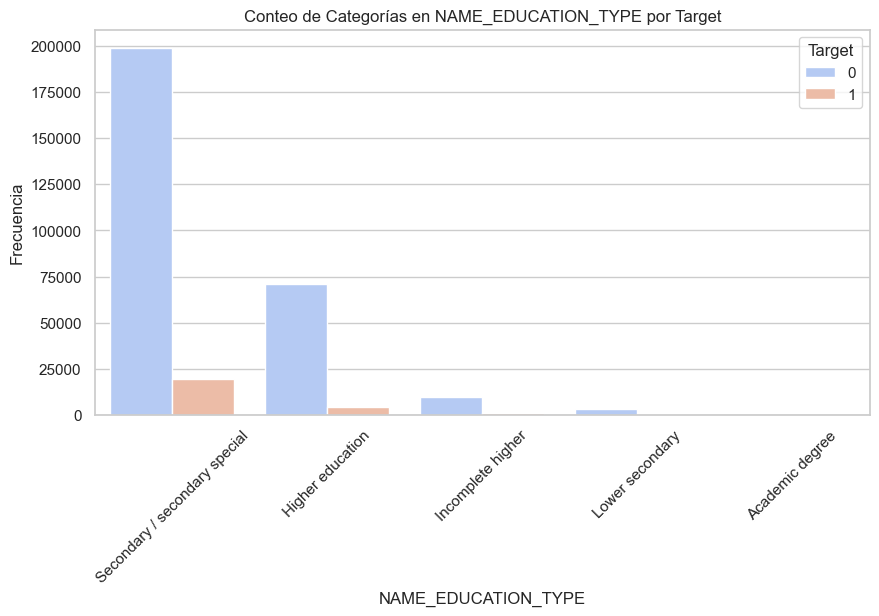

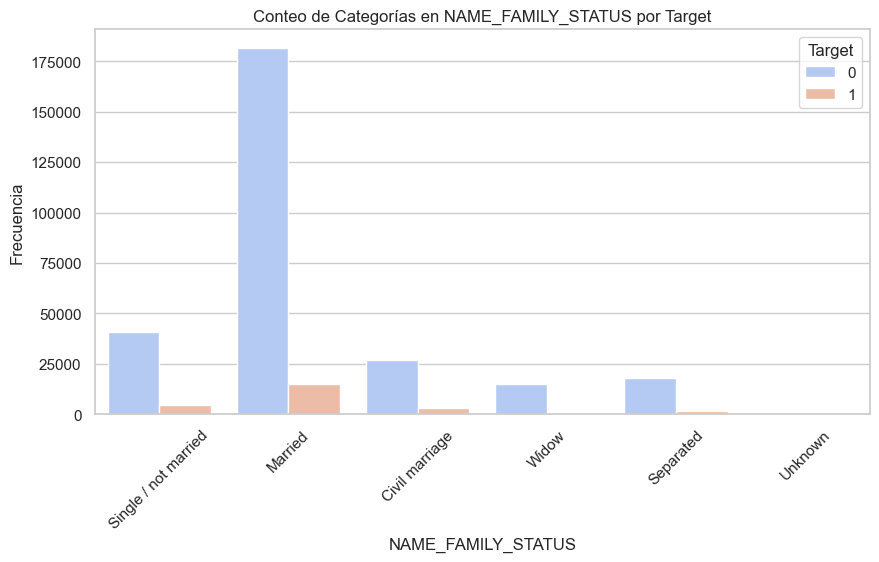

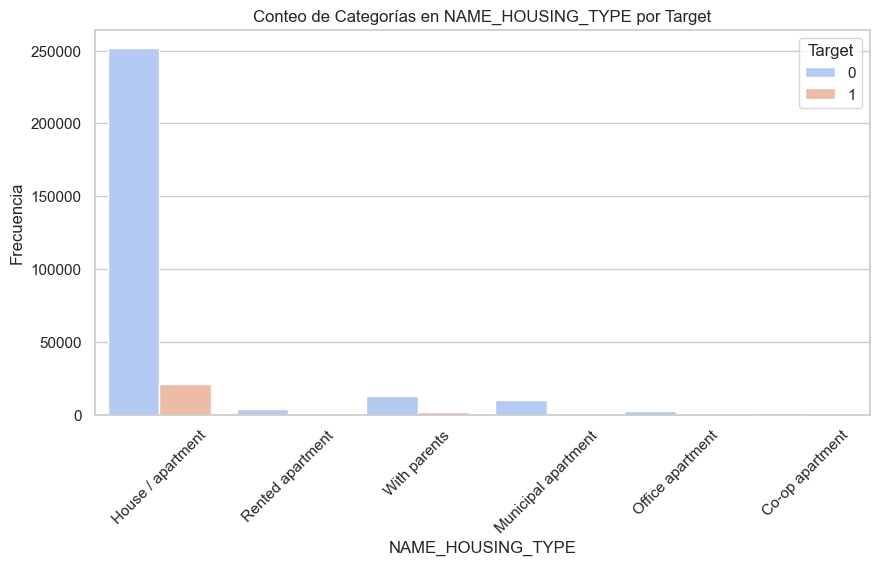

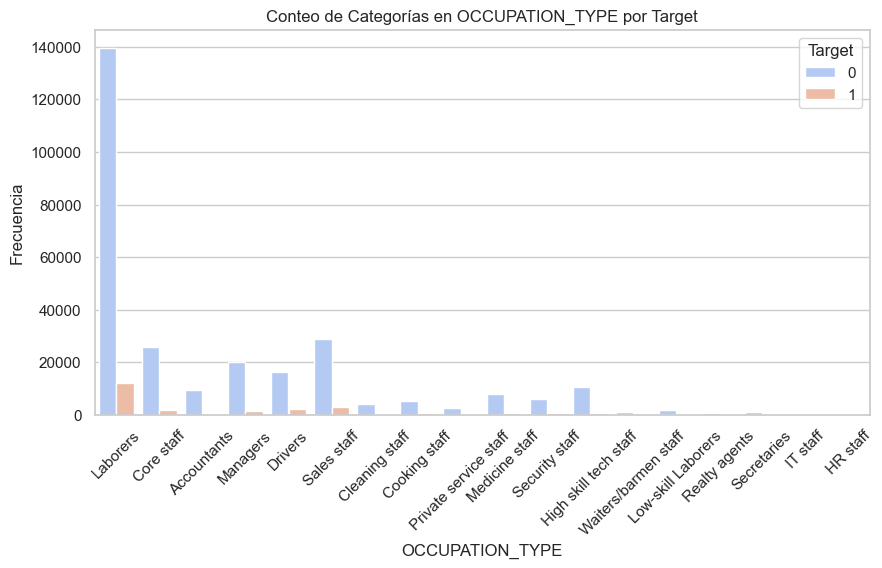

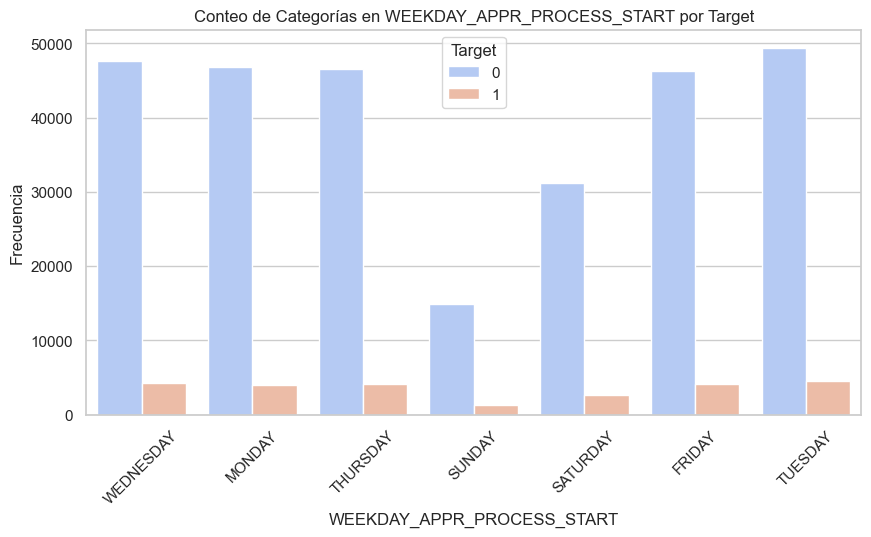

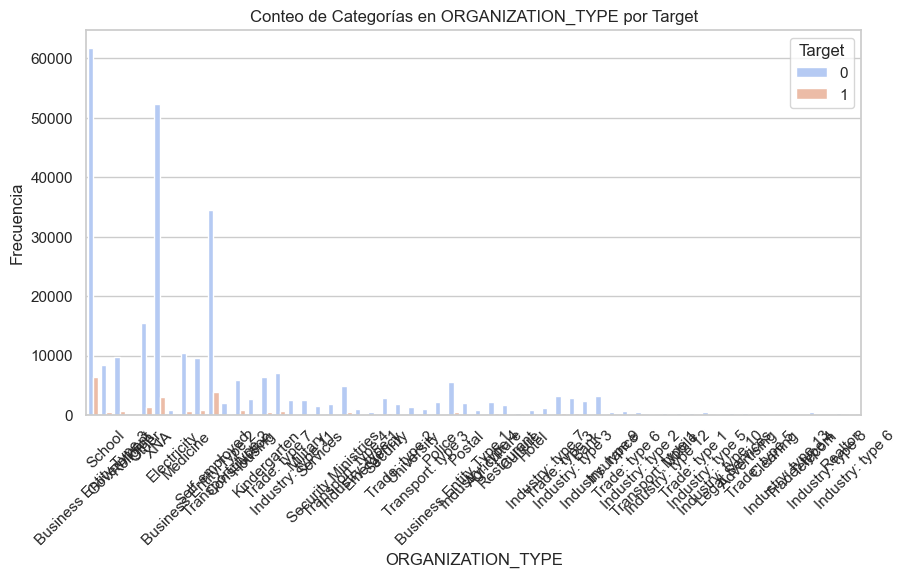

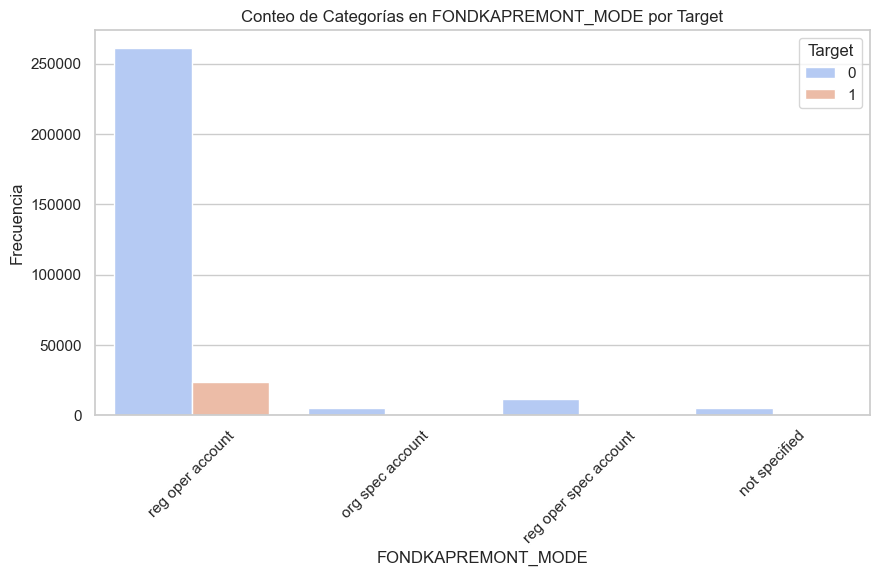

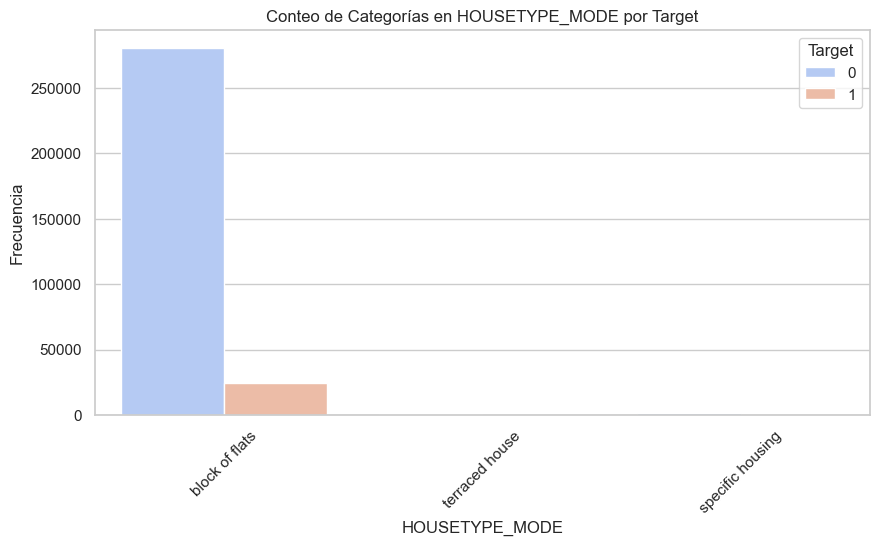

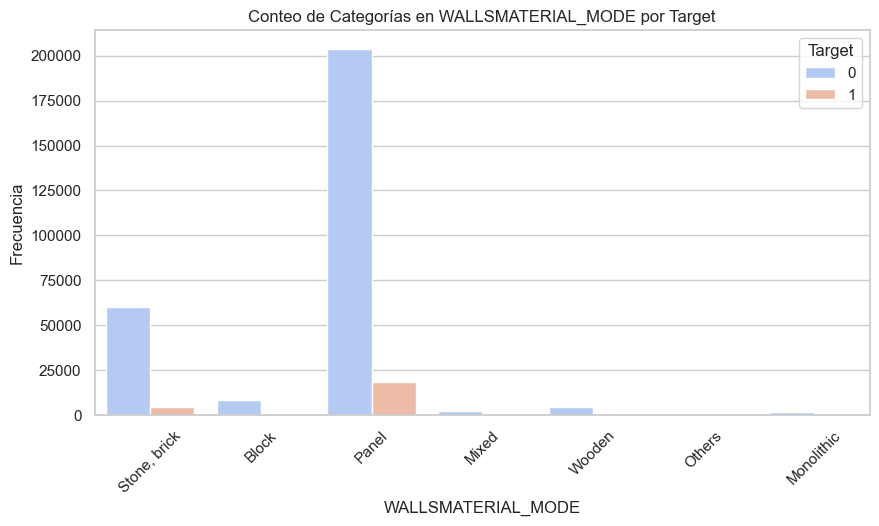

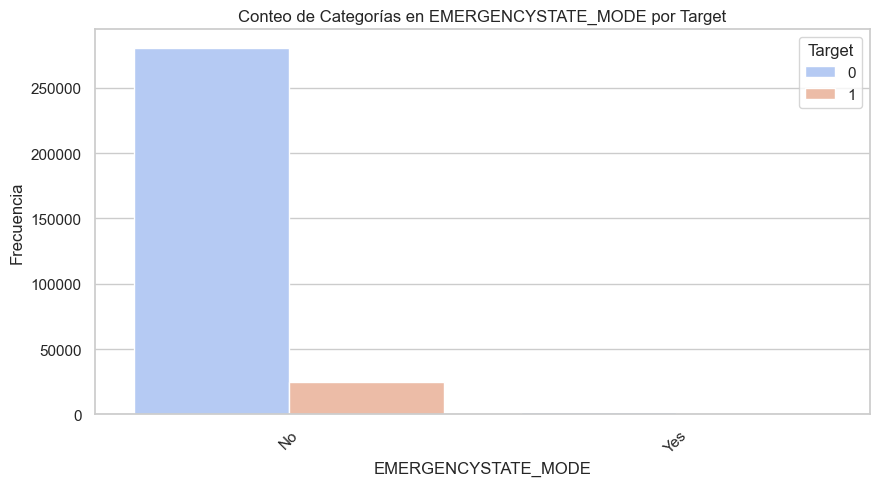

In [35]:
for string in string_columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=string, hue="TARGET", palette="coolwarm")
    
    plt.title(f"Conteo de Categorías en {string} por Target")
    plt.xlabel(string)
    plt.ylabel("Frecuencia")
    plt.legend(title="Target")
    plt.xticks(rotation=45)
    plt.show()

df

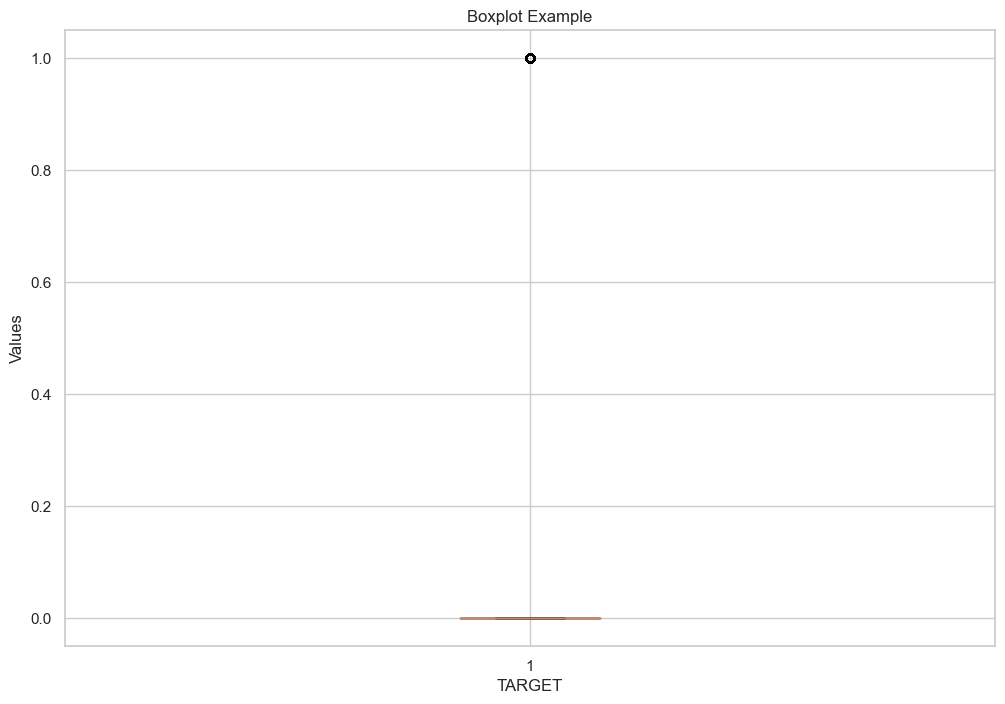

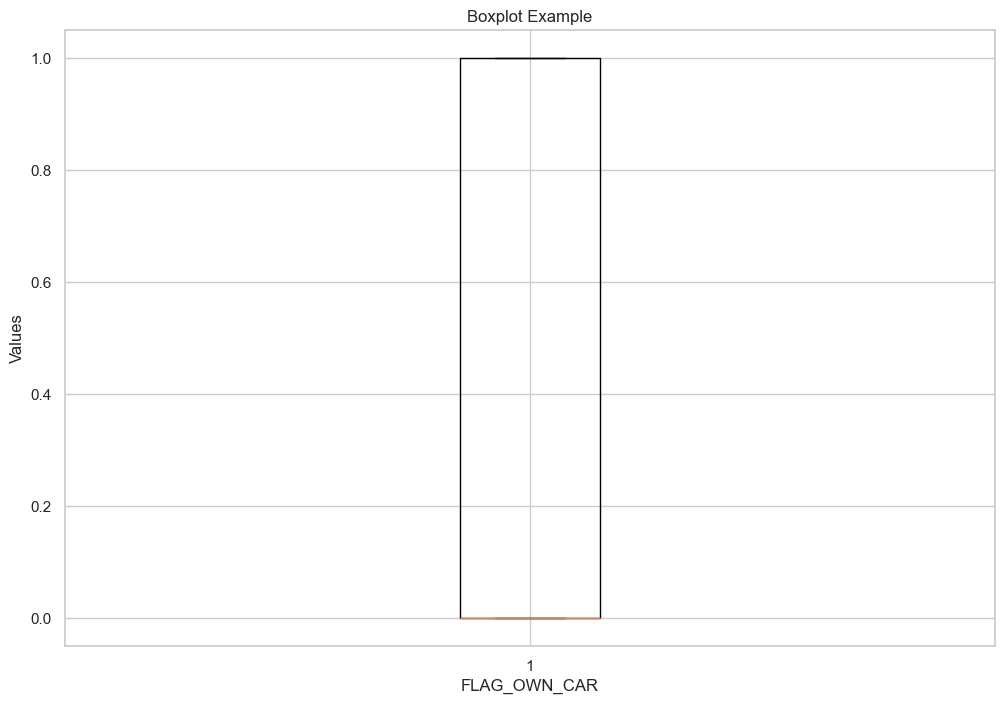

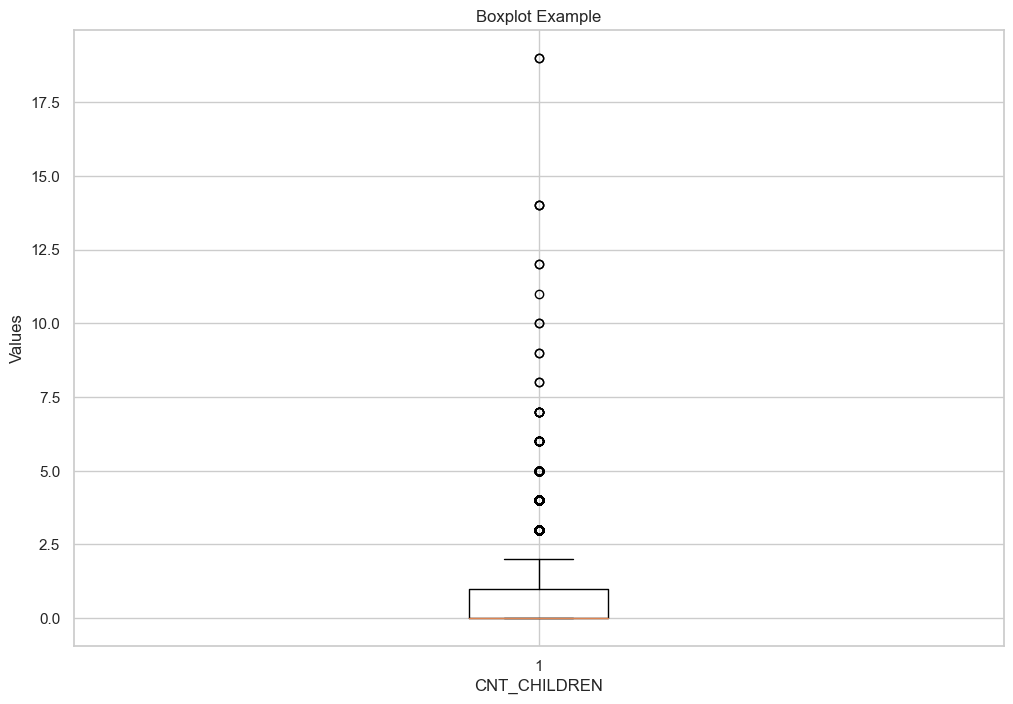

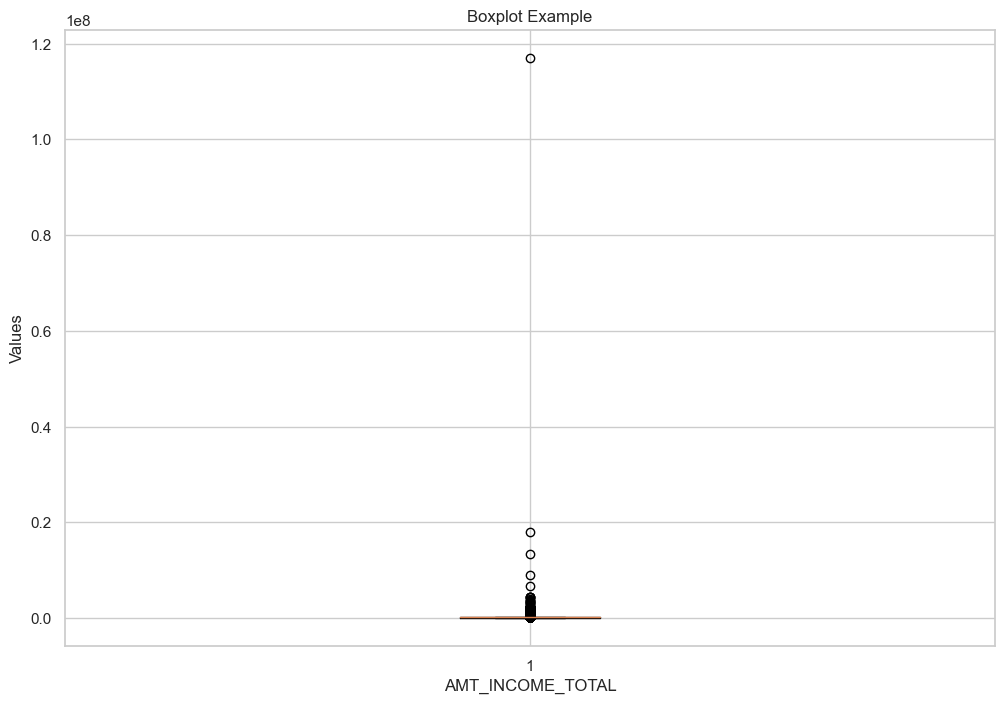

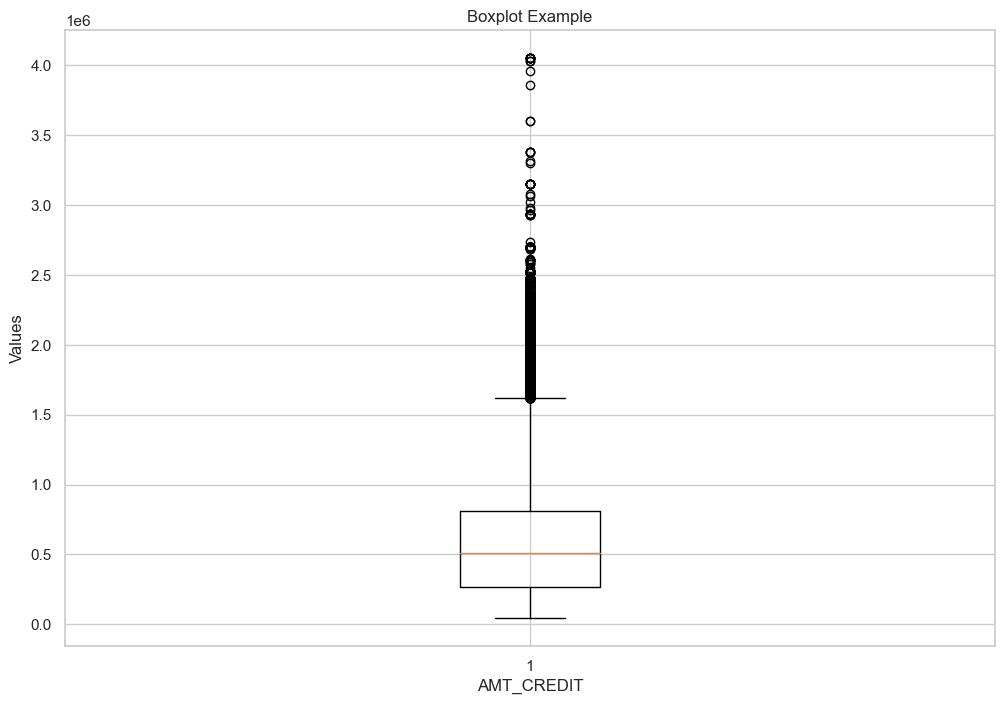

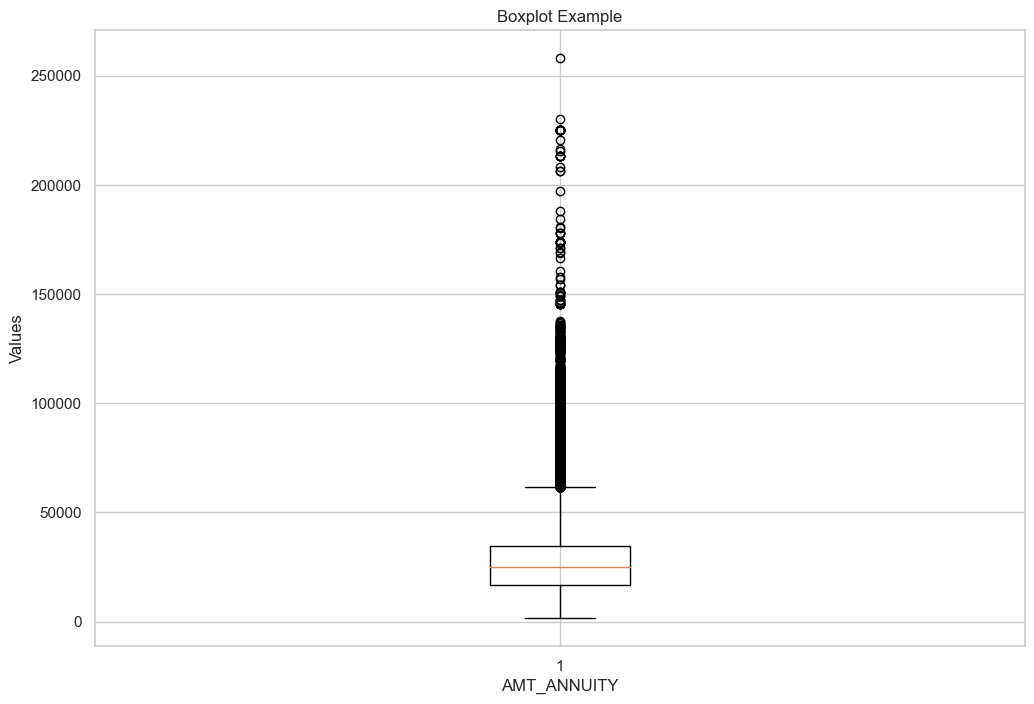

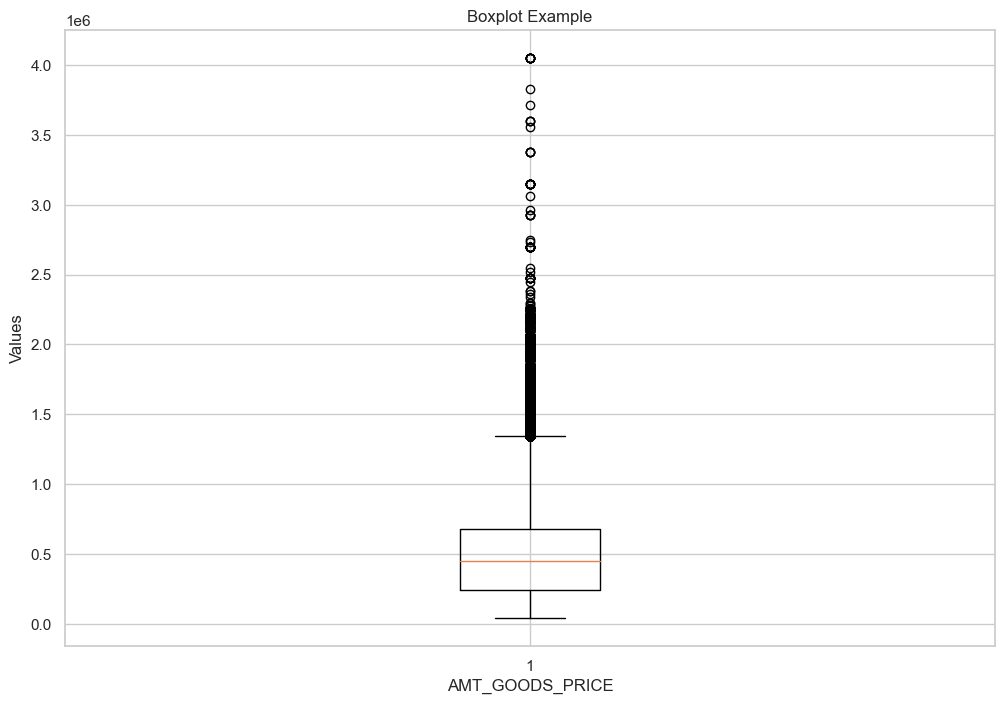

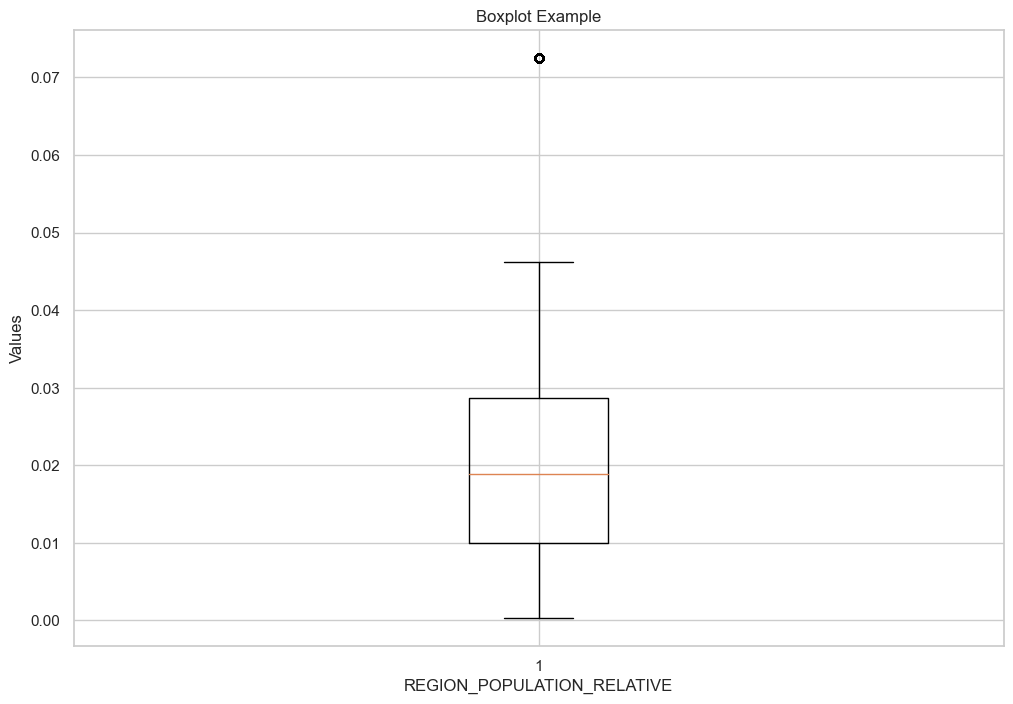

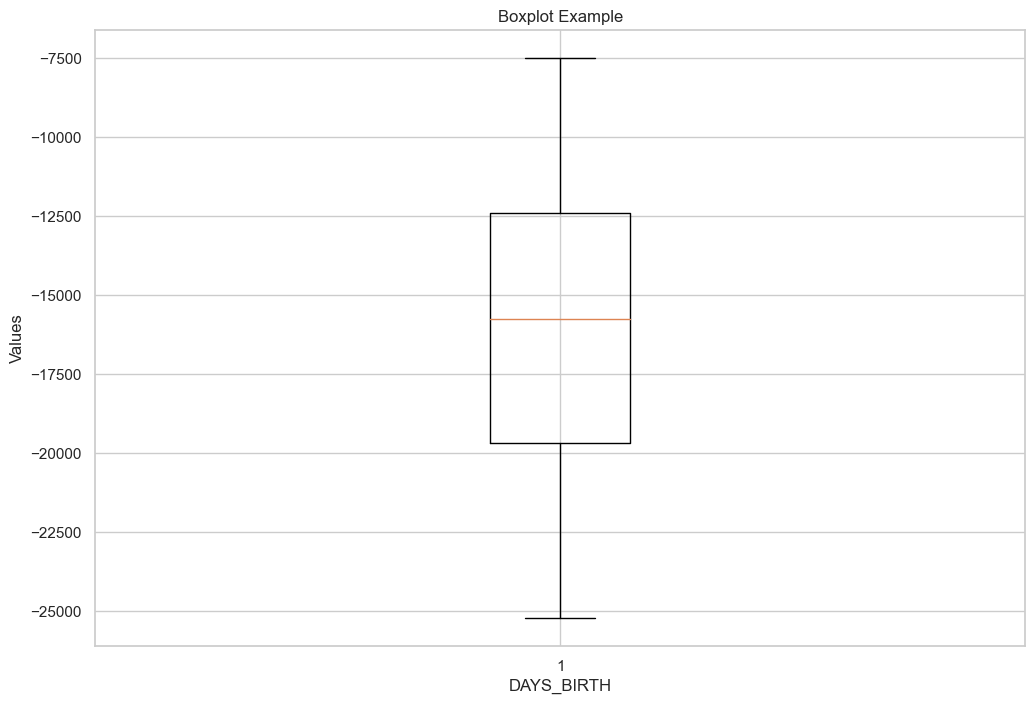

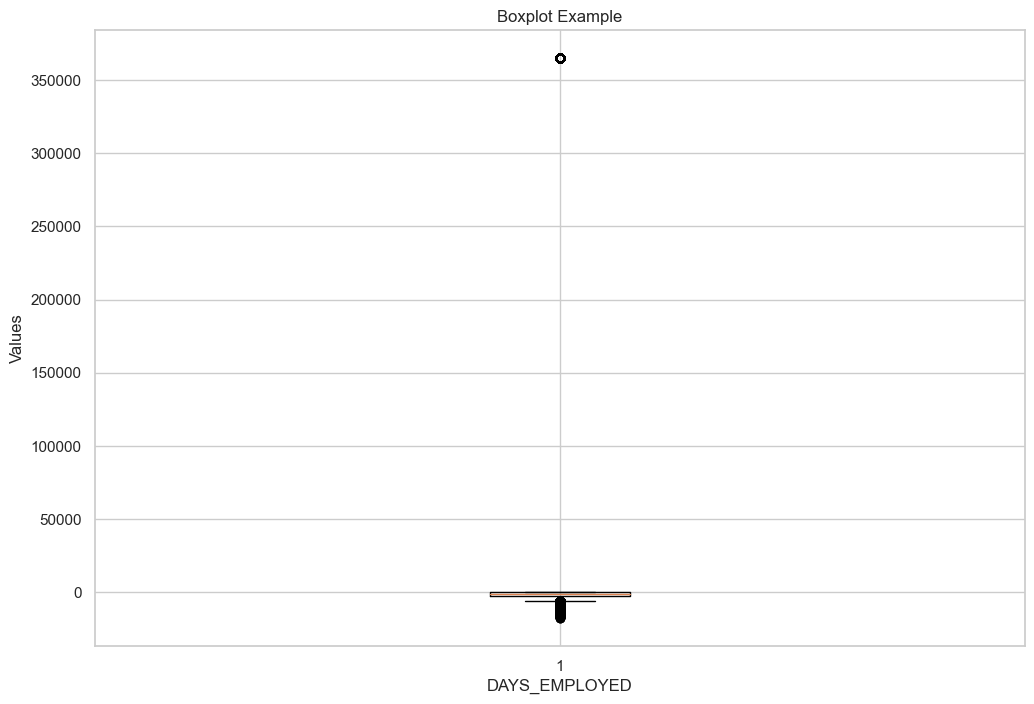

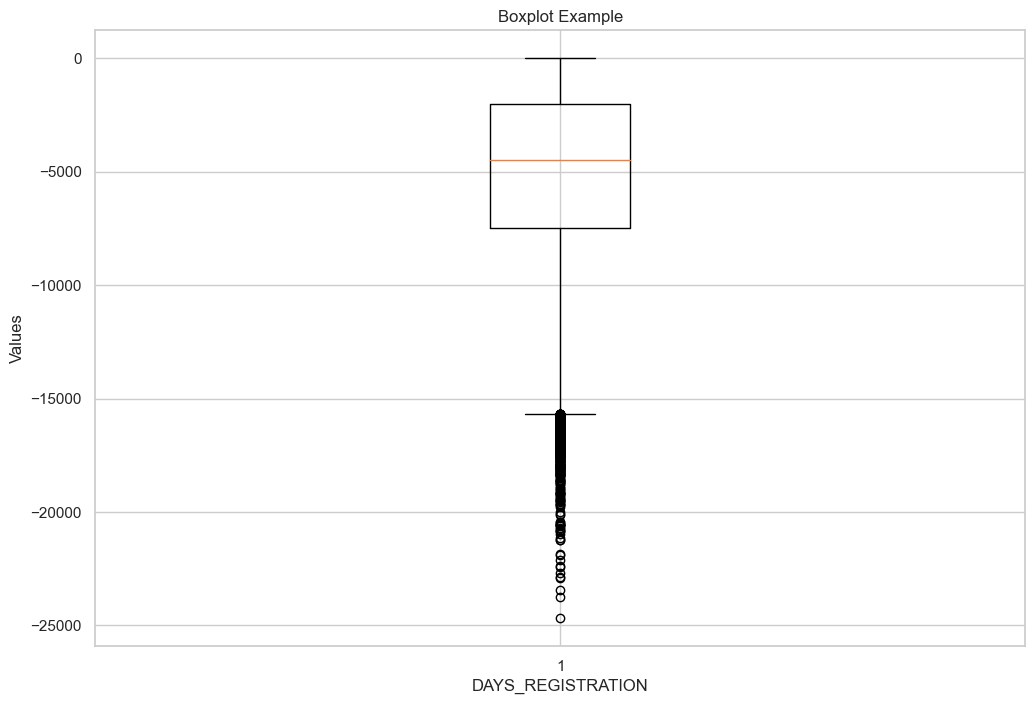

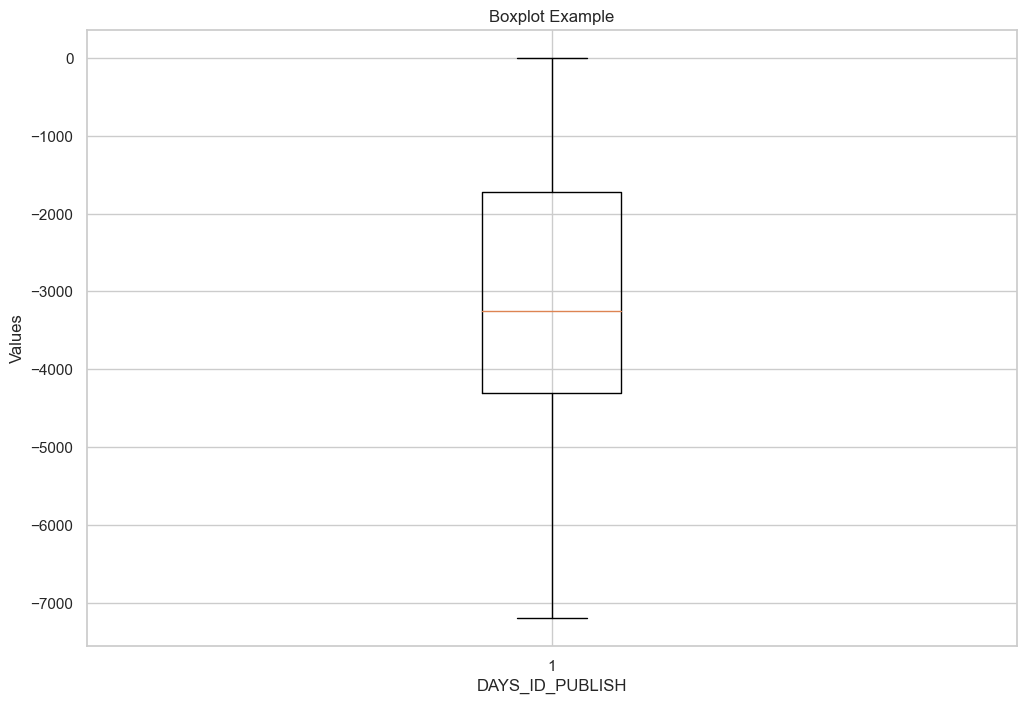

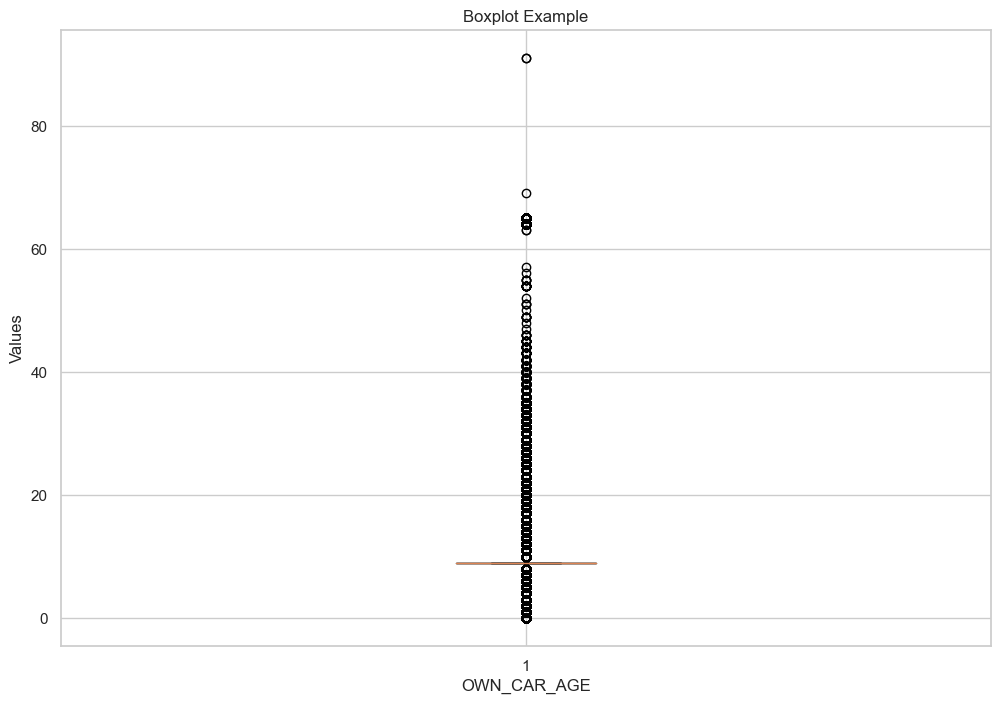

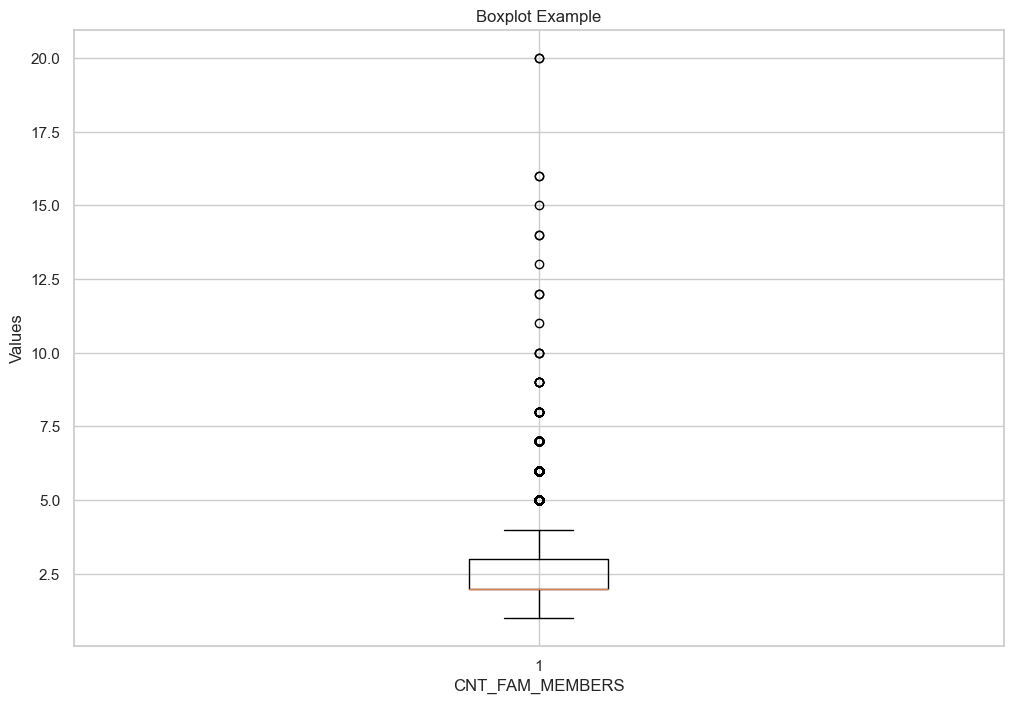

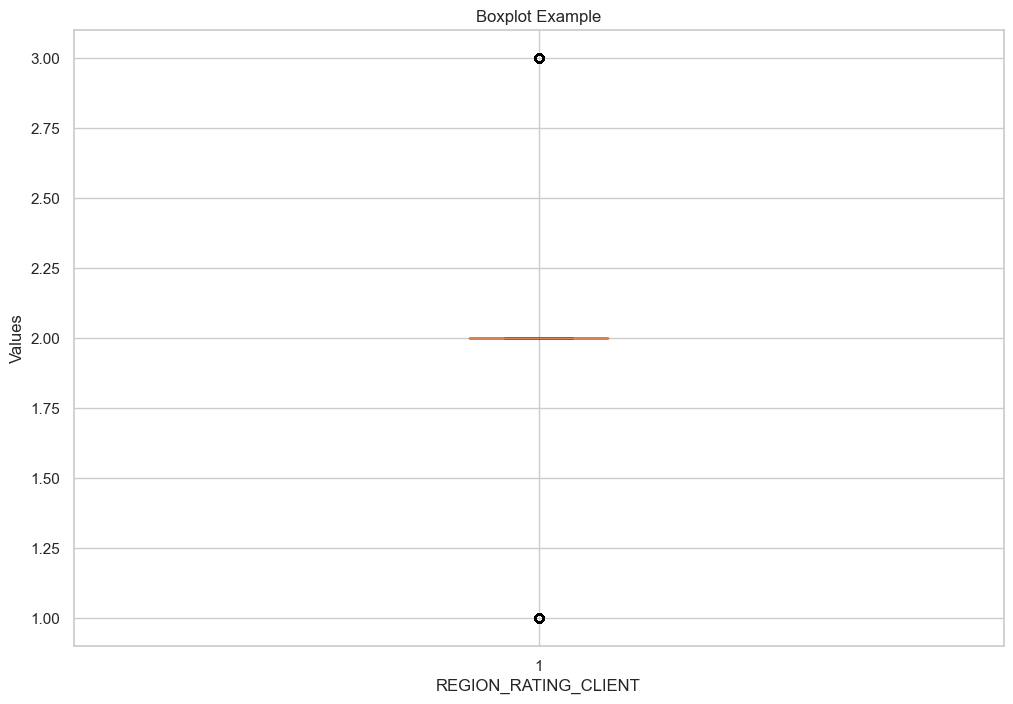

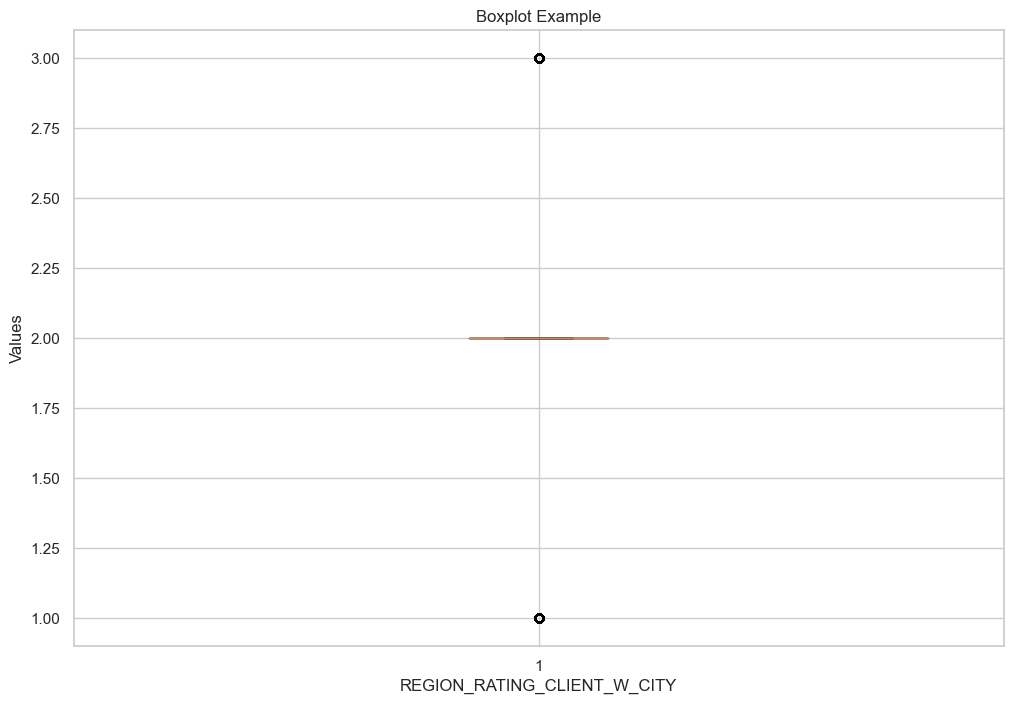

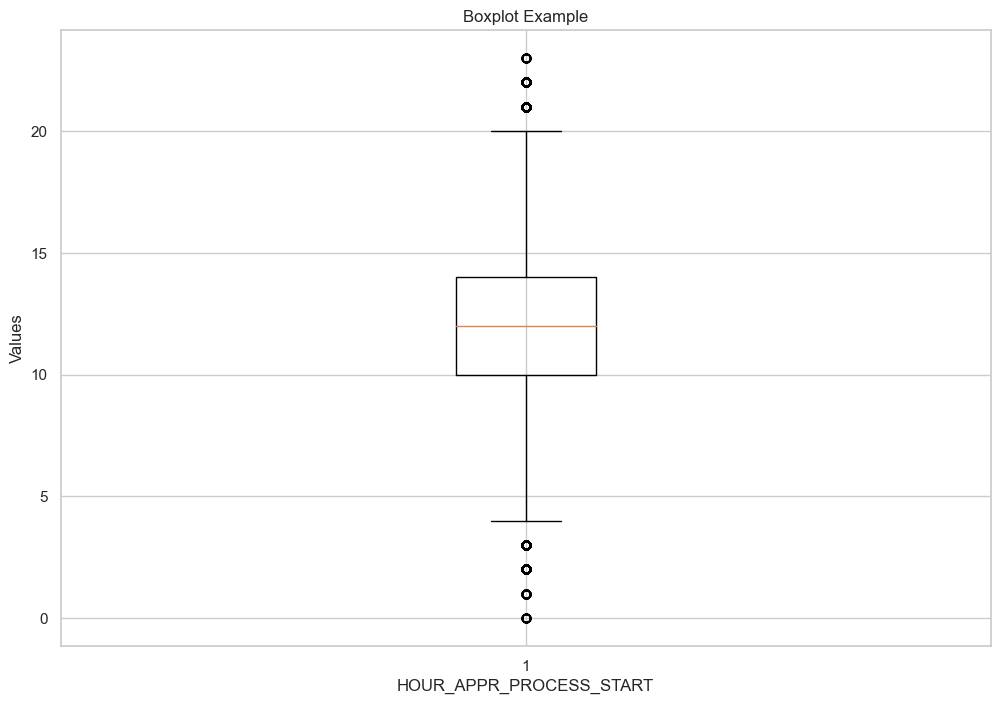

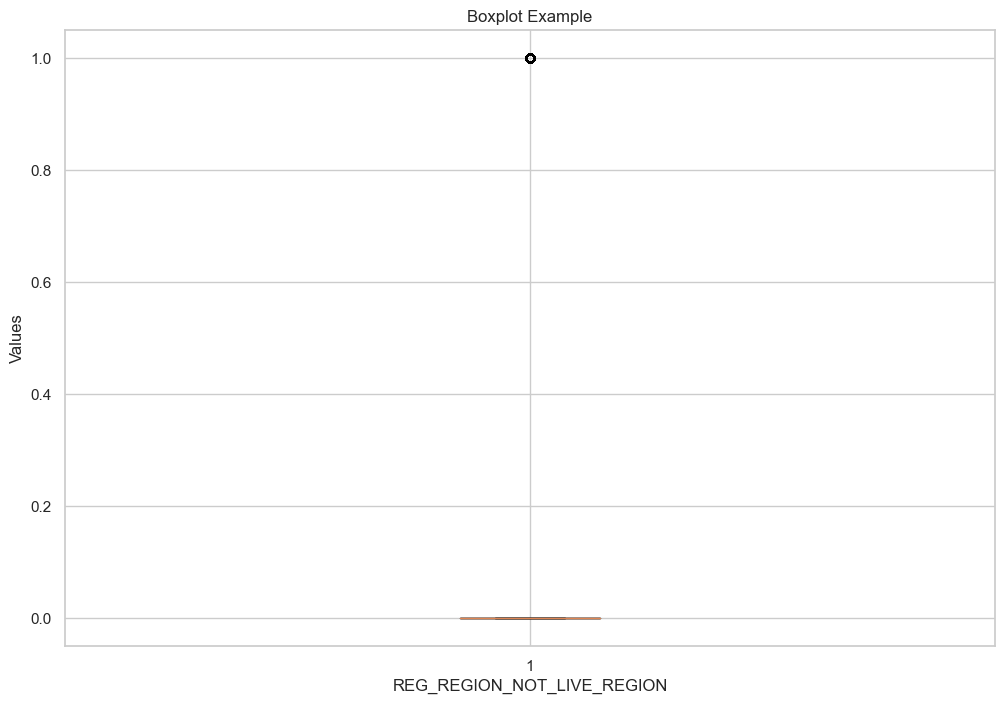

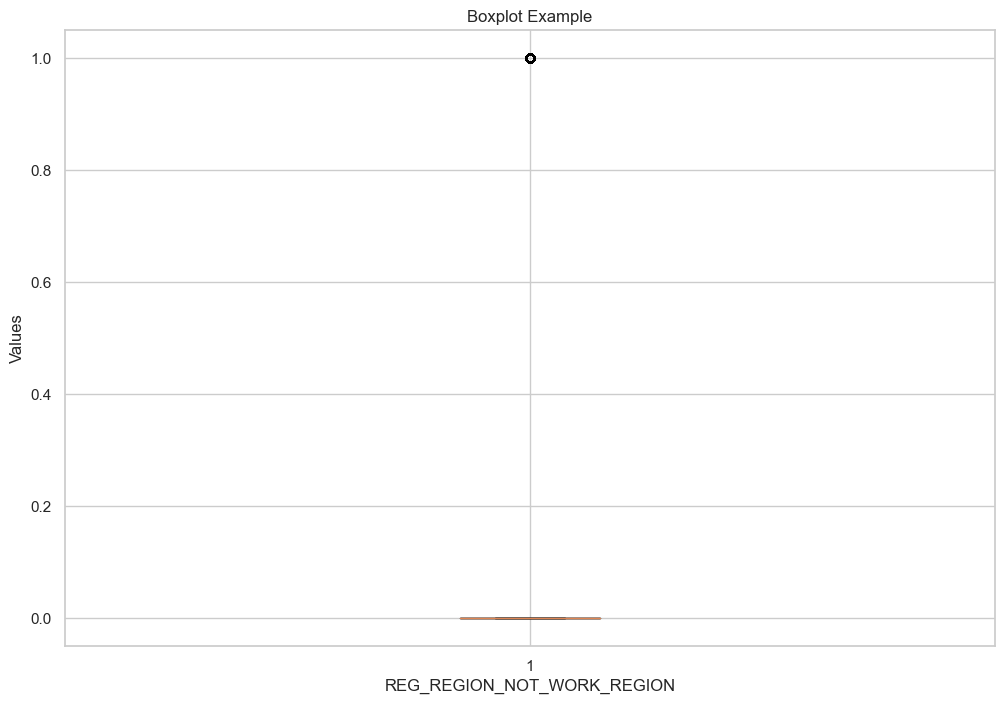

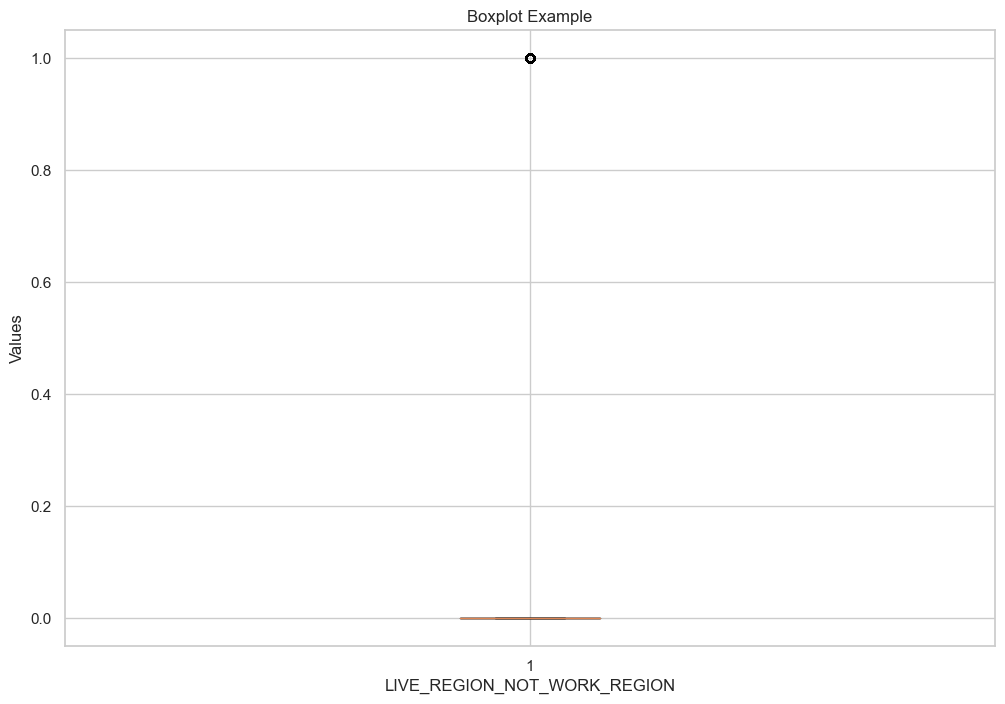

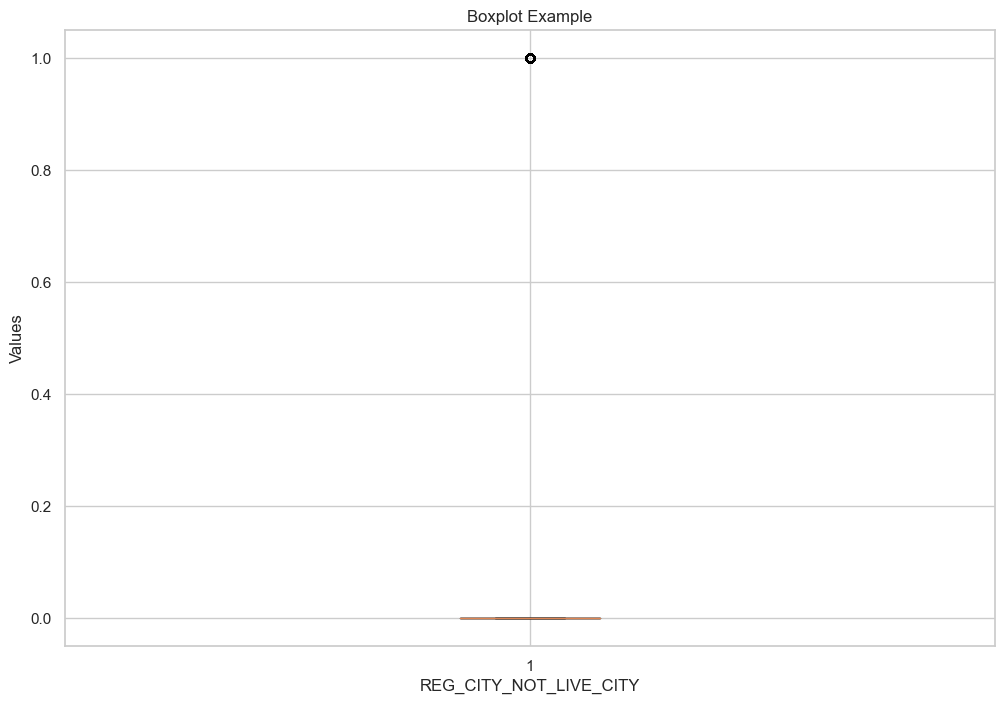

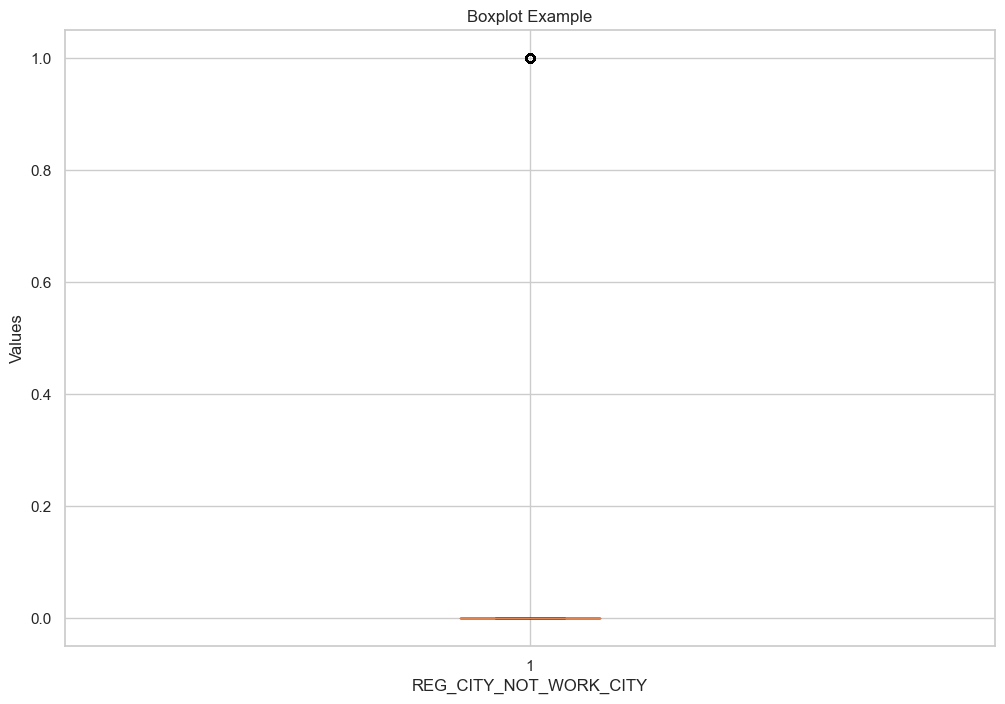

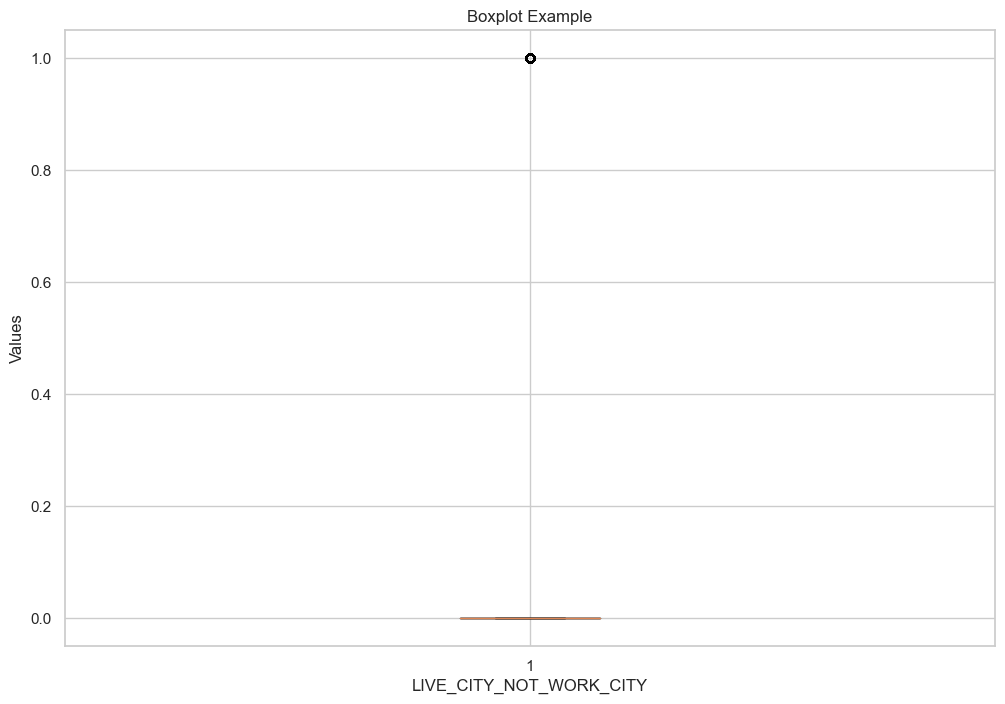

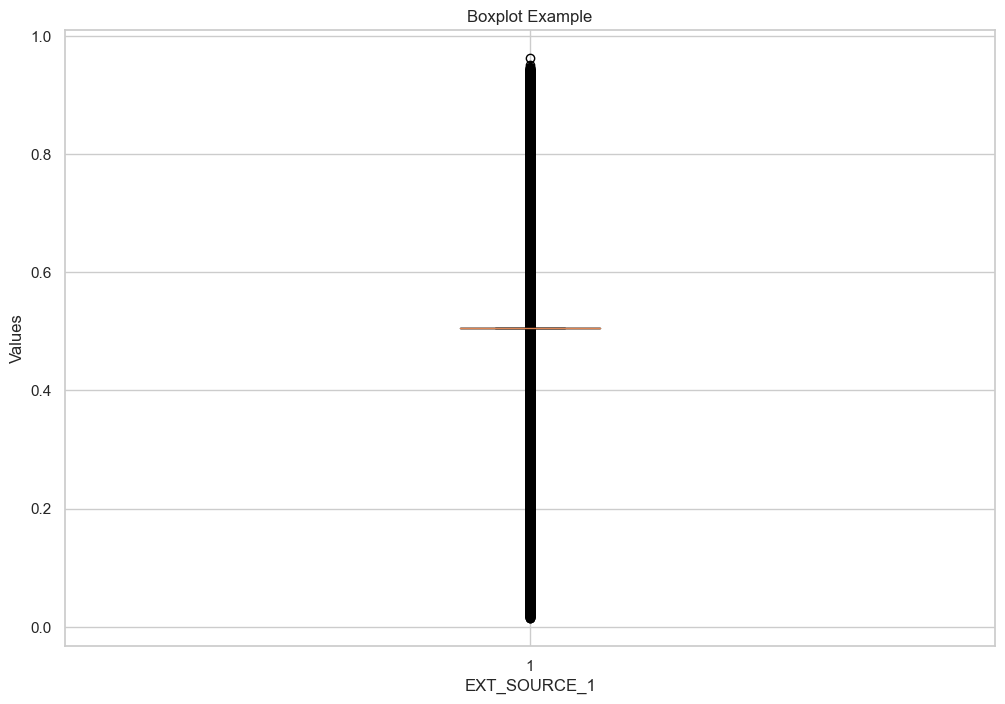

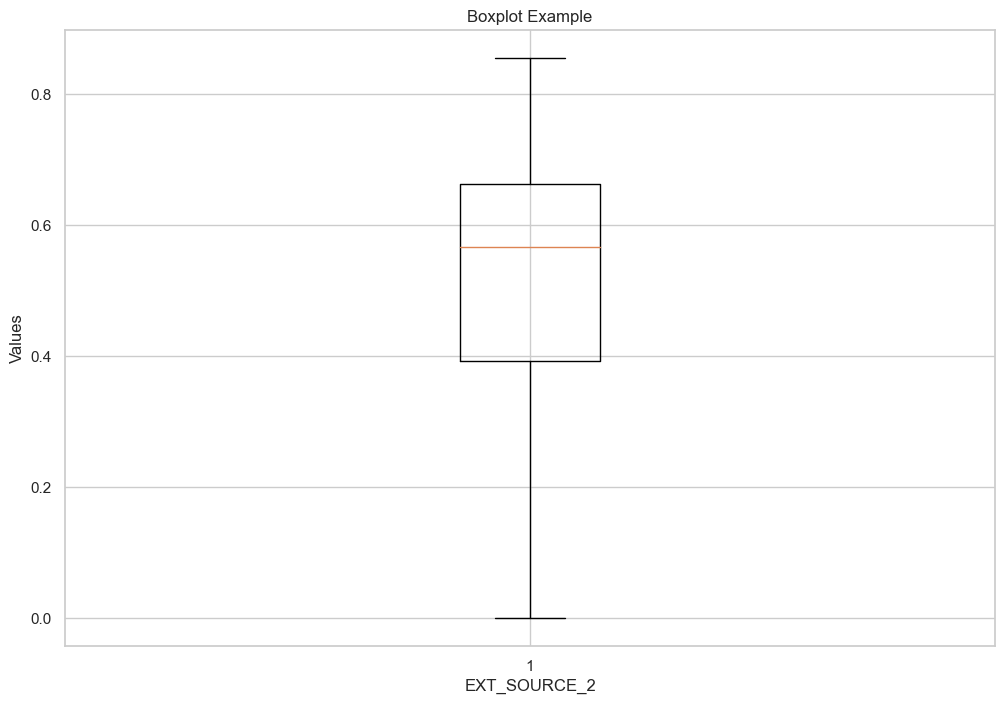

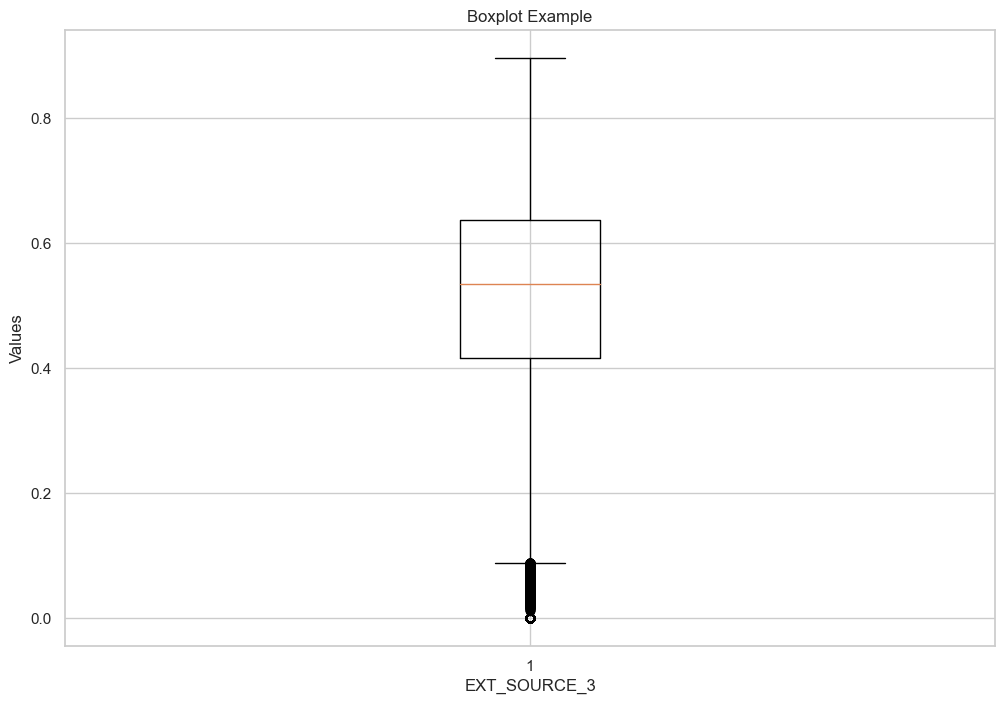

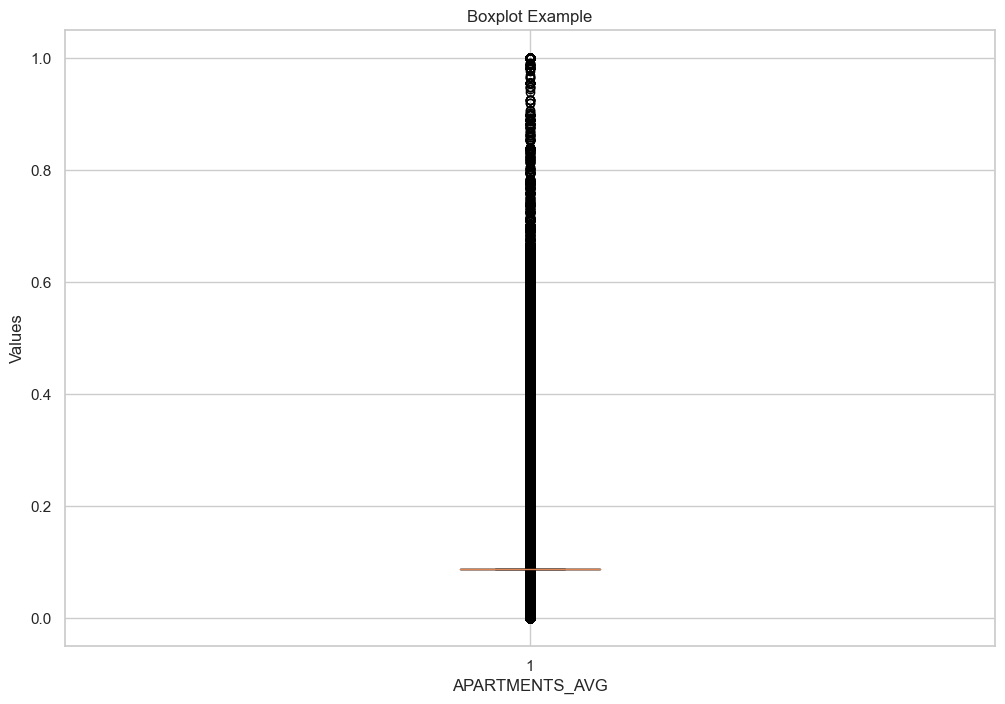

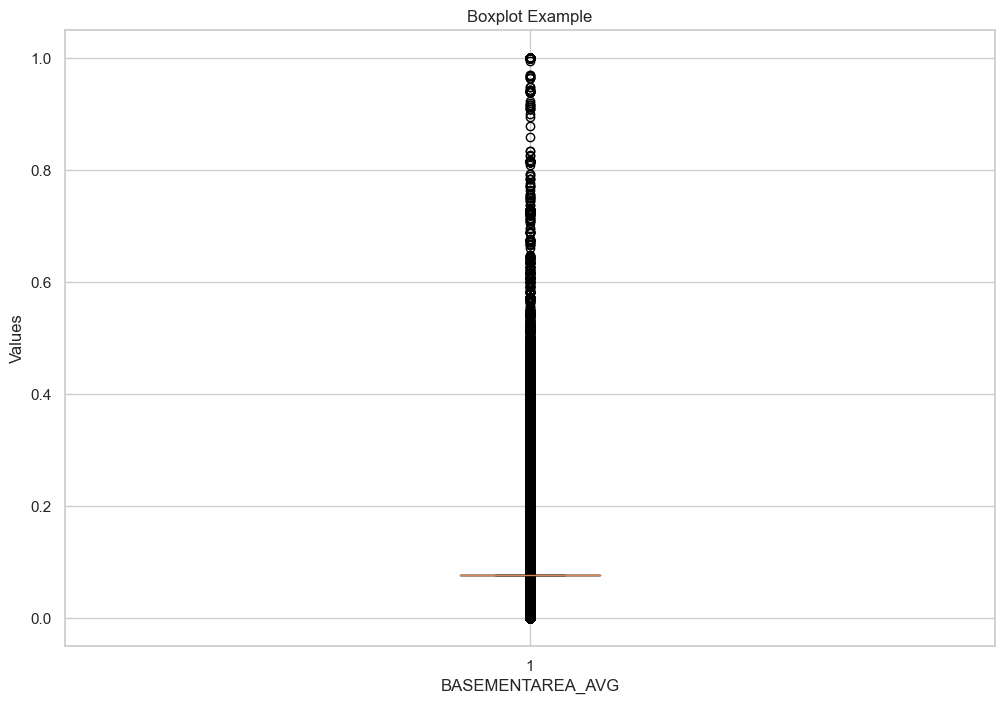

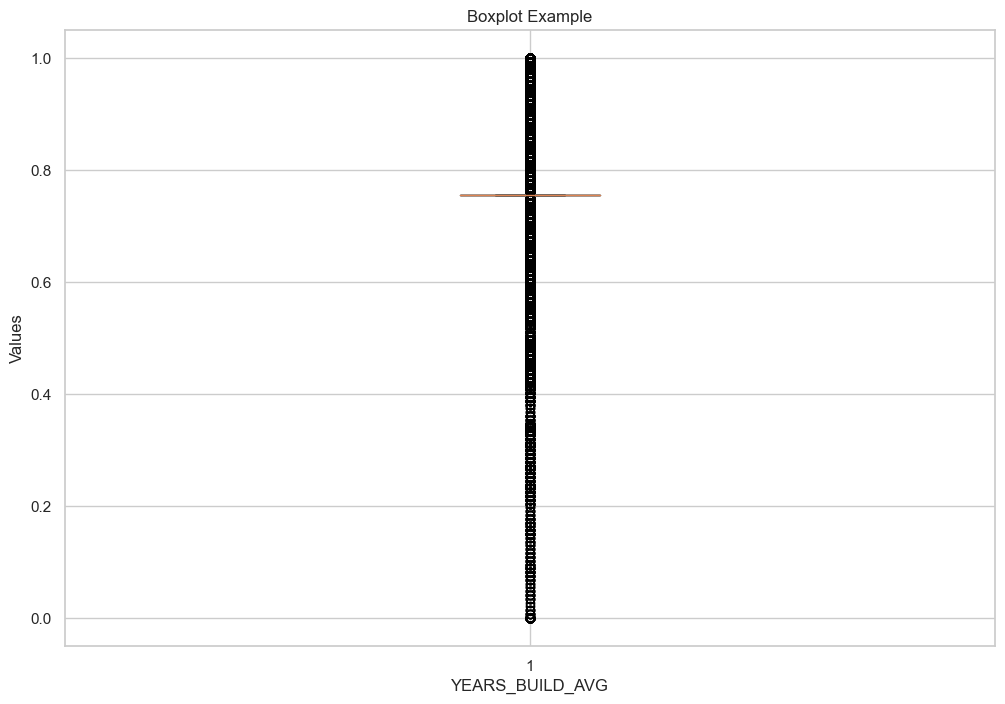

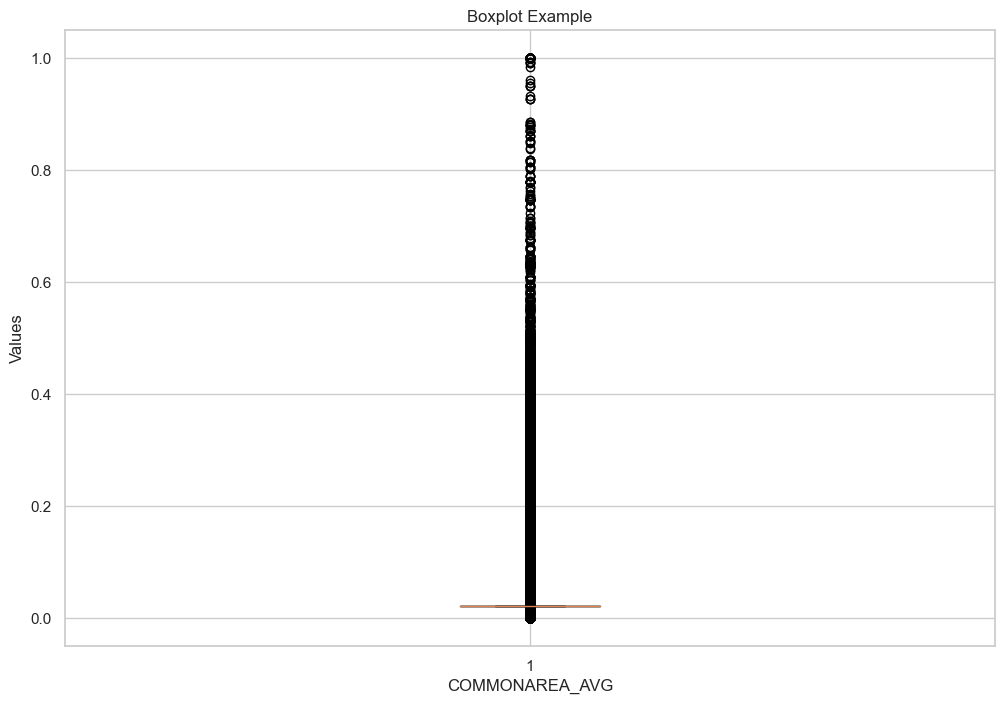

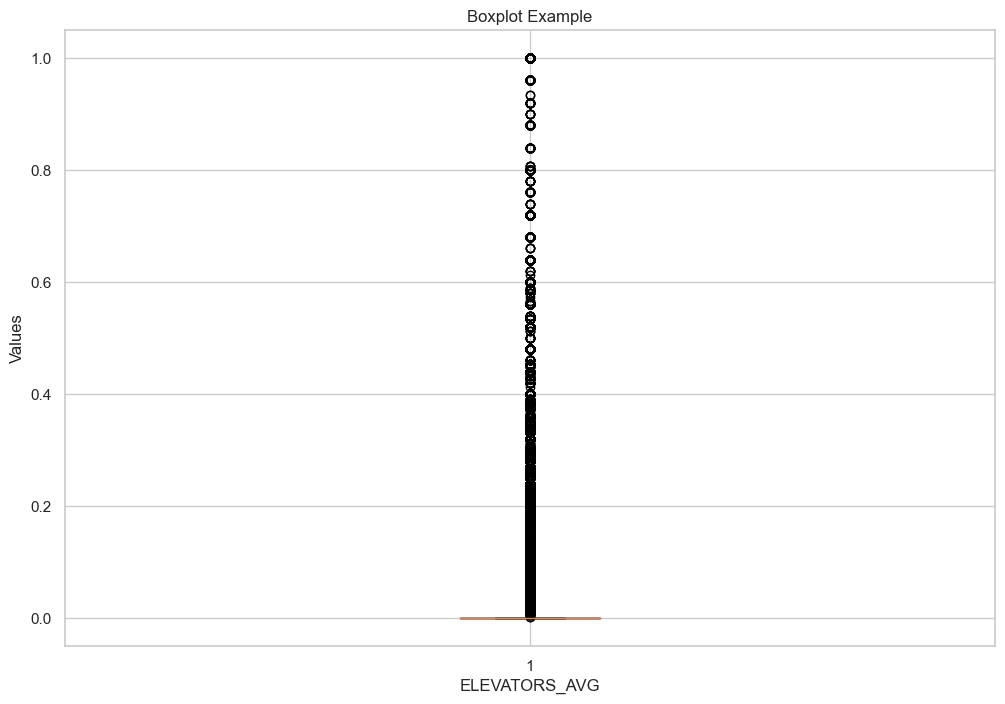

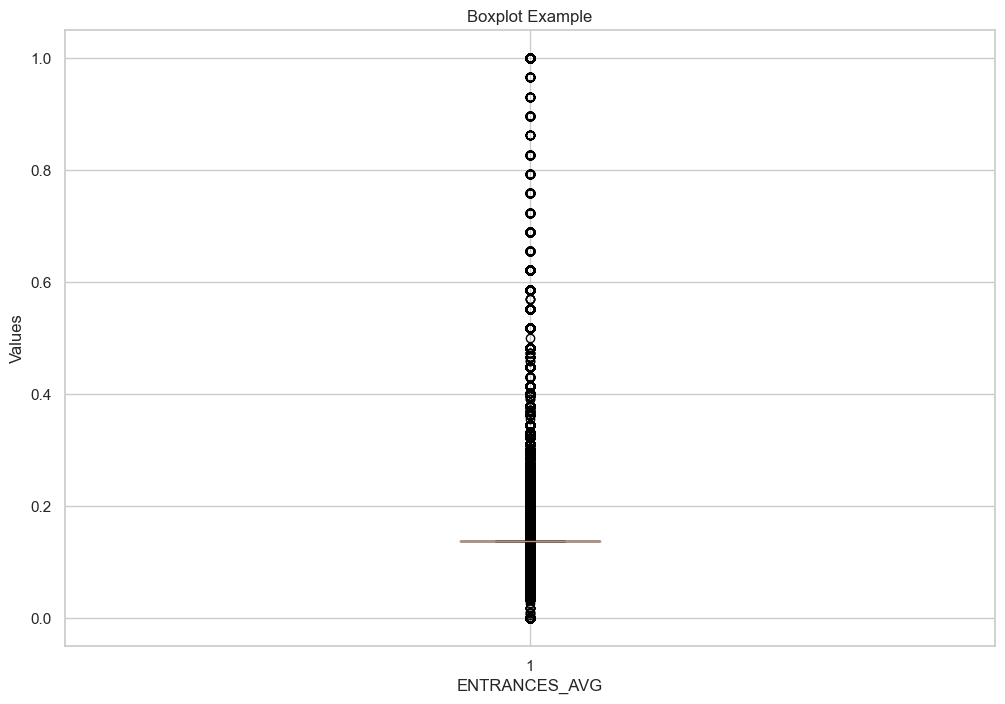

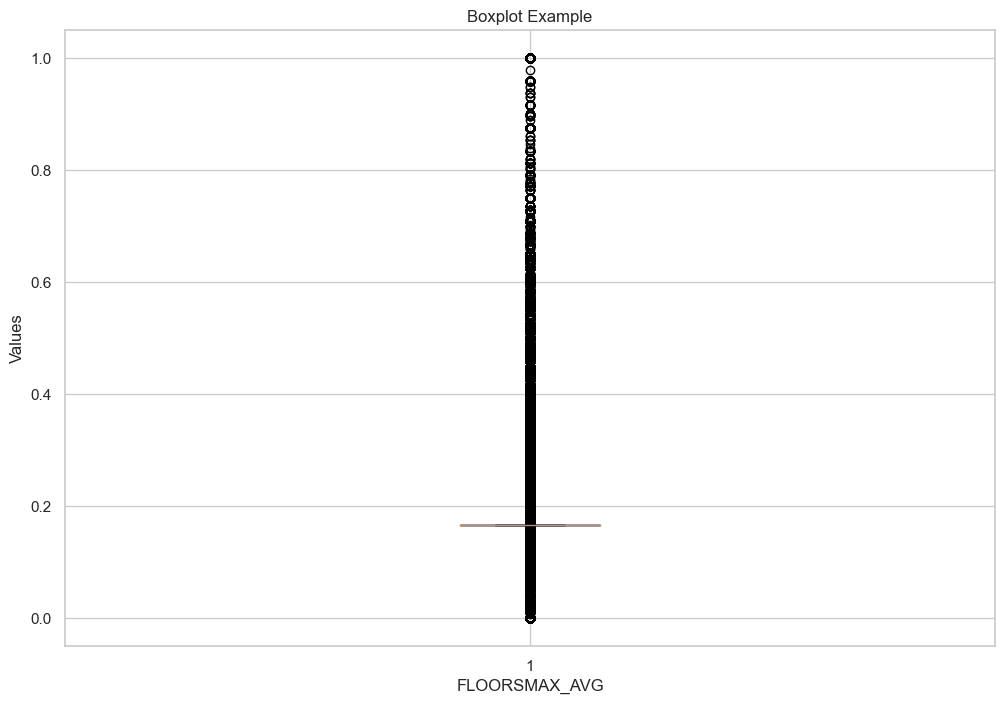

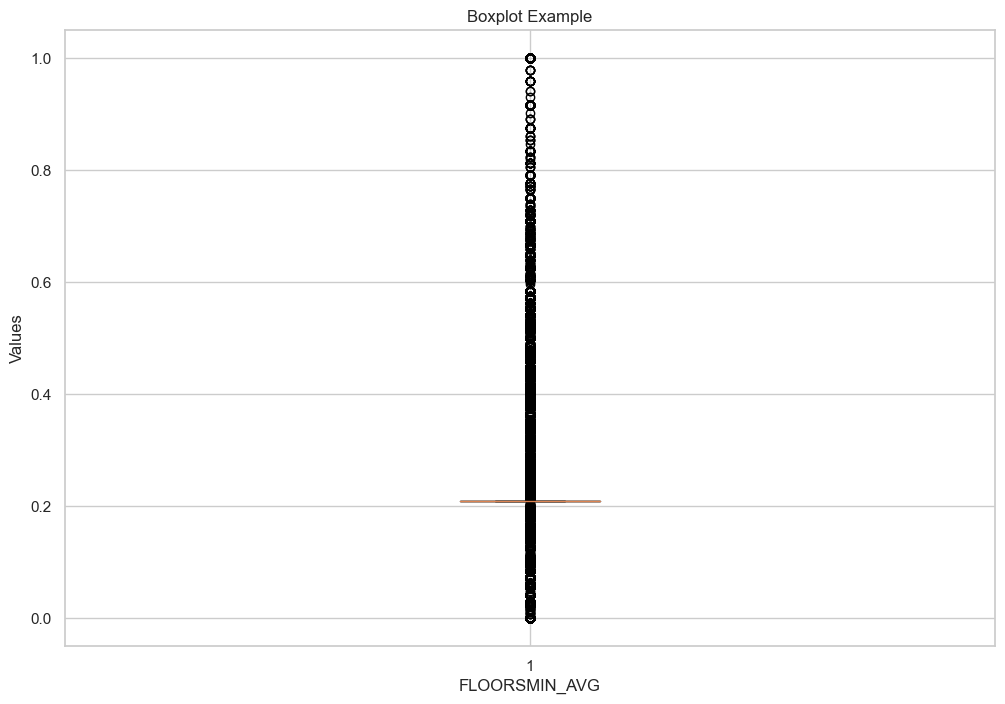

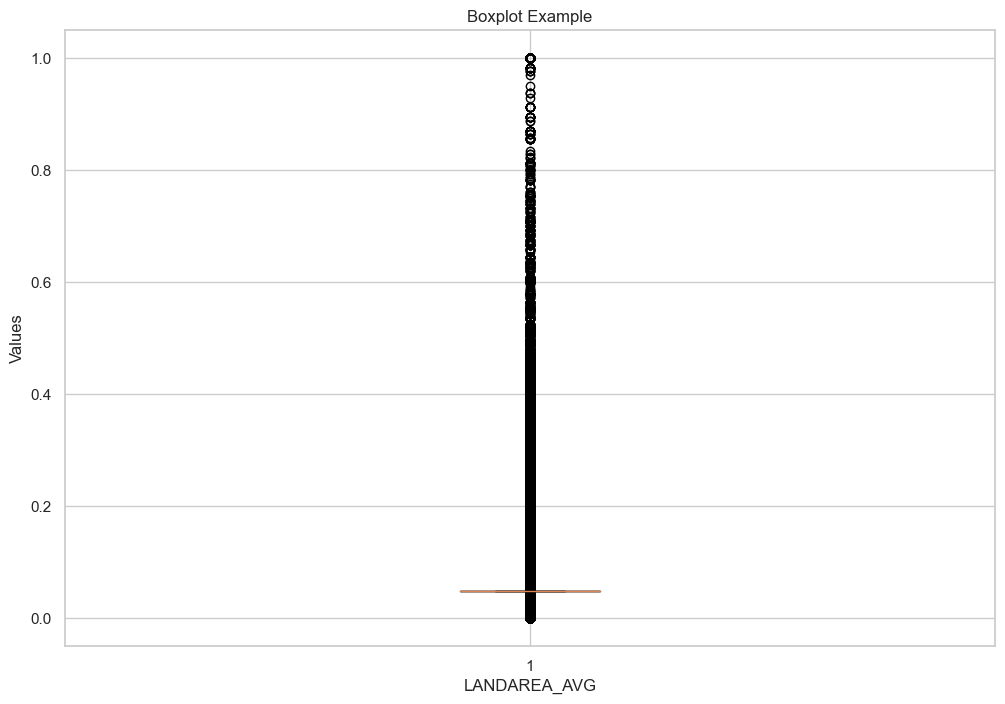

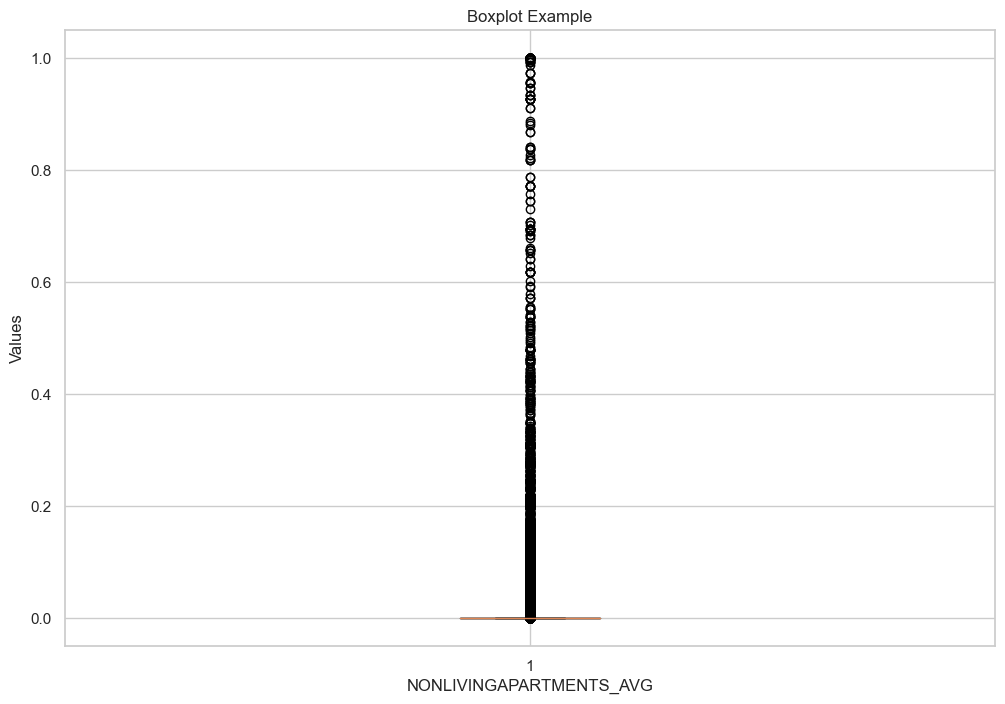

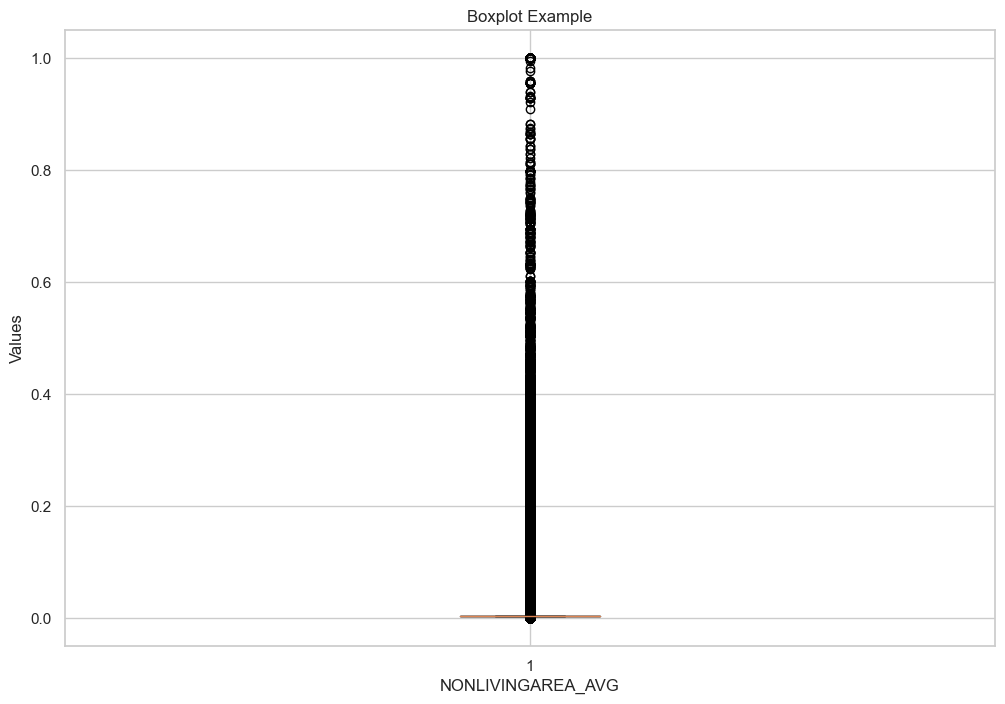

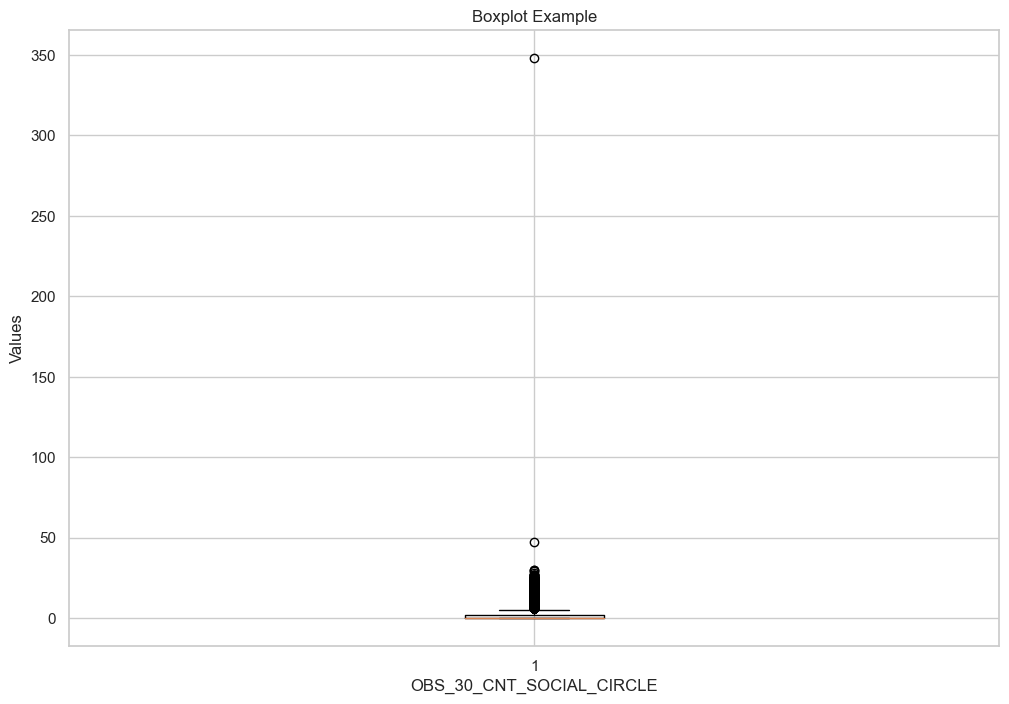

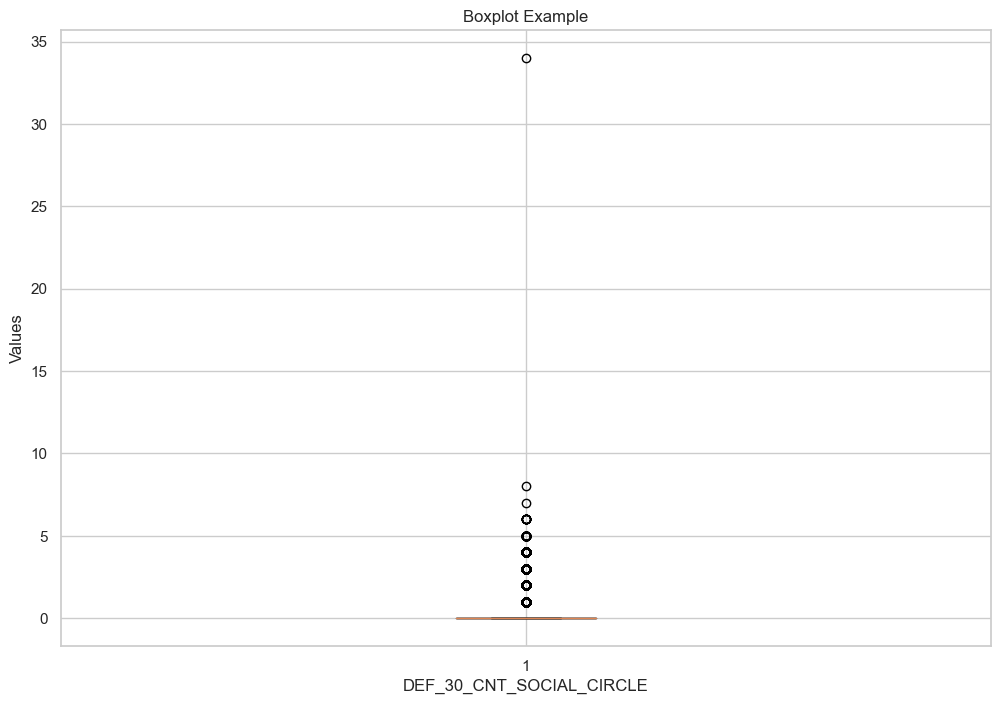

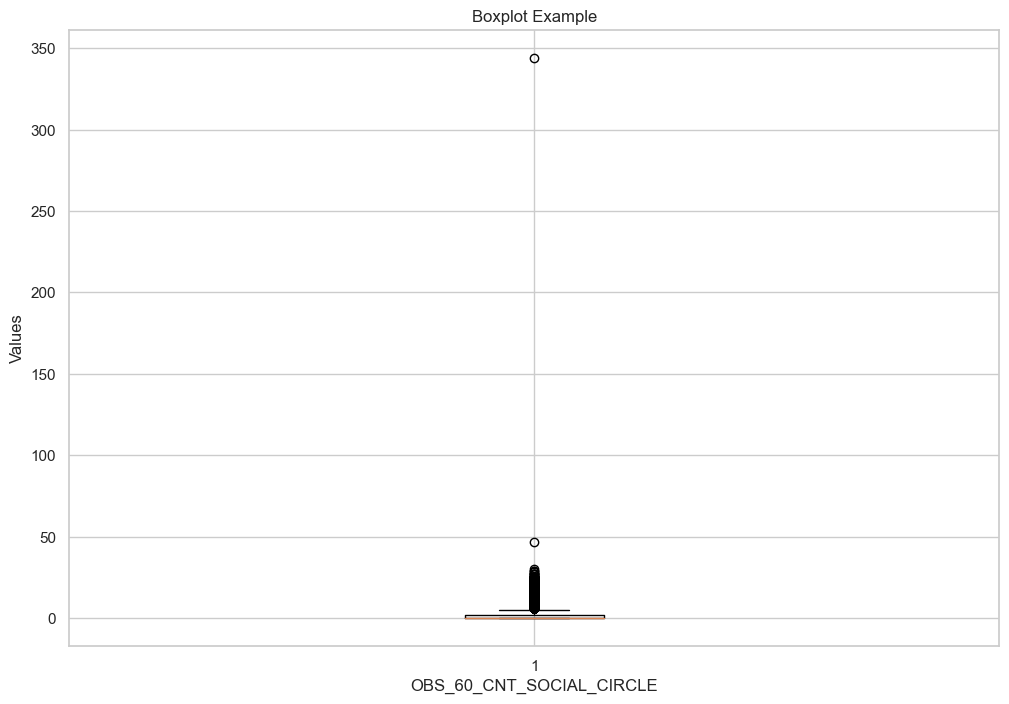

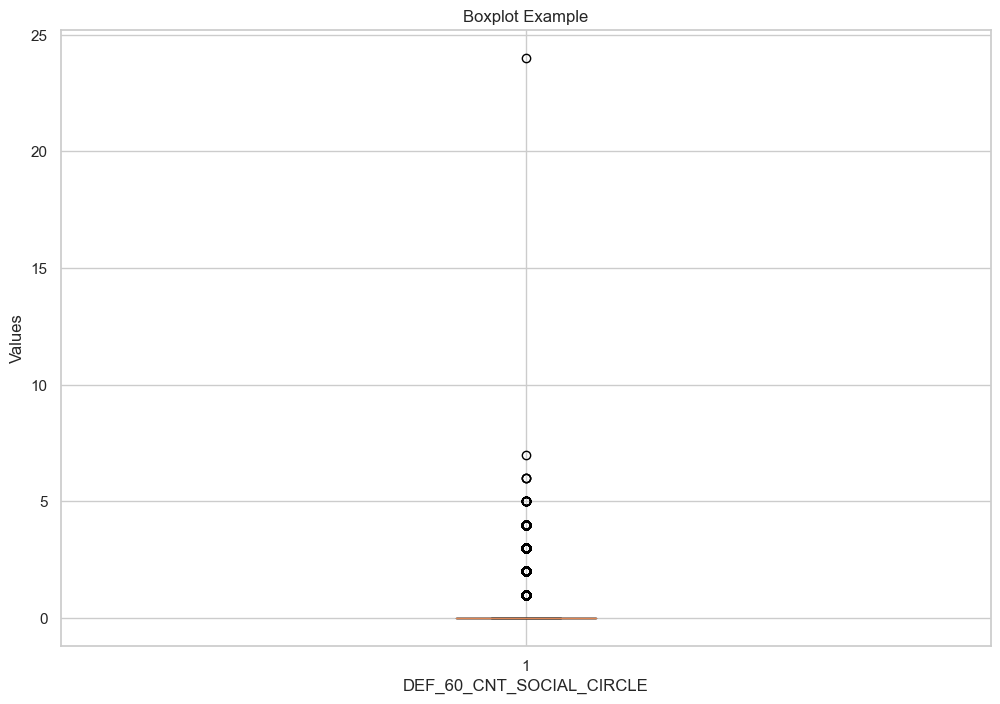

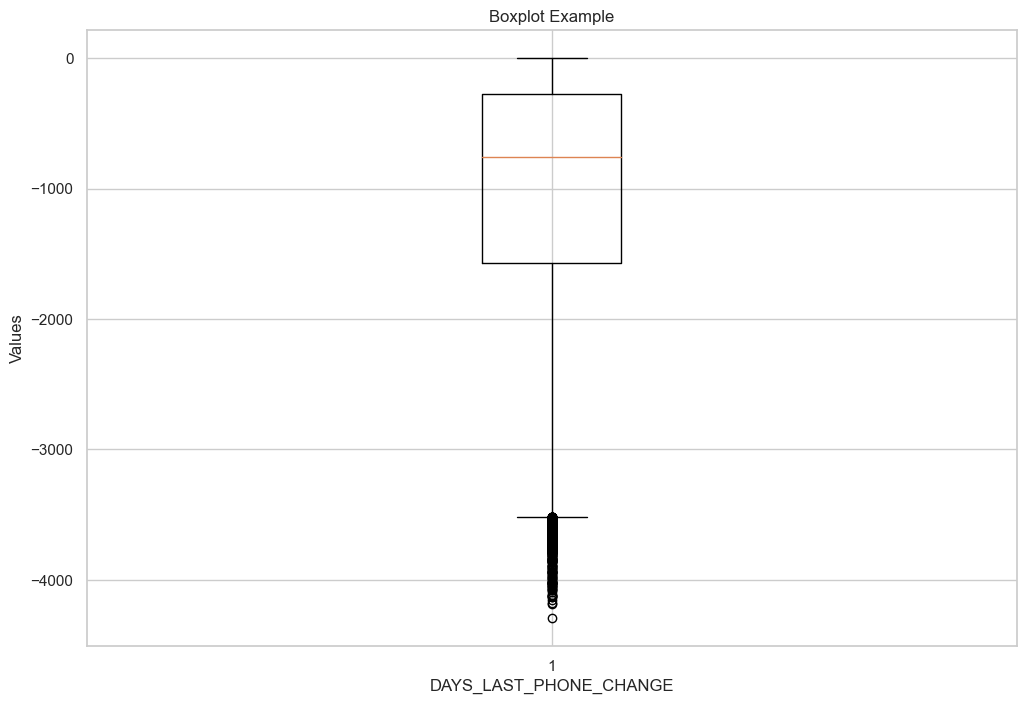

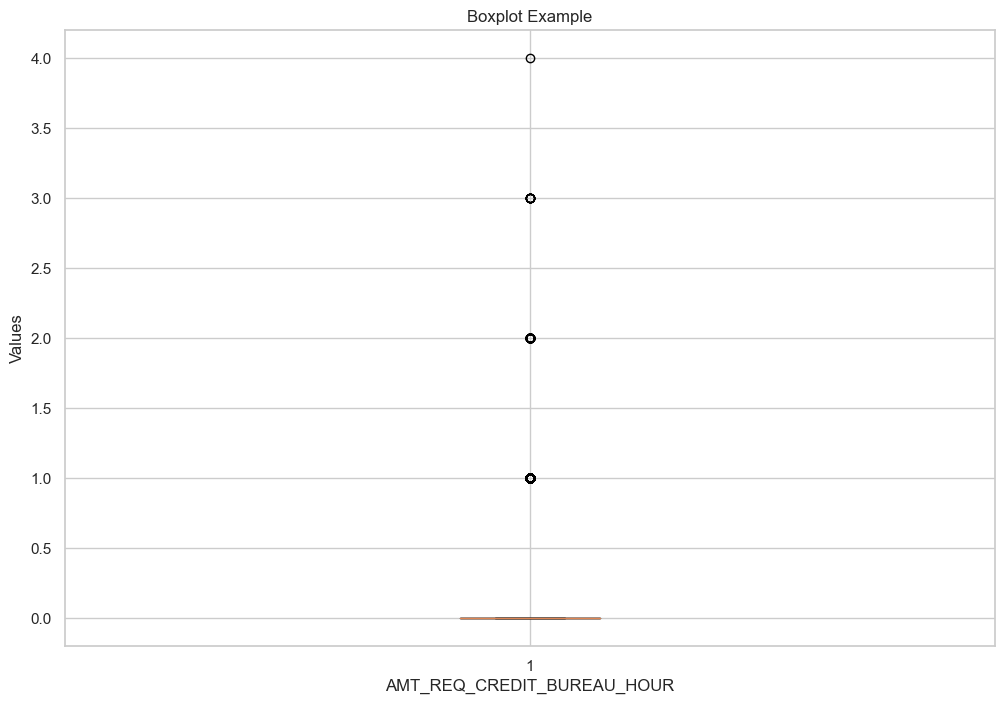

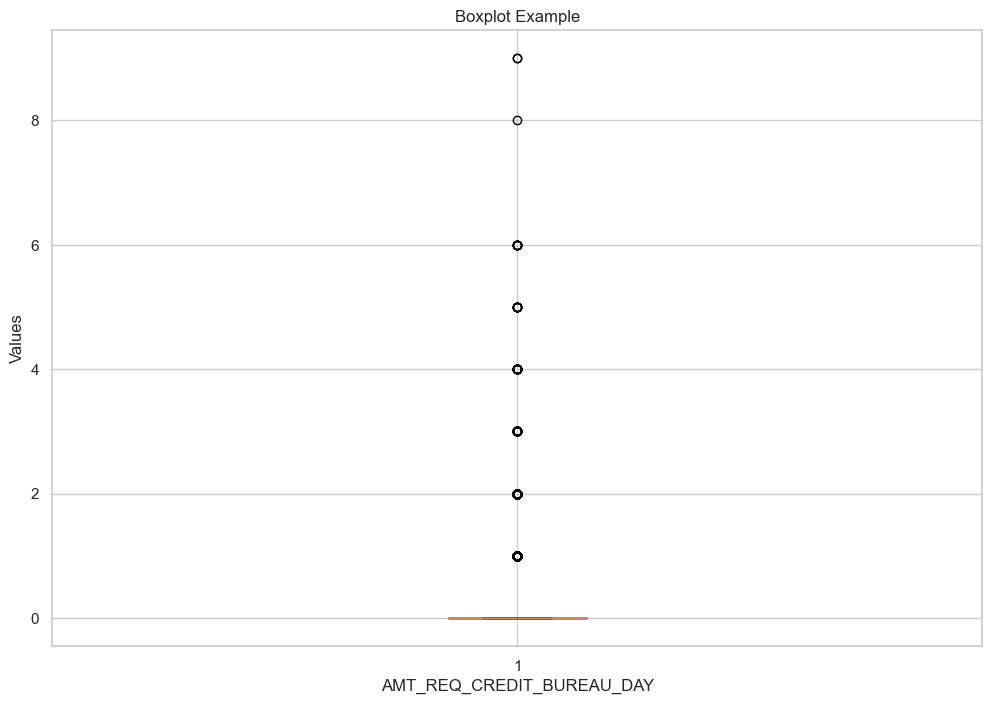

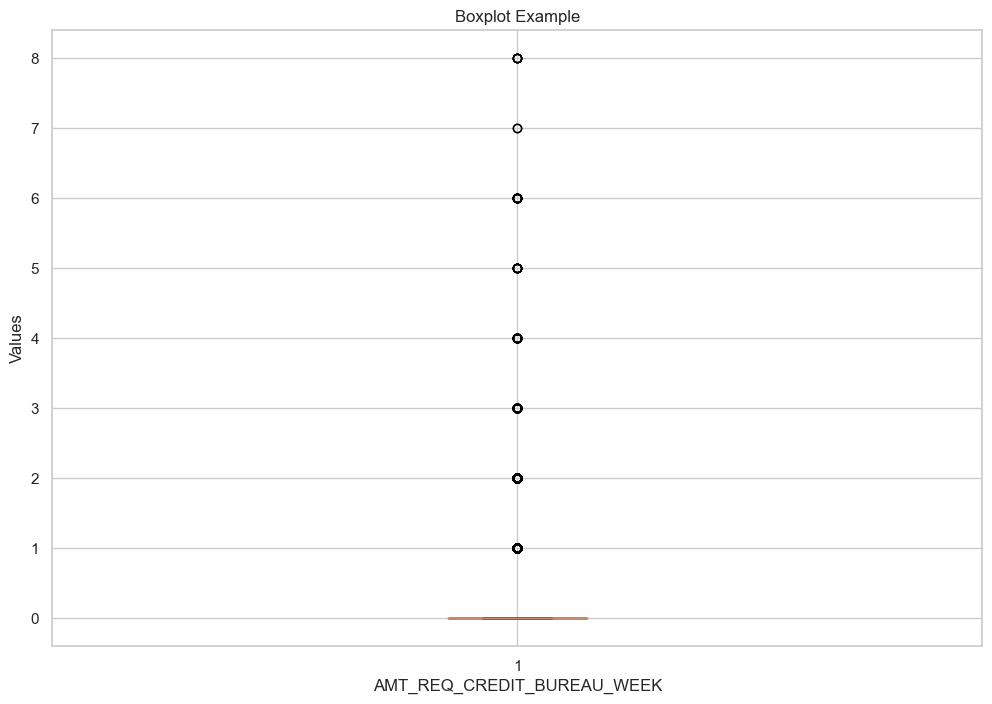

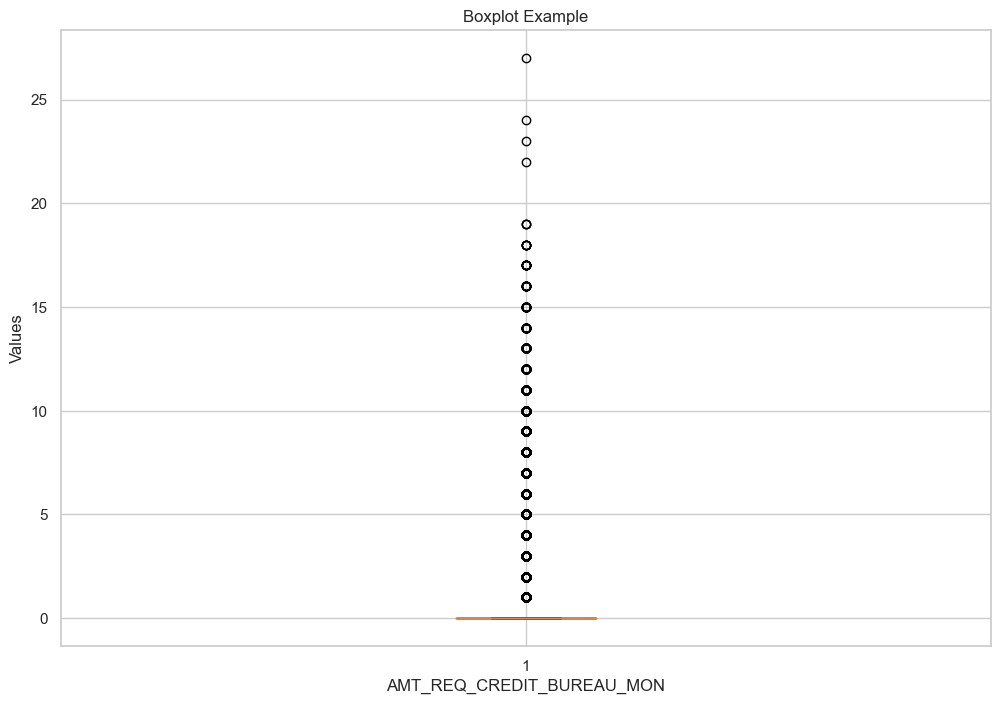

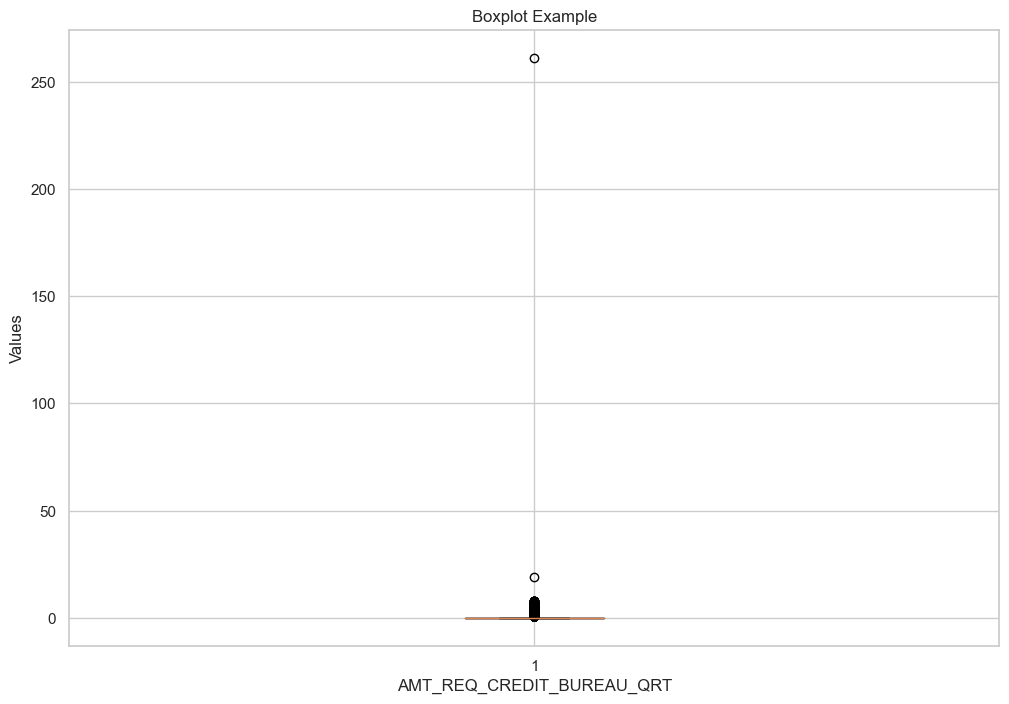

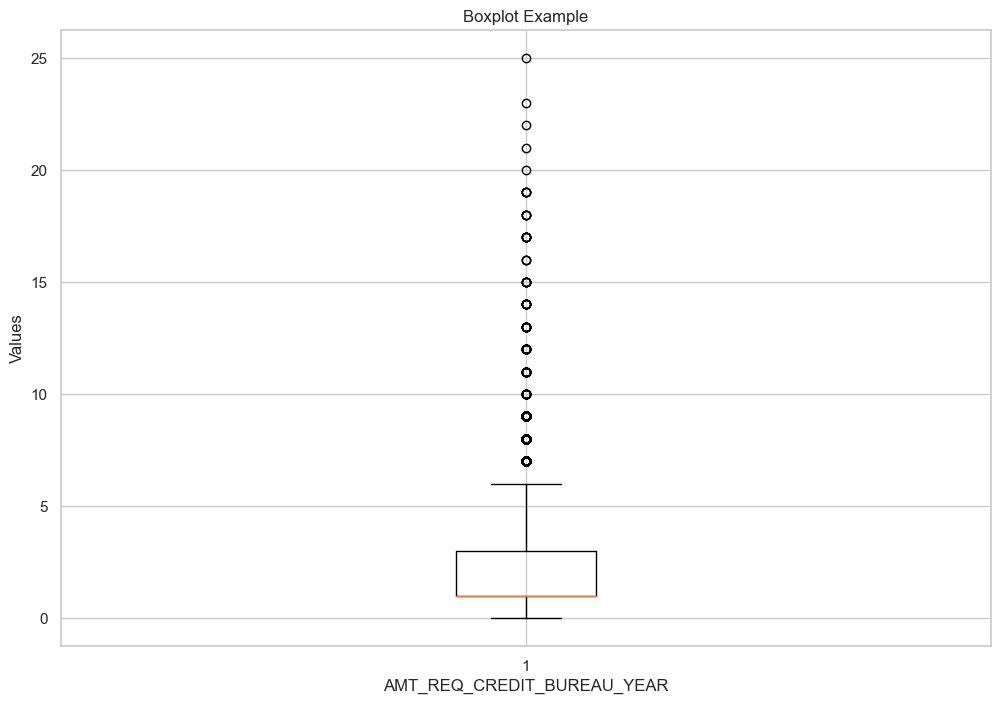

In [36]:
import matplotlib.pyplot as plt
import numpy as np

numerics_columns = df.select_dtypes(include=['int64', 'float64']).columns
numerics_df = df[numerics_columns]
for  n in numerics_df:
    # Create the figure and axis
    fig, ax = plt.subplots()

    # Create the boxplot
    ax.boxplot(df[n])

    # Set title and labels
    ax.set_title('Boxplot Example')
    ax.set_xlabel(f'{n}')
    ax.set_ylabel('Values')

    # Show the plot
    plt.show()

In [37]:
print('Numero de filas   : ', df.shape[0])  #NUMERO DE FILAS
print('Numero de columnas: ', df.shape[1])  #NUMERO DE COLUMNAS
print('\n','Nombre:', '\n', list(df.columns)) #NOMBRE DE LAS COLUMNAS

Numero de filas   :  307507
Numero de columnas:  89

 Nombre: 
 ['TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BUILD_AVG', 'CO

# 5) SELECCION DEL MODELO

In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

X = df.drop(columns= ['TARGET'])
y = df['TARGET']

In [39]:
# Ver dimensiones de X y y
print(f"X tiene {X.shape[0]} filas y {X.shape[1]} columnas.")
print(f"y tiene {y.shape[0]} filas y {y.ndim} dimensión(es).")

X tiene 307507 filas y 88 columnas.
y tiene 307507 filas y 1 dimensión(es).


In [40]:
numerics_columns = X .select_dtypes(include=['int64', 'float64']).columns
string_columns = X.select_dtypes(include=['int64', 'float64']).columns

SMOTE

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [42]:
X_train

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
210261,Cash loans,M,1,N,0,225000.0,1800000.0,62568.0,1800000.0,Unaccompanied,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0
258384,Cash loans,M,1,N,0,180000.0,1494486.0,39555.0,1305000.0,"Spouse, partner",...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
153041,Cash loans,M,0,Y,2,135000.0,755190.0,38686.5,675000.0,Family,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
159761,Cash loans,F,1,Y,2,90000.0,254700.0,17149.5,225000.0,Family,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
272275,Cash loans,F,1,N,0,247500.0,1350000.0,72058.5,1350000.0,Unaccompanied,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119882,Cash loans,F,0,Y,0,256500.0,383089.5,30397.5,346500.0,Unaccompanied,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
259182,Cash loans,F,0,Y,2,112500.0,1288350.0,37800.0,1125000.0,Unaccompanied,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
131935,Cash loans,M,0,Y,1,202500.0,327024.0,21420.0,270000.0,Unaccompanied,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
146870,Cash loans,F,1,Y,2,112500.0,1256400.0,36864.0,900000.0,Unaccompanied,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0


In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[numerics_columns] = scaler.fit_transform(X_train[numerics_columns])
X_test[numerics_columns] = scaler.transform(X_test[numerics_columns])

In [44]:
X_train[numerics_columns] 

,FLAG_OWN_CAR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
210261,1.394406,-0.577285,0.524737,2.973913,2.440520,3.405618,-0.126849,0.387961,-0.490595,0.867697,...,-0.318703,-0.166310,-0.273806,-1.051196,-0.070505,-0.058948,-0.156873,2.066193,-0.285612,-0.440256
258384,1.394406,-0.577285,0.105965,2.217063,0.856018,2.068993,1.080881,1.161194,-0.452397,0.106139,...,-0.318703,-0.581604,-0.273806,1.162548,-0.070505,-0.058948,-0.156873,-0.268657,-0.285612,-1.006779
153041,-0.717151,2.194029,-0.312807,0.385603,0.796220,0.367835,-1.013164,0.733555,-0.470292,1.193958,...,-0.318703,2.325456,-0.273806,1.164969,-0.070505,-0.058948,-0.156873,-0.268657,-0.285612,-1.006779
159761,1.394406,2.194029,-0.731580,-0.854262,-0.686656,-0.847278,-0.010208,1.102296,-0.461288,1.032389,...,-0.318703,1.494868,-0.273806,0.648146,-0.070505,-0.058948,-0.156873,-0.268657,-0.285612,0.692790
272275,1.394406,-0.577285,0.734123,1.859127,3.093964,2.190505,0.565040,-0.954080,-0.482568,0.049917,...,1.917425,0.248985,2.485327,-2.677917,-0.070505,-0.058948,-0.156873,-0.268657,-0.285612,-0.440256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119882,-0.717151,-0.577285,0.817877,-0.536203,0.225502,-0.519198,1.835432,-0.793200,2.136310,-2.161214,...,-0.318703,-0.581604,-0.273806,-2.912726,-0.070505,-0.058948,-0.156873,-0.268657,-0.285612,0.692790
259182,-0.717151,2.194029,-0.522194,1.706401,0.735182,1.582948,-0.306948,1.385784,-0.463399,0.657573,...,-0.318703,-0.166310,-0.273806,-0.200315,-0.070505,-0.058948,-0.156873,-0.268657,-0.285612,-1.006779
131935,-0.717151,0.808372,0.315351,-0.675094,-0.392621,-0.725767,-0.833571,0.935916,-0.479402,0.802956,...,-0.318703,-0.581604,-0.273806,-0.222101,-0.070505,-0.058948,-0.156873,-0.268657,-0.285612,-0.440256
146870,1.394406,2.194029,-0.522194,1.627252,0.670736,0.975391,-0.204417,0.860976,-0.467720,1.338205,...,-0.318703,1.494868,-0.273806,-1.089927,-0.070505,-0.058948,-0.156873,-0.268657,-0.285612,-0.440256


In [45]:
from sklearn.preprocessing import LabelEncoder

string_columns = X.select_dtypes(include=['object']).columns

label_encoder = LabelEncoder()

for col in string_columns:
    X_train[col] = label_encoder.fit_transform(X_train[col])
    X_test[col] = label_encoder.transform(X_test[col])

SEX  F , M 
SEX  1 ,0
 


In [46]:
X_train[string_columns]

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_EMP_PHONE,...,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21
210261,0,1,0,6,7,2,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
258384,0,1,0,5,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,0
153041,0,1,1,1,7,4,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
159761,0,0,1,1,7,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
272275,0,0,0,6,7,4,2,1,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119882,0,0,1,6,3,4,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
259182,0,0,1,6,7,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
131935,0,1,1,6,7,4,2,1,1,1,...,0,0,0,0,0,0,0,0,0,0
146870,0,0,1,6,7,4,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [47]:
from imblearn.over_sampling import SMOTE

# Aplicar SMOTE al conjunto de entrenamiento para balancear las clases
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


probamos diferentes tipos de modeos para nuestro para nuestro dataset para ver cual es el que mejores resultados da

In [48]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

max_iter=1000



# 5. Definir y entrenar los modelos
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC" :SVC(max_iter=max_iter),
    "KNN":KNeighborsClassifier()
}

# 6. Evaluar los modelos
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_smote, y_train_smote)  # Entrenar el modelo
    y_pred = model.predict(X_test)  # Predecir en el conjunto de prueba

    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Mostrar resultados
    print(f"Results for {name}:")
    print(f"  Accuracy: {accuracy:.2f}")
    print(f"  Precision: {precision:.2f}")
    print(f"  Recall: {recall:.2f}")
    print(f"  F1-Score: {f1:.2f}")
    print("  Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("  Classification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

Training Logistic Regression...


/Users/juanmartin/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Results for Logistic Regression:
  Accuracy: 0.76
  Precision: 0.15
  Recall: 0.43
  F1-Score: 0.22
  Confusion Matrix:
[[66750 18061]
 [ 4228  3214]]
  Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.79      0.86     84811
           1       0.15      0.43      0.22      7442

    accuracy                           0.76     92253
   macro avg       0.55      0.61      0.54     92253
weighted avg       0.88      0.76      0.81     92253

--------------------------------------------------
Training Decision Tree...
Results for Decision Tree:
  Accuracy: 0.82
  Precision: 0.12
  Recall: 0.20
  F1-Score: 0.15
  Confusion Matrix:
[[73955 10856]
 [ 5949  1493]]
  Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90     84811
           1       0.12      0.20      0.15      7442

    accuracy                           0.82     92253
   macro avg       0.52      0.5

/Users/juanmartin/anaconda3/lib/python3.10/site-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Results for SVC:
  Accuracy: 0.41
  Precision: 0.08
  Recall: 0.55
  F1-Score: 0.13
  Confusion Matrix:
[[34176 50635]
 [ 3335  4107]]
  Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.40      0.56     84811
           1       0.08      0.55      0.13      7442

    accuracy                           0.41     92253
   macro avg       0.49      0.48      0.35     92253
weighted avg       0.84      0.41      0.52     92253

--------------------------------------------------
Training KNN...
Results for KNN:
  Accuracy: 0.61
  Precision: 0.11
  Recall: 0.52
  F1-Score: 0.18
  Confusion Matrix:
[[52305 32506]
 [ 3580  3862]]
  Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.62      0.74     84811
           1       0.11      0.52      0.18      7442

    accuracy                           0.61     92253
   macro avg       0.52      0.57      0.46     92253
weighted avg  

BORDERLINE-SMOTE

In [56]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.neighbors import KNeighborsClassifier




# Aplicar SMOTE al conjunto de entrenamiento para balancear las clases
borderline_smote = BorderlineSMOTE(kind='borderline-1', random_state=42) 
X_train_bsmote, y_train_bsmote, = borderline_smote.fit_resample(X_train, y_train)

# 5. Definir y entrenar los modelos
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC" :SVC(max_iter=max_iter),
    "KNN":KNeighborsClassifier()
}

# 6. Evaluar los modelos
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_bsmote, y_train_bsmote)  # Entrenar el modelo
    y_pred = model.predict(X_test)  # Predecir en el conjunto de prueba

    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Mostrar resultados
    print(f"Results for {name}:")
    print(f"  Accuracy: {accuracy:.2f}")
    print(f"  Precision: {precision:.2f}")
    print(f"  Recall: {recall:.2f}")
    print(f"  F1-Score: {f1:.2f}")
    print("  Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("  Classification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

Training Logistic Regression...


/Users/juanmartin/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Results for Logistic Regression:
  Accuracy: 0.77
  Precision: 0.16
  Recall: 0.43
  F1-Score: 0.23
  Confusion Matrix:
[[68017 16794]
 [ 4258  3184]]
  Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.80      0.87     84811
           1       0.16      0.43      0.23      7442

    accuracy                           0.77     92253
   macro avg       0.55      0.61      0.55     92253
weighted avg       0.88      0.77      0.81     92253

--------------------------------------------------
Training Decision Tree...
Results for Decision Tree:
  Accuracy: 0.82
  Precision: 0.12
  Recall: 0.20
  F1-Score: 0.15
  Confusion Matrix:
[[74009 10802]
 [ 5942  1500]]
  Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90     84811
           1       0.12      0.20      0.15      7442

    accuracy                           0.82     92253
   macro avg       0.52      0.5

/Users/juanmartin/anaconda3/lib/python3.10/site-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Results for SVC:
  Accuracy: 0.39
  Precision: 0.08
  Recall: 0.59
  F1-Score: 0.13
  Confusion Matrix:
[[31263 53548]
 [ 3043  4399]]
  Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.37      0.52     84811
           1       0.08      0.59      0.13      7442

    accuracy                           0.39     92253
   macro avg       0.49      0.48      0.33     92253
weighted avg       0.84      0.39      0.49     92253

--------------------------------------------------
Training KNN...
Results for KNN:
  Accuracy: 0.66
  Precision: 0.11
  Recall: 0.48
  F1-Score: 0.18
  Confusion Matrix:
[[56899 27912]
 [ 3887  3555]]
  Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.67      0.78     84811
           1       0.11      0.48      0.18      7442

    accuracy                           0.66     92253
   macro avg       0.52      0.57      0.48     92253
weighted avg  

### El Modelo 2 usando bordenlinesmot da mejores resultados comparando el modelo de regresion logistica que es el modelo que en ambos casos da mejor resultado

 Elección del Mejor Modelo

El mejor algoritmo en términos de F1-score y recall para la clase minoritaria (clase 1) es Regresión Logística, con un F1-score de 0.23 y un recall de 0.45. Aunque no convergió completamente, estos resultados son mejores que los de los otros algoritmos

HIPERPARAMETROS EN regresion logistica:

# probamos el modelo con estos parametros obtenido de aplicar randonsearch y vemos los resultados

In [ ]:
#RandomizedSearchCV

#### RandomizedSearchCV

In [57]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform, randint

borderline_smote = BorderlineSMOTE(kind='borderline-1', random_state=42) 
X_train_bsmote, y_train_bsmote = borderline_smote.fit_resample(X_train, y_train)

# Definir el modelo base con class_weight='balanced'
log_reg = LogisticRegression( max_iter=100, random_state=42)

# Definir espacio de búsqueda para Random Search
param_dist = {
    'C': uniform(0.01, 10),  # Parámetro de regularización (inverso de la fuerza de regularización)
    'solver': ['liblinear', 'lbfgs'],  # Algoritmos de optimización
    'penalty': ['l1', 'l2'],  # Tipo de regularización (l1 o l2)
}

# Randomized Search con validación cruzada
random_search = RandomizedSearchCV(log_reg, param_distributions=param_dist, 
                                   n_iter=2, cv=3, scoring='f1', random_state=42, n_jobs=-1)
random_search.fit(X_train_bsmote, y_train_bsmote)

# Ver los mejores parámetros encontrados
best_params = random_search.best_params_
print(f"Mejores parámetros encontrados: {best_params}")

# Evaluar el mejor modelo en el conjunto de prueba
best_model = random_search.best_estimator_  # Corregido aquí

Mejores parámetros encontrados: {'C': 7.3299394181140505, 'penalty': 'l1', 'solver': 'liblinear'}


In [109]:
best_model = random_search.best_estimator_  # Corregido aquí

In [58]:
best_model

LogisticRegression(C=7.3299394181140505, penalty='l1', random_state=42,
                   solver='liblinear')

# probamos el modelo con estos parametros obetnidos y vemos los resultados

Accuracy: 0.78
Precision: 0.16
Recall: 0.43
F1-Score: 0.24

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.81      0.87     84811
           1       0.16      0.43      0.24      7442

    accuracy                           0.78     92253
   macro avg       0.55      0.62      0.55     92253
weighted avg       0.88      0.78      0.82     92253



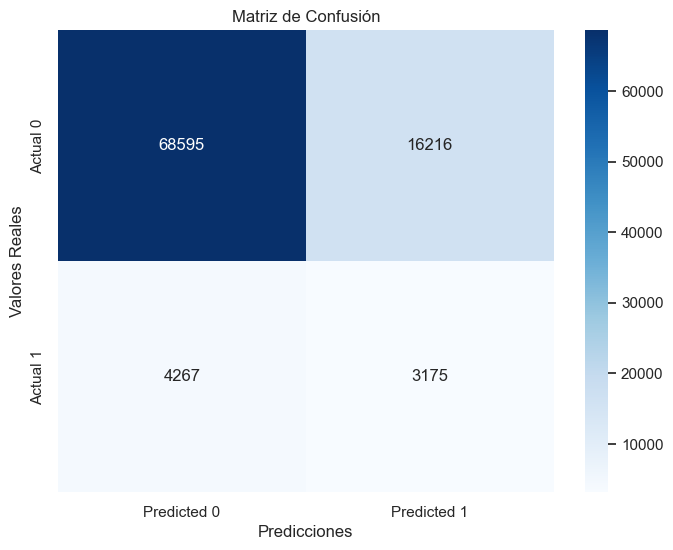

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, accuracy_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

borderline_smote = BorderlineSMOTE(kind='borderline-1', random_state=42) 
X_train_bsmote, y_train_bsmote = borderline_smote.fit_resample(X_train, y_train)

# Definir el modelo con los parámetros proporcionados
model = LogisticRegression(C=7.3299394181140505, penalty='l1', solver='liblinear', random_state=42)

# Entrenar el modelo con los datos de entrenamiento
model.fit(X_train_bsmote, y_train_bsmote)

# Predecir en el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Mostrar métricas
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)

# Graficar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted 0', 'Predicted 1'], 
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Matriz de Confusión")
plt.xlabel("Predicciones")
plt.ylabel("Valores Reales")
plt.show()

In [ ]:
#GridSearchCV

#### GridSearchCV

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

borderline_smote = BorderlineSMOTE(kind='borderline-1', random_state=42) 
X_train_bsmote, X_train_bsmote = borderline_smote.fit_resample(X_train, y_train)

# Define el modelo de Regresión Logística
log_reg = LogisticRegression(random_state=42)

# Hiperparámetros optimizados para un máximo de 20 iteraciones
grid_values = {
    'C': [0.1, 1],  # Regularización reducida a 2 valores
    'penalty': ['l1', 'l2'],  # Tipos de regularización
    'solver': ['liblinear' if p == 'l1' else 'saga' for p in ['l1', 'l2']],  # Un solver por penalización
    'max_iter': [200]  # Solo un valor para reducir combinaciones
}

# Grid Search con validación cruzada
grid_search = GridSearchCV(log_reg, param_grid=grid_values, 
                           cv=3, scoring='f1', n_jobs=-1)

grid_search.fit(X_train_bsmote, y_train_bsmote)

# Mejor combinación de hiperparámetros
final_params = grid_search.best_params_
print(f"Parámetros óptimos: {final_params}")

# Mejor modelo
best_log_reg = grid_search.best_estimator_

# Evaluación del mejor modelo
y_pred = best_log_reg.predict(X_test)

# Cálculo de métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Resultados finales
print(f"Resultados con los mejores hiperparámetros:")
print(f"  Accuracy: {accuracy:.2f}")
print(f"  Precision: {precision:.2f}")
print(f"  Recall: {recall:.2f}")
print(f"  F1-Score: {f1:.2f}")
print("  Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("  Classification Report:")
print(classification_report(y_test, y_pred))


ValueError: 
All the 24 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
8 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/juanmartin/anaconda3/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/juanmartin/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py", line 1196, in fit
    X, y = self._validate_data(
  File "/Users/juanmartin/anaconda3/lib/python3.10/site-packages/sklearn/base.py", line 565, in _validate_data
    X, y = check_X_y(X, y, **check_params)
  File "/Users/juanmartin/anaconda3/lib/python3.10/site-packages/sklearn/utils/validation.py", line 1106, in check_X_y
    X = check_array(
  File "/Users/juan

#### probamos con los mejores hipermarametros de gridsearch

Accuracy: 0.77
Precision: 0.15
Recall: 0.42
F1-Score: 0.23

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.80      0.86     84811
           1       0.15      0.42      0.23      7442

    accuracy                           0.77     92253
   macro avg       0.55      0.61      0.54     92253
weighted avg       0.88      0.77      0.81     92253



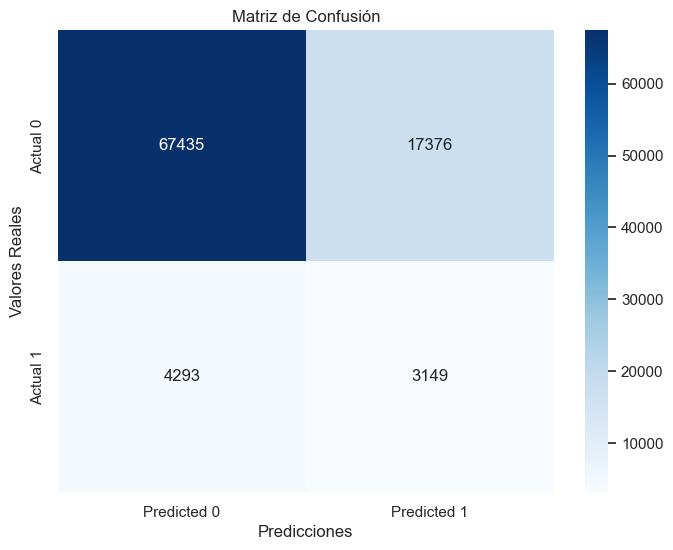

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, accuracy_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

borderline_smote = BorderlineSMOTE(kind='borderline-1', random_state=42) 
X_train_bsmote, X_train_bsmote = borderline_smote.fit_resample(X_train, y_train)


# Definir el modelo con los parámetros proporcionados
model = LogisticRegression(C=1, penalty='l2', solver='liblinear', random_state=42, max_iter=200)
# Entrenar el modelo con los datos de entrenamiento
model.fit(borderline_smote, X_train_bsmote)

# Predecir en el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Mostrar métricas
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)

# Graficar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted 0', 'Predicted 1'], 
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Matriz de Confusión")
plt.xlabel("Predicciones")
plt.ylabel("Valores Reales")
plt.show()